# STAT GR5243 Project 4
### Group 16 :
Baixuan Chen \
Daisy Zhou \
Zhonghao Liu \
Jisheng Zeng

## Data Cleaning and Handling Inconsistencies

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("ibm_jobs.csv")
df.head()

,job_title,job_id,date_posted,state_province,area_of_work,min_salary,max_salary,position_type,required_education,preferred_education,preferred_technical_experience
0,Software Developer Intern 2026: SVL,75759,30-Jan-2026,California,Software Engineering,"90,720.00","166,320.00",Internship,High School Diploma/GED,Bachelor's Degree,"Exposure to cloud platforms (IBM Cloud, AWS, o..."
1,SAP Technology Architect,72352,26-Nov-2025,"Illinois, Texas, Indiana, New Jersey",Software Engineering,"144,000.00","248,000.00",Professional,Bachelor's Degree,NaN,"SAP\nS/4HANA, SAP BTP (CAP, RAP, Event Mesh, I..."
2,"Senior Software Engineer, (Boundary) - HashiCorp",82844,03-Feb-2026,"Texas, Massachusetts, California",Software Engineering,"131,000.00","226,000.00",Professional,High School Diploma/GED,Bachelor's Degree,What's nice to have (preferred qualifications)...
3,DevOps Engineer - AWS,80597,19-Dec-2025,Texas,Infrastructure & Technology,"99,875.00","129,250.00",Professional,Bachelor's Degree,Master's Degree,NaN
4,Federal Senior Compliance Lead - CAS / FAR SME,86235,29-Jan-2026,"Minnesota, New York, Virginia, Maryland, Distr...",Enterprise Operations,"147,000.00","254,000.00",Professional,Bachelor's Degree,Master's Degree,Direct experience with the Defense Contract Au...


#### Convert salary from string to int

In [2]:
for col in ["min_salary", "max_salary"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )

#### Uniform formatting date posted

In [3]:
df["date_posted"] = pd.to_datetime(df["date_posted"], errors="coerce")

#### Uniform formatting education

In [4]:

edu_cols = ["required_education", "preferred_education"]
for c in edu_cols:
    df[c] = df[c].astype("string").str.strip().str.lower()

edu_map = {
    "high school diploma/ged": "high_school_ged",
    "associate's degree/college diploma": "associate",
    "bachelor's degree": "bachelor",
    "master's degree": "master",
    "doctorate degree": "doctorate",
    "technical diploma": "technical_diploma",
}

for c in edu_cols:
    df[c] = df[c].map(edu_map).fillna("unknown")

#### Drop duplicates

In [5]:
df = df.drop_duplicates().reset_index(drop=True)

#### create mean salary col

In [6]:
df["salary_mid"] = (df["min_salary"] + df["max_salary"]) / 2

#### Handle Missing Values

In [7]:
df.isna().sum()

,0
job_title,1
job_id,0
date_posted,0
state_province,0
area_of_work,5
min_salary,1
max_salary,1
position_type,0
required_education,0
preferred_education,0


In [8]:
df = df.dropna(subset=["min_salary", "max_salary", "job_title"])
df["preferred_technical_experience"] = (
    df["preferred_technical_experience"].fillna("")
)
df["area_of_work"] = (
    df["area_of_work"].fillna("unknown")
)

#### Cleaned Data Overview

In [9]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 469 entries, 0 to 470
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   job_title                       469 non-null    object        
 1   job_id                          469 non-null    int64         
 2   date_posted                     469 non-null    datetime64[ns]
 3   state_province                  469 non-null    object        
 4   area_of_work                    469 non-null    object        
 5   min_salary                      469 non-null    float64       
 6   max_salary                      469 non-null    float64       
 7   position_type                   469 non-null    object        
 8   required_education              469 non-null    object        
 9   preferred_education             469 non-null    object        
 10  preferred_technical_experience  469 non-null    object        
 11  salary_mid 

,job_title,job_id,date_posted,state_province,area_of_work,min_salary,max_salary,position_type,required_education,preferred_education,preferred_technical_experience,salary_mid
0,Software Developer Intern 2026: SVL,75759,2026-01-30,California,Software Engineering,90720.0,166320.0,Internship,high_school_ged,bachelor,"Exposure to cloud platforms (IBM Cloud, AWS, o...",128520.0
1,SAP Technology Architect,72352,2025-11-26,"Illinois, Texas, Indiana, New Jersey",Software Engineering,144000.0,248000.0,Professional,bachelor,unknown,"SAP\nS/4HANA, SAP BTP (CAP, RAP, Event Mesh, I...",196000.0
2,"Senior Software Engineer, (Boundary) - HashiCorp",82844,2026-02-03,"Texas, Massachusetts, California",Software Engineering,131000.0,226000.0,Professional,high_school_ged,bachelor,What's nice to have (preferred qualifications)...,178500.0
3,DevOps Engineer - AWS,80597,2025-12-19,Texas,Infrastructure & Technology,99875.0,129250.0,Professional,bachelor,master,,114562.5
4,Federal Senior Compliance Lead - CAS / FAR SME,86235,2026-01-29,"Minnesota, New York, Virginia, Maryland, Distr...",Enterprise Operations,147000.0,254000.0,Professional,bachelor,master,Direct experience with the Defense Contract Au...,200500.0


# EDA

# 1. Data Overview & Quality Checks

This section summarizes the structure and reliability of the scraped IBM job-posting dataset before deeper analysis. The raw dataset contains 478 rows × 11 columns. After basic normalization (string trimming), type conversions (posting date to datetime; salary strings to numeric), and derived features (midpoint salary and salary range), we create an analysis-ready table and remove duplicate postings based on job_id, resulting in 471 unique postings.

Data types and parsing quality are checked first: date_posted is fully parsed into date_posted_dt with 0 unparsed dates, and salary parsing yields only 1 missing value in min_salary_num and 1 in max_salary_num. We then assess missingness and find that missing values are concentrated in optional “preferred” fields (preferred_education and preferred_technical_experience), while core identifiers and posting date are complete. Finally, duplicate and validity checks indicate that only 7 exact duplicate rows (and 7 duplicate job_id values) exist; salary logic checks show 0 cases where min_salary_num exceeds max_salary_num, and there are no non-positive salary values.

All subsequent EDA sections primarily use the de-duplicated dataset (df_eda) to avoid double-counting postings.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# -----------------------------
# Read raw data
# -----------------------------

print("Current working directory check passed.")

df_raw = pd.read_csv("ibm_jobs.csv")

print("df_raw shape:", df_raw.shape)
df_raw.head()


Current working directory check passed.
df_raw shape: (478, 11)


,job_title,job_id,date_posted,state_province,area_of_work,min_salary,max_salary,position_type,required_education,preferred_education,preferred_technical_experience
0,Software Developer Intern 2026: SVL,75759,30-Jan-2026,California,Software Engineering,"90,720.00","166,320.00",Internship,High School Diploma/GED,Bachelor's Degree,"Exposure to cloud platforms (IBM Cloud, AWS, o..."
1,SAP Technology Architect,72352,26-Nov-2025,"Illinois, Texas, Indiana, New Jersey",Software Engineering,"144,000.00","248,000.00",Professional,Bachelor's Degree,NaN,"SAP\nS/4HANA, SAP BTP (CAP, RAP, Event Mesh, I..."
2,"Senior Software Engineer, (Boundary) - HashiCorp",82844,03-Feb-2026,"Texas, Massachusetts, California",Software Engineering,"131,000.00","226,000.00",Professional,High School Diploma/GED,Bachelor's Degree,What's nice to have (preferred qualifications)...
3,DevOps Engineer - AWS,80597,19-Dec-2025,Texas,Infrastructure & Technology,"99,875.00","129,250.00",Professional,Bachelor's Degree,Master's Degree,NaN
4,Federal Senior Compliance Lead - CAS / FAR SME,86235,29-Jan-2026,"Minnesota, New York, Virginia, Maryland, Distr...",Enterprise Operations,"147,000.00","254,000.00",Professional,Bachelor's Degree,Master's Degree,Direct experience with the Defense Contract Au...


## 1.1 Field Inspection and Minimal Type Conversions

Several fields require minimal but essential preprocessing to support reliable summaries and visualizations. The posting date field date_posted follows the format like 30-Jan-2026 and is converted into date_posted_dt; parsing is fully successful with 0 NaT, which enables trend analyses over time. The salary fields min_salary and max_salary are stored as strings with commas (for example, 90,720.00), so they are converted into numeric columns min_salary_num and max_salary_num; only one record fails parsing for each salary column.

We also construct derived salary features mid_salary = (min + max) / 2 and salary_range = max − min, which will be used for distribution plots and group comparisons. Finally, we apply basic text normalization by stripping whitespace from all string-like columns to improve the reliability of category counting. This preprocessing is intentionally lightweight: it preserves the original information while making the dataset analysis-ready.


In [11]:
df = df_raw.copy()

#  Strip whitespace for all object columns (basic text normalization)
obj_cols = df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c] = df[c].astype("string").str.strip()

# Parse date_posted
# Example format observed: "30-Jan-2026"
df["date_posted_dt"] = pd.to_datetime(df["date_posted"], format="%d-%b-%Y", errors="coerce")

# Convert salary columns to numeric
# Remove anything that's not digit/./-
def to_numeric_money(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True)  # remove commas/$/spaces etc.
    s = s.replace("", pd.NA)
    return pd.to_numeric(s, errors="coerce")

df["min_salary_num"] = to_numeric_money(df["min_salary"])
df["max_salary_num"] = to_numeric_money(df["max_salary"])

df["mid_salary"] = (df["min_salary_num"] + df["max_salary_num"]) / 2
df["salary_range"] = df["max_salary_num"] - df["min_salary_num"]

# check
df[["date_posted", "date_posted_dt", "min_salary", "min_salary_num", "max_salary", "max_salary_num"]].head()

,date_posted,date_posted_dt,min_salary,min_salary_num,max_salary,max_salary_num
0,30-Jan-2026,2026-01-30,"90,720.00",90720.0,"166,320.00",166320.0
1,26-Nov-2025,2025-11-26,"144,000.00",144000.0,"248,000.00",248000.0
2,03-Feb-2026,2026-02-03,"131,000.00",131000.0,"226,000.00",226000.0
3,19-Dec-2025,2025-12-19,"99,875.00",99875.0,"129,250.00",129250.0
4,29-Jan-2026,2026-01-29,"147,000.00",147000.0,"254,000.00",254000.0


In [12]:
print("Basic info")
display(df.head(3))

print("\nDtypes (raw vs converted)")
dtypes_table = pd.DataFrame({
    "raw_dtype": df_raw.dtypes.astype(str),
    "cleaned_dtype": df.dtypes.astype(str)
})
display(dtypes_table)

print("\nMissingness (raw columns)")
missing_counts = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df_raw) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
display(missing_table)

print("\nMissingness (key converted columns)")
conv_missing = df[["date_posted_dt", "min_salary_num", "max_salary_num"]].isna().sum()
display(conv_missing.to_frame("missing_count"))


Basic info


,job_title,job_id,date_posted,state_province,area_of_work,min_salary,max_salary,position_type,required_education,preferred_education,preferred_technical_experience,date_posted_dt,min_salary_num,max_salary_num,mid_salary,salary_range
0,Software Developer Intern 2026: SVL,75759,30-Jan-2026,California,Software Engineering,"90,720.00","166,320.00",Internship,High School Diploma/GED,Bachelor's Degree,"Exposure to cloud platforms (IBM Cloud, AWS, o...",2026-01-30,90720.0,166320.0,128520.0,75600.0
1,SAP Technology Architect,72352,26-Nov-2025,"Illinois, Texas, Indiana, New Jersey",Software Engineering,"144,000.00","248,000.00",Professional,Bachelor's Degree,<NA>,"SAP S/4HANA, SAP BTP (CAP, RAP, Event Mesh, In...",2025-11-26,144000.0,248000.0,196000.0,104000.0
2,"Senior Software Engineer, (Boundary) - HashiCorp",82844,03-Feb-2026,"Texas, Massachusetts, California",Software Engineering,"131,000.00","226,000.00",Professional,High School Diploma/GED,Bachelor's Degree,What's nice to have (preferred qualifications)...,2026-02-03,131000.0,226000.0,178500.0,95000.0



Dtypes (raw vs converted)


,raw_dtype,cleaned_dtype
area_of_work,object,string
date_posted,object,string
date_posted_dt,NaN,datetime64[ns]
job_id,int64,int64
job_title,object,string
max_salary,object,string
max_salary_num,NaN,Float64
mid_salary,NaN,Float64
min_salary,object,string
min_salary_num,NaN,Float64



Missingness (raw columns)


,missing_count,missing_pct
preferred_education,123,25.73
preferred_technical_experience,92,19.25
required_education,12,2.51
area_of_work,5,1.05
min_salary,1,0.21
job_title,1,0.21
max_salary,1,0.21
date_posted,0,0.00
job_id,0,0.00
state_province,0,0.00



Missingness (key converted columns)


,missing_count
date_posted_dt,0
min_salary_num,1
max_salary_num,1


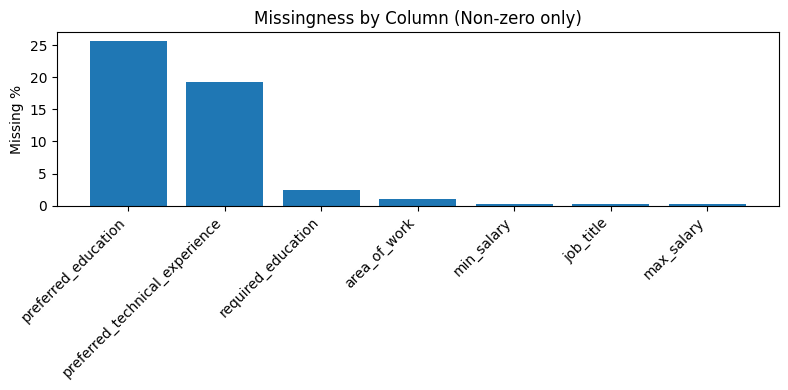

,0
preferred_education,25.732218
preferred_technical_experience,19.246862
required_education,2.510460
area_of_work,1.046025
min_salary,0.209205
job_title,0.209205
max_salary,0.209205


In [13]:
# Missingness bar plot (top columns with missing)
miss = (df_raw.isna().mean() * 100).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]

plt.figure(figsize=(8, 4))
plt.bar(miss_nonzero.index, miss_nonzero.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing %")
plt.title("Missingness by Column (Non-zero only)")
plt.tight_layout()
plt.show()

miss_nonzero


In [14]:
n_rows = len(df_raw)

dup_rows = df_raw.duplicated().sum()
dup_jobid = df_raw["job_id"].duplicated().sum()
n_unique_jobid = df_raw["job_id"].nunique()

print("Duplicate checks")
print(f"Total rows: {n_rows}")
print(f"Duplicated rows (exact duplicates): {dup_rows}")
print(f"Duplicated job_id count: {dup_jobid}")
print(f"Unique job_id: {n_unique_jobid}")

# Show duplicated job_id examples
dup_examples = df_raw[df_raw["job_id"].duplicated(keep=False)].sort_values("job_id")
display(dup_examples[["job_id", "job_title", "date_posted", "state_province"]].head(20))


Duplicate checks
Total rows: 478
Duplicated rows (exact duplicates): 7
Duplicated job_id count: 7
Unique job_id: 471


,job_id,job_title,date_posted,state_province
364,56278,Entry Level Product Manager 2026,13-Nov-2025,"Georgia, Minnesota, Texas, New York, North Car..."
367,56278,Entry Level Product Manager 2026,13-Nov-2025,"Georgia, Minnesota, Texas, New York, North Car..."
368,72727,Network and Computer Systems Administrator App...,04-Dec-2025,New York
365,72727,Network and Computer Systems Administrator App...,04-Dec-2025,New York
369,75078,Cloud Developer Intern,06-Jan-2026,"Illinois, Texas, North Carolina, California"
366,75078,Cloud Developer Intern,06-Jan-2026,"Illinois, Texas, North Carolina, California"
162,75693,Technical Lead TS/SCI W/FSP,09-Dec-2025,"Virginia, Maryland, District of Columbia"
141,75693,Technical Lead TS/SCI W/FSP,09-Dec-2025,"Virginia, Maryland, District of Columbia"
292,87213,Associate Package Consultant Intern 2026 – SAP...,30-Jan-2026,"Georgia, Illinois, Texas, Virginia, Arizona"
313,87213,Associate Package Consultant Intern 2026 – SAP...,30-Jan-2026,"Georgia, Illinois, Texas, Virginia, Arizona"


In [15]:
print("Validity checks")

# date parsing success
n_bad_date = df["date_posted_dt"].isna().sum()
date_min = df["date_posted_dt"].min()
date_max = df["date_posted_dt"].max()
print(f"Unparsed dates (NaT): {n_bad_date}")
print(f"Date range: {date_min.date()} to {date_max.date()}")

# salary numeric success
n_bad_min = df["min_salary_num"].isna().sum()
n_bad_max = df["max_salary_num"].isna().sum()
print(f"Unparsed min_salary_num: {n_bad_min}")
print(f"Unparsed max_salary_num: {n_bad_max}")

# logical constraints
min_gt_max = (df["min_salary_num"] > df["max_salary_num"]).sum()
min_le_0 = (df["min_salary_num"] <= 0).sum()
max_le_0 = (df["max_salary_num"] <= 0).sum()
print(f"Rows with min_salary_num > max_salary_num: {min_gt_max}")
print(f"Rows with min_salary_num <= 0: {min_le_0}")
print(f"Rows with max_salary_num <= 0: {max_le_0}")

# salary summary (robust quantiles)
salary_desc = df[["min_salary_num", "max_salary_num", "mid_salary", "salary_range"]].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(salary_desc)


Validity checks
Unparsed dates (NaT): 0
Date range: 2025-08-14 to 2026-02-04
Unparsed min_salary_num: 1
Unparsed max_salary_num: 1
Rows with min_salary_num > max_salary_num: 0
Rows with min_salary_num <= 0: 0
Rows with max_salary_num <= 0: 0


,count,mean,std,min,1%,5%,50%,95%,99%,max
min_salary_num,477.0,105427.475891,37356.620459,29120.0,36040.0,49200.0,99875.0,161000.0,206870.4,275000.0
max_salary_num,477.0,176848.549266,60766.984719,38000.0,54120.0,79440.0,172000.0,270400.0,318680.0,410000.0
mid_salary,477.0,141138.012579,48240.133708,35500.0,49940.0,63672.0,134000.0,218500.0,256500.0,342500.0
salary_range,477.0,71421.073375,29459.209882,0.0,4920.0,26480.0,69900.0,115000.0,133480.0,216000.0


In [16]:
# Keep raw cleaned df as df_clean
df_clean = df.copy()

# Create analysis dataset: drop duplicates by job_id
before = len(df_clean)
df_eda = df_clean.drop_duplicates(subset=["job_id"], keep="first").reset_index(drop=True)
after = len(df_eda)

print("Build df_eda:")
print(f"Rows before de-dup by job_id: {before}")
print(f"Rows after  de-dup by job_id: {after}")
print(f"Removed rows: {before - after}")

df_eda.head()


Build df_eda:
Rows before de-dup by job_id: 478
Rows after  de-dup by job_id: 471
Removed rows: 7


,job_title,job_id,date_posted,state_province,area_of_work,min_salary,max_salary,position_type,required_education,preferred_education,preferred_technical_experience,date_posted_dt,min_salary_num,max_salary_num,mid_salary,salary_range
0,Software Developer Intern 2026: SVL,75759,30-Jan-2026,California,Software Engineering,"90,720.00","166,320.00",Internship,High School Diploma/GED,Bachelor's Degree,"Exposure to cloud platforms (IBM Cloud, AWS, o...",2026-01-30,90720.0,166320.0,128520.0,75600.0
1,SAP Technology Architect,72352,26-Nov-2025,"Illinois, Texas, Indiana, New Jersey",Software Engineering,"144,000.00","248,000.00",Professional,Bachelor's Degree,<NA>,"SAP S/4HANA, SAP BTP (CAP, RAP, Event Mesh, In...",2025-11-26,144000.0,248000.0,196000.0,104000.0
2,"Senior Software Engineer, (Boundary) - HashiCorp",82844,03-Feb-2026,"Texas, Massachusetts, California",Software Engineering,"131,000.00","226,000.00",Professional,High School Diploma/GED,Bachelor's Degree,What's nice to have (preferred qualifications)...,2026-02-03,131000.0,226000.0,178500.0,95000.0
3,DevOps Engineer - AWS,80597,19-Dec-2025,Texas,Infrastructure & Technology,"99,875.00","129,250.00",Professional,Bachelor's Degree,Master's Degree,<NA>,2025-12-19,99875.0,129250.0,114562.5,29375.0
4,Federal Senior Compliance Lead - CAS / FAR SME,86235,29-Jan-2026,"Minnesota, New York, Virginia, Maryland, Distr...",Enterprise Operations,"147,000.00","254,000.00",Professional,Bachelor's Degree,Master's Degree,Direct experience with the Defense Contract Au...,2026-01-29,147000.0,254000.0,200500.0,107000.0


## 1.2 Key Findings from Data Quality Checks

After cleaning and de-duplication, the analysis dataset contains 471 unique job postings (from 478 rows; 7 duplicates removed).

Missingness is concentrated in a small number of columns. preferred_education is missing in 123 out of 478 rows (25.73%), and preferred_technical_experience is missing in 92 out of 478 rows (19.25%). required_education has 12 missing values (2.51%), while other fields are at or below roughly 1% missing; job_id and date_posted are complete with 0% missing. In terms of time coverage, postings span 2025-08-14 to 2026-02-04, and the date parser produces 0 unparsed dates.

Salary validity checks reveal no logical inconsistencies: there are 0 cases where min_salary_num exceeds max_salary_num, and there are no non-positive salaries. On the de-duplicated data, min_salary_num has a minimum of 29,120 and a mean around 105,427; max_salary_num reaches up to 410,000; mid_salary has a median around 134,000 and a mean around 141,138. Finally, the location field state_province often contains multiple states in one posting; about 62.34% of records include comma-separated multi-state strings, so state-level summaries require careful handling.


In [17]:
# Prepare summary numbers from df_raw / df_eda
n, p = df_raw.shape
miss_tbl = (df_raw.isna().sum().to_frame("missing_count"))
miss_tbl["missing_pct"] = (miss_tbl["missing_count"] / n * 100).round(2)
top_miss = miss_tbl.sort_values("missing_pct", ascending=False).head(5)

multi_state_pct = (df_raw["state_province"].astype(str).str.contains(",").mean() * 100)

salary_min = df_eda["min_salary_num"].min()
salary_max = df_eda["max_salary_num"].max()
mid_med = df_eda["mid_salary"].median()

summary_md = f"""
- Dataset size: {n} rows × {p} columns
- Duplicates: {df_raw["job_id"].nunique()} unique `job_id` values; {df_raw["job_id"].duplicated().sum()} duplicated `job_id` records detected
- Missing values (Top):
{top_miss.to_string()}

Date range: {df_eda["date_posted_dt"].min().date()} to {df_eda["date_posted_dt"].max().date()} (number of unparseable dates: {df_eda["date_posted_dt"].isna().sum()})
Salary range (after deduplication): minimum of `min_salary_num` = {salary_min:,.0f}, maximum of `max_salary_num` = {salary_max:,.0f}; median of `mid_salary` = {mid_med:,.0f}
Proportion of multi-state information in `state_province`: approximately {multi_state_pct:.2f}%
""".strip()


print(summary_md)


- Dataset size: 478 rows × 11 columns
- Duplicates: 471 unique `job_id` values; 7 duplicated `job_id` records detected
- Missing values (Top):
                                missing_count  missing_pct
preferred_education                       123        25.73
preferred_technical_experience             92        19.25
required_education                         12         2.51
area_of_work                                5         1.05
min_salary                                  1         0.21

Date range: 2025-08-14 to 2026-02-04 (number of unparseable dates: 0)
Salary range (after deduplication): minimum of `min_salary_num` = 29,120, maximum of `max_salary_num` = 410,000; median of `mid_salary` = 134,000
Proportion of multi-state information in `state_province`: approximately 62.34%


# 2. Univariate Analysis

This section examines one variable at a time to understand marginal distributions and identify dominant categories or long-tail patterns. All results are based on the de-duplicated dataset (471 postings) to avoid double-counting.

We focus on categorical distributions (counts and shares) for position_type, area_of_work, and education-related fields; we also summarize state_province while keeping in mind that many entries contain multiple states. For salary distributions, we use numeric salary features (min_salary_num, max_salary_num, mid_salary, salary_range) and visually inspect skewness and potential outliers. These univariate results help determine which dimensions are most informative for later bivariate analyses.

In [18]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# use df_eda to do EDA remained
df2 = df_eda.copy()

print("df2 shape:", df2.shape)
df2.head()


df2 shape: (471, 16)


,job_title,job_id,date_posted,state_province,area_of_work,min_salary,max_salary,position_type,required_education,preferred_education,preferred_technical_experience,date_posted_dt,min_salary_num,max_salary_num,mid_salary,salary_range
0,Software Developer Intern 2026: SVL,75759,30-Jan-2026,California,Software Engineering,"90,720.00","166,320.00",Internship,High School Diploma/GED,Bachelor's Degree,"Exposure to cloud platforms (IBM Cloud, AWS, o...",2026-01-30,90720.0,166320.0,128520.0,75600.0
1,SAP Technology Architect,72352,26-Nov-2025,"Illinois, Texas, Indiana, New Jersey",Software Engineering,"144,000.00","248,000.00",Professional,Bachelor's Degree,<NA>,"SAP S/4HANA, SAP BTP (CAP, RAP, Event Mesh, In...",2025-11-26,144000.0,248000.0,196000.0,104000.0
2,"Senior Software Engineer, (Boundary) - HashiCorp",82844,03-Feb-2026,"Texas, Massachusetts, California",Software Engineering,"131,000.00","226,000.00",Professional,High School Diploma/GED,Bachelor's Degree,What's nice to have (preferred qualifications)...,2026-02-03,131000.0,226000.0,178500.0,95000.0
3,DevOps Engineer - AWS,80597,19-Dec-2025,Texas,Infrastructure & Technology,"99,875.00","129,250.00",Professional,Bachelor's Degree,Master's Degree,<NA>,2025-12-19,99875.0,129250.0,114562.5,29375.0
4,Federal Senior Compliance Lead - CAS / FAR SME,86235,29-Jan-2026,"Minnesota, New York, Virginia, Maryland, Distr...",Enterprise Operations,"147,000.00","254,000.00",Professional,Bachelor's Degree,Master's Degree,Direct experience with the Defense Contract Au...,2026-01-29,147000.0,254000.0,200500.0,107000.0


## 2.1 Helper Function: Top-N Category Plots (Counts + Percentages)

To streamline categorical EDA, we define a reusable plotting function that computes value counts and percent shares for a given categorical column. When the category space is long-tailed, the function can optionally aggregate low-frequency categories into “Other” to keep plots readable. It returns a summary table alongside a bar chart, and we apply it consistently across position_type, area_of_work, and education-related fields to ensure comparable summaries.


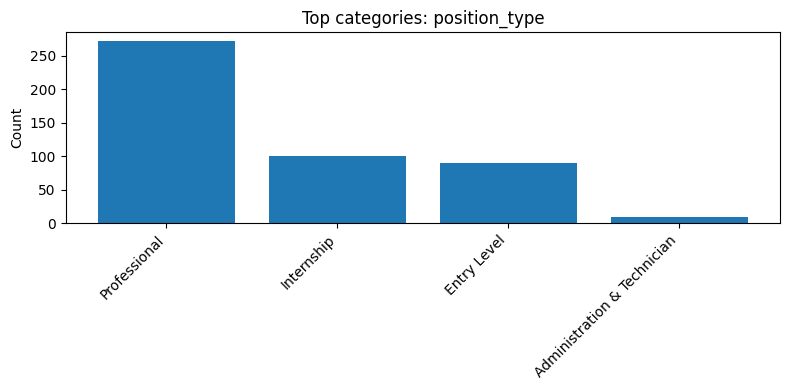

,count,pct(%)
position_type,,
Professional,271,57.54
Internship,100,21.23
Entry Level,90,19.11
Administration & Technician,10,2.12


In [19]:
def plot_top_categories(df, col, top_n=10, other=True, figsize=(8,4)):
    s = df[col].dropna().astype(str).str.strip()
    vc = s.value_counts(dropna=True)

    if other and len(vc) > top_n:
        top = vc.iloc[:top_n]
        other_sum = vc.iloc[top_n:].sum()
        vc_plot = pd.concat([top, pd.Series({"Other": other_sum})])
    else:
        vc_plot = vc.iloc[:top_n]

    pct = (vc_plot / vc_plot.sum() * 100).round(2)
    out = pd.DataFrame({"count": vc_plot, "pct(%)": pct})

    # plot
    plt.figure(figsize=figsize)
    plt.bar(out.index, out["count"].values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(f"Top categories: {col}")
    plt.tight_layout()
    plt.show()

    return out

# quick test
plot_top_categories(df2, "position_type", top_n=10, other=False)


## 2.2 Categorical Distributions

For position_type, the dataset is dominated by professional roles. Professional accounts for 271 postings (57.54%), while Internship and Entry Level represent substantial shares with 100 (21.23%) and 90 (19.11%) postings, respectively; Administration & Technician is rare (10; 2.12%). This composition suggests the scraped postings primarily reflect professional hiring while still capturing a meaningful fraction of internship and entry-level openings.

For area_of_work, the largest functional groups are Consulting (116; 24.89%), Software Engineering (102; 21.9%), and Infrastructure & Technology (100; 21.5%), followed by Sales (41; 8.9%) and smaller long-tail categories. Overall, the dataset shows strong representation of technology- and consulting-related roles.

For education requirements, required_education is concentrated in two categories: Bachelor's Degree (222; 48.26%) and High School Diploma/GED (218; 47.39%), while advanced degrees appear infrequently (for example, Master's Degree 8; 1.74%). For preferred_education (when provided), Bachelor's Degree (240; 68.97%) and Master's Degree (72; 20.69%) dominate, consistent with the earlier observation that preferred fields have higher missingness and are not always specified.


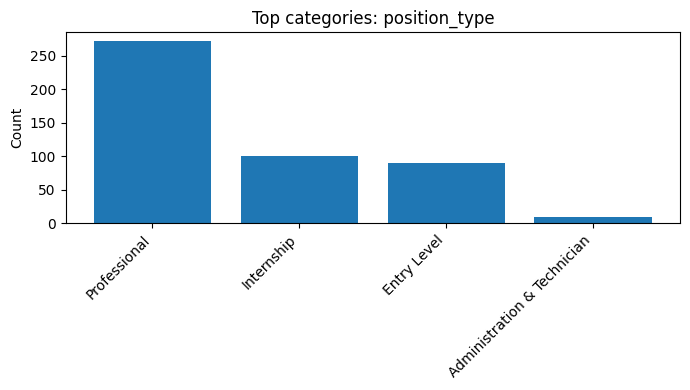

,count,pct(%)
position_type,,
Professional,271,57.54
Internship,100,21.23
Entry Level,90,19.11
Administration & Technician,10,2.12


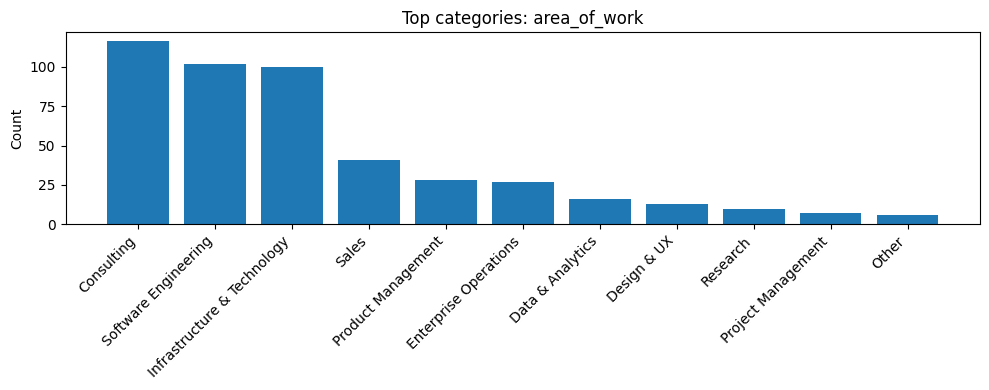

,count,pct(%)
Consulting,116,24.89
Software Engineering,102,21.89
Infrastructure & Technology,100,21.46
Sales,41,8.80
Product Management,28,6.01
Enterprise Operations,27,5.79
Data & Analytics,16,3.43
Design & UX,13,2.79
Research,10,2.15
Project Management,7,1.50


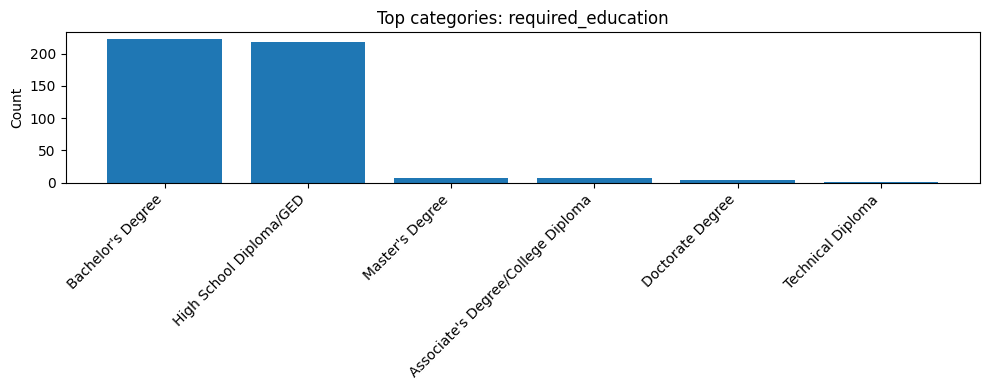

,count,pct(%)
required_education,,
Bachelor's Degree,222,48.26
High School Diploma/GED,218,47.39
Master's Degree,8,1.74
Associate's Degree/College Diploma,7,1.52
Doctorate Degree,4,0.87
Technical Diploma,1,0.22


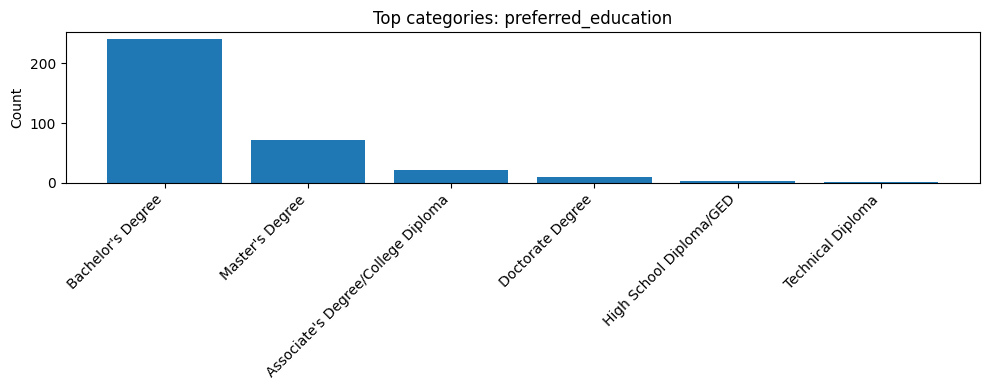

,count,pct(%)
preferred_education,,
Bachelor's Degree,240,68.97
Master's Degree,72,20.69
Associate's Degree/College Diploma,21,6.03
Doctorate Degree,10,2.87
High School Diploma/GED,3,0.86
Technical Diploma,2,0.57


In [20]:
tab_position = plot_top_categories(df2, "position_type", top_n=10, other=True, figsize=(7,4))
display(tab_position)

tab_area = plot_top_categories(df2, "area_of_work", top_n=10, other=True, figsize=(10,4))
display(tab_area)

tab_reqedu = plot_top_categories(df2, "required_education", top_n=10, other=False, figsize=(10,4))
display(tab_reqedu)

tab_prefedu = plot_top_categories(df2, "preferred_education", top_n=10, other=True, figsize=(10,4))
display(tab_prefedu)


## 2.3 Location Field: state_province

The state_province field is not a clean single-state variable. A large share of postings include comma-separated multi-state strings (62.34%), meaning one posting may list multiple potential locations or recruiting regions. When we treat the raw string as a category, it helps summarize common location patterns but can produce long labels, especially for multi-state combinations; it also means that posting-level counts reflect “location strings” rather than individual states.

In the posting-level summary (with truncated labels for readability), New York appears most frequently (61 postings), and multi-state combinations such as Texas, Massachusetts, California (34) also occur often. Any true state distribution should therefore split and explode multi-state entries in a dedicated state-level analysis.

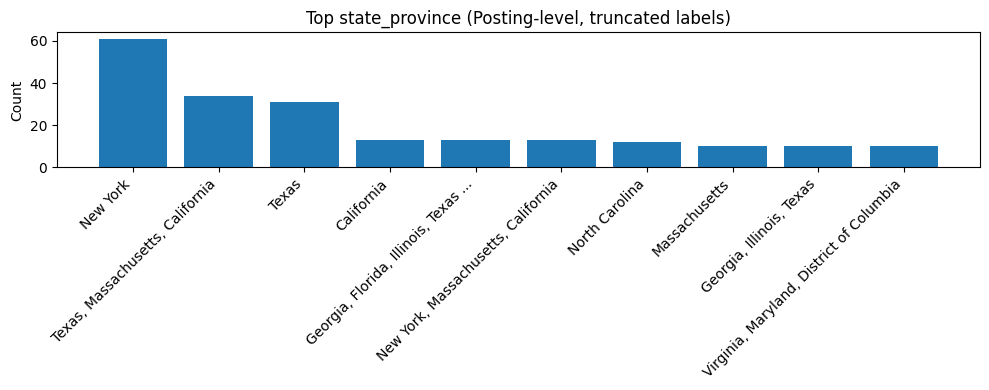

,count
New York,61
"Texas, Massachusetts, California",34
Texas,31
California,13
"Georgia, Florida, Illinois, Texas ...",13
"New York, Massachusetts, California",13
North Carolina,12
Massachusetts,10
"Georgia, Illinois, Texas",10
"Virginia, Maryland, District of Columbia",10


In [21]:
# Posting-level (raw field)

def truncate_states(label, max_states=4):
    parts = [x.strip() for x in str(label).split(",")]
    if len(parts) > max_states:
        return ", ".join(parts[:max_states]) + " ..."
    else:
        return ", ".join(parts)

# original frequency
state_raw_series = df2["state_province"].dropna().astype(str).str.strip()
vc_raw = state_raw_series.value_counts()

# Top N
top_n = 10
vc_plot = vc_raw.iloc[:top_n]

# truncate long label
vc_plot.index = [truncate_states(x, max_states=4) for x in vc_plot.index]

plt.figure(figsize=(10,4))
plt.bar(vc_plot.index, vc_plot.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Top state_province (Posting-level, truncated labels)")
plt.tight_layout()
plt.show()

display(vc_plot.to_frame("count"))


## 2.4 Salary Variables: Distributions

We analyze numeric salary features derived from the scraped salary strings, including min_salary_num and max_salary_num as endpoints, mid_salary as the midpoint, and salary_range as the spread. Key descriptive statistics on the de-duplicated postings with valid salaries indicate that min_salary_num ranges from 29,120 to 275,000 (mean = 105,658), while max_salary_num reaches up to 410,000, suggesting a right tail of high-paying postings. mid_salary has a mean aounrd 141,482, consistent with a right-skewed distribution, and salary_range can be 0 for some postings (fixed endpoints) while extending to large spreads (up to 216,000), indicating heterogeneous pay ranges across roles.

We visualize these distributions using histograms and boxplots; when a log transform is used, it helps interpret skewness and reduces the influence of extreme values.

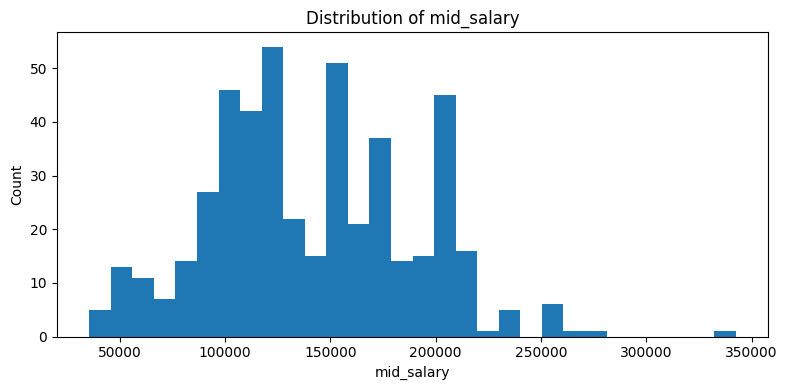

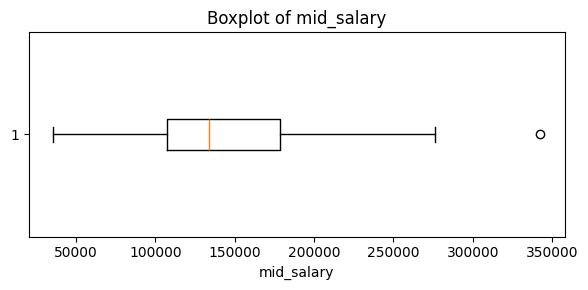

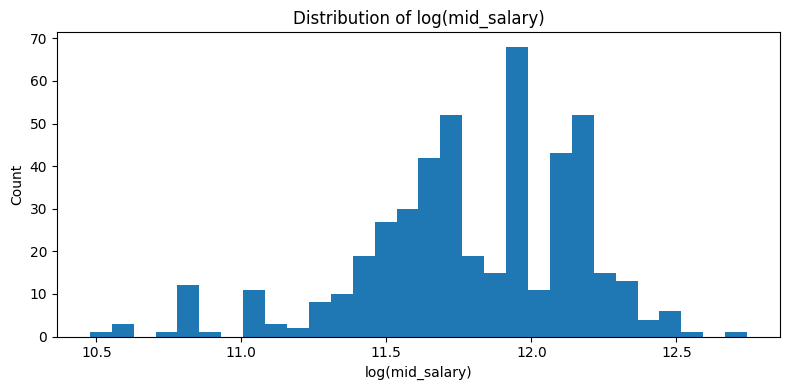

,count,mean,std,min,1%,5%,50%,95%,99%,max
min_salary_num,470.0,105658.310638,37358.188019,29120.0,35760.0,49200.0,100400.0,161000.0,207987.6,275000.0
max_salary_num,470.0,177305.229787,60605.53299,38000.0,54120.0,79728.0,172000.0,271100.0,319170.0,410000.0
mid_salary,470.0,141481.770213,48151.807308,35500.0,49485.0,64071.75,134000.0,218500.0,256500.0,342500.0
salary_range,470.0,71646.919149,29375.899884,0.0,4920.0,26714.0,69950.0,115000.0,133620.0,216000.0


In [22]:
salary_df = df2.dropna(subset=["mid_salary"]).copy()

# 1) Histogram of mid_salary
plt.figure(figsize=(8,4))
plt.hist(salary_df["mid_salary"], bins=30)
plt.xlabel("mid_salary")
plt.ylabel("Count")
plt.title("Distribution of mid_salary")
plt.tight_layout()
plt.show()

# 2) Boxplot of mid_salary
plt.figure(figsize=(6,3))
plt.boxplot(salary_df["mid_salary"], vert=False)
plt.xlabel("mid_salary")
plt.title("Boxplot of mid_salary")
plt.tight_layout()
plt.show()

# 3) Log histogram (add 1 to be safe, though salary should be >0)
salary_df["log_mid_salary"] = np.log(salary_df["mid_salary"])

plt.figure(figsize=(8,4))
plt.hist(salary_df["log_mid_salary"], bins=30)
plt.xlabel("log(mid_salary)")
plt.ylabel("Count")
plt.title("Distribution of log(mid_salary)")
plt.tight_layout()
plt.show()

salary_df[["min_salary_num","max_salary_num","mid_salary","salary_range"]].describe(percentiles=[.01,.05,.5,.95,.99]).T


## 2.5 Conclusion

After removing duplicate job_id entries, the dataset contains 471 unique postings; the posting date parses cleanly, and only a very small number of salary strings fail numeric parsing. Missingness is concentrated in “nice-to-have” fields: preferred_education is missing for about a quarter of postings and preferred_technical_experience for about a fifth, while required_education and the core structural fields have low missingness, so downstream analysis is more reliable when anchored on “required” fields and uses “preferred” fields as supplementary context.

The location field state_province frequently lists multiple states (roughly over 60%), so frequency counts on the raw string represent “location strings” rather than single-state distributions, and the reporting unit should be stated explicitly.

The salary distribution is right-skewed with a small number of high-salary roles, making median and quantiles more robust than the mean; a log transform can be helpful for visualization and modeling.


# 3. Bivariate & Multivariate Analysis

This section focuses on salary differences across key job attributes, comparing compensation across area_of_work, position_type, and education requirements. Because salary is right-skewed with potential extremes, the analysis emphasizes medians and quantiles, and uses nonparametric tests (Kruskal–Wallis) for robust group comparisons; for relationships between categorical variables, chi-square tests and Cramér’s V are used to summarize statistical significance and association strength.


In [23]:
# Base dataset for relationship analysis
df3 = df2.copy()

# Keep rows with salary available
df3_salary = df3.dropna(subset=["mid_salary"]).copy()

# Optional: log salary for robustness
df3_salary["log_mid_salary"] = np.log(df3_salary["mid_salary"])

print("df3_salary shape:", df3_salary.shape)
df3_salary[["mid_salary", "log_mid_salary"]].describe()


df3_salary shape: (470, 17)


,mid_salary,log_mid_salary
count,470.0,470.0
mean,141481.770213,11.795587
std,48151.807308,0.374807
min,35500.0,10.477288
25%,107100.0,11.581518
50%,134000.0,11.805595
75%,178500.0,12.092344
max,342500.0,12.744027


## 3.1 Salary Differences Across area_of_work

Salary differs meaningfully across business areas. Using medians as a robust summary, Consulting and Software Engineering sit at the high end (roughly 157k and 154k), Sales / Design & UX / Product Management fall in the middle, while Infrastructure & Technology shows a lower median among the major groups. The Kruskal–Wallis test is statistically significant (H≈67.25, p≈5.30e-12), indicating that the observed cross-area salary differences are unlikely to be due to random variation; follow-up stratification by position type and geography can help interpret why.


,n,median,mean
area_of_work,,,
Consulting,116,158000.0,157335.258621
Software Engineering,102,151000.0,153866.828431
Sales,41,134000.0,153295.853659
Design & UX,13,126000.0,141689.846154
Product Management,28,123000.0,139805.535714
Data & Analytics,16,118114.5,131634.6875
Enterprise Operations,27,111071.5,125265.518519
Infrastructure & Technology,100,107050.0,109930.085


/tmp/ipykernel_6489/381480464.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=area_summary.index, showfliers=False)


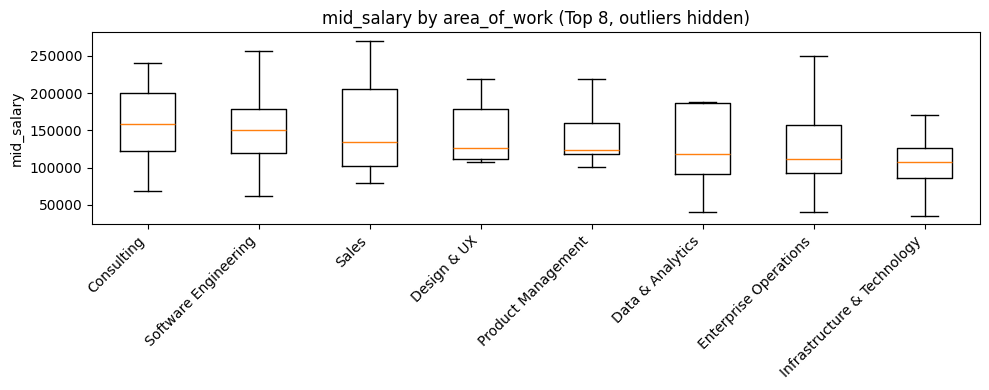

In [24]:
top_n = 8

top_areas = df3_salary["area_of_work"].value_counts().head(top_n).index.tolist()
df_area = df3_salary[df3_salary["area_of_work"].isin(top_areas)].copy()

# Summary table
area_summary = (
    df_area.groupby("area_of_work")["mid_salary"]
    .agg(n="count", median="median", mean="mean")
    .sort_values("median", ascending=False)
)
display(area_summary)

# Boxplot
plt.figure(figsize=(10, 4))
data_to_plot = [df_area.loc[df_area["area_of_work"] == a, "mid_salary"].values for a in area_summary.index]
plt.boxplot(data_to_plot, labels=area_summary.index, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("mid_salary")
plt.title(f"mid_salary by area_of_work (Top {top_n}, outliers hidden)")
plt.tight_layout()
plt.show()


In [25]:
from scipy.stats import kruskal

groups = [df_area.loc[df_area["area_of_work"] == a, "mid_salary"].dropna().values for a in area_summary.index]
kw_stat, kw_p = kruskal(*groups)

print("Kruskal-Wallis test: mid_salary by area_of_work")
print(f"H statistic = {kw_stat:.4f}")
print(f"p-value     = {kw_p:.6g}")

if kw_p < 0.001:
    print("Conclusion: There is a highly significant difference in salary distributions across different areas of work (p < 0.001).")
elif kw_p < 0.05:
    print("Conclusion: There is a significant difference in salary distributions across different areas of work (p < 0.05).")
else:
    print("Conclusion: No significant difference was observed (p ≥ 0.05).")


Kruskal-Wallis test: mid_salary by area_of_work
H statistic = 67.2498
p-value     = 5.30244e-12
Conclusion: There is a highly significant difference in salary distributions across different areas of work (p < 0.001).


## 3.2 Salary Differences Across position_type

Salary differences by position_type are very pronounced. Professional roles have the highest median (about 173.5k), while Entry Level and Internship roles are substantially lower (about 113.5k and 104.5k), and Administration & Technician has a small sample but a notably lower median (about 56k). The Kruskal–Wallis result is extremely significant (H≈295.37, p≈9.99e-64), suggesting that position type/level is one of the most important drivers of compensation differences in this dataset.


,n,median,mean
position_type,,,
Professional,270,173500.0,172221.481481
Entry Level,90,113500.0,109205.377778
Internship,100,104525.0,95326.48
Administration & Technician,10,56000.0,63550.0


/tmp/ipykernel_6489/3571813466.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=pos_summary.index, showfliers=False)


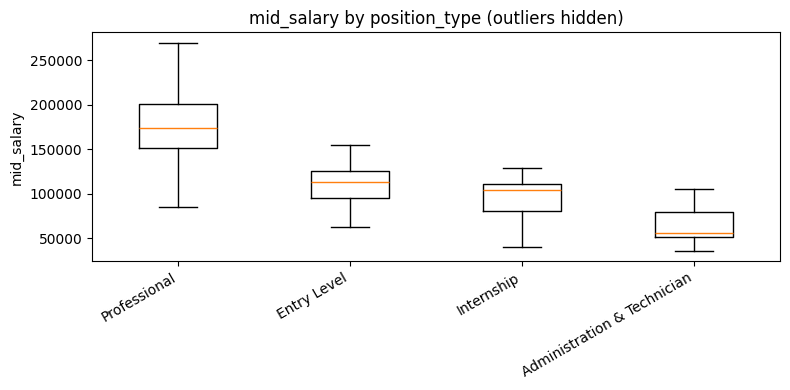

Kruskal-Wallis test: mid_salary by position_type
H statistic = 295.3713
p-value     = 9.98908e-64


In [26]:
# filter missing
df_pos = df3_salary.dropna(subset=["position_type"]).copy()

pos_summary = (
    df_pos.groupby("position_type")["mid_salary"]
    .agg(n="count", median="median", mean="mean")
    .sort_values("median", ascending=False)
)
display(pos_summary)

# Boxplot (outliers hidden)
plt.figure(figsize=(8, 4))
data_to_plot = [df_pos.loc[df_pos["position_type"] == t, "mid_salary"].values for t in pos_summary.index]
plt.boxplot(data_to_plot, labels=pos_summary.index, showfliers=False)
plt.xticks(rotation=30, ha="right")
plt.ylabel("mid_salary")
plt.title("mid_salary by position_type (outliers hidden)")
plt.tight_layout()
plt.show()

# Kruskal-Wallis
pos_groups = [df_pos.loc[df_pos["position_type"] == t, "mid_salary"].dropna().values for t in pos_summary.index]
kw_stat2, kw_p2 = kruskal(*pos_groups)

print("Kruskal-Wallis test: mid_salary by position_type")
print(f"H statistic = {kw_stat2:.4f}")
print(f"p-value     = {kw_p2:.6g}")


## 3.3 Salary and required_education

Required education shows an overall gradient with higher requirements associated with higher median salary, but the group sizes are highly imbalanced. High School Diploma/GED and Bachelor’s Degree dominate the sample and display a clear median gap (about 112k vs 158k); Master’s Degree has a higher median (about 196.5k), while Doctorate Degree appears highest but is based on a very small n and should not be over-generalized. The Kruskal–Wallis test is significant (H≈88.60, p≈1.32e-17), providing statistical evidence that salary distributions differ across required education levels.


,n,median,mean
required_education,,,
Doctorate Degree,4,237750.0,228250.0
Master's Degree,8,196500.0,187337.5
Bachelor's Degree,221,158000.0,157287.5
Associate's Degree/College Diploma,7,124800.0,122411.428571
High School Diploma/GED,218,112192.0,121340.433486
Technical Diploma,1,51500.0,51500.0


/tmp/ipykernel_6489/1436391092.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=edu_summary.index, showfliers=False)


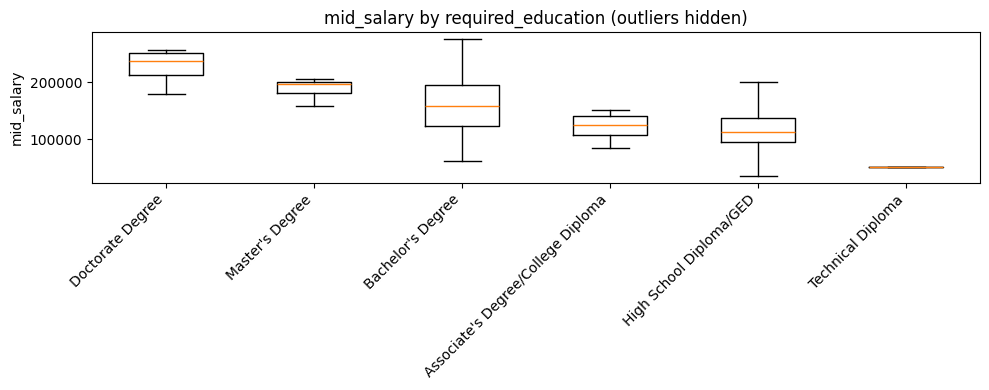

Kruskal-Wallis test: mid_salary by required_education
H statistic = 88.5993
p-value     = 1.32278e-17


In [27]:
df_edu = df3_salary.dropna(subset=["required_education"]).copy()

edu_summary = (
    df_edu.groupby("required_education")["mid_salary"]
    .agg(n="count", median="median", mean="mean")
    .sort_values("median", ascending=False)
)
display(edu_summary)

plt.figure(figsize=(10, 4))
data_to_plot = [df_edu.loc[df_edu["required_education"] == e, "mid_salary"].values for e in edu_summary.index]
plt.boxplot(data_to_plot, labels=edu_summary.index, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("mid_salary")
plt.title("mid_salary by required_education (outliers hidden)")
plt.tight_layout()
plt.show()

edu_groups = [df_edu.loc[df_edu["required_education"] == e, "mid_salary"].dropna().values for e in edu_summary.index]
kw_stat3, kw_p3 = kruskal(*edu_groups)

print("Kruskal-Wallis test: mid_salary by required_education")
print(f"H statistic = {kw_stat3:.4f}")
print(f"p-value     = {kw_p3:.6g}")


## 3.4 Association Between area_of_work and position_type

The contingency table indicates that the mix of position_type varies across area_of_work, suggesting meaningful structural differences. A chi-square test rejects independence (χ²≈112.78, dof=21, p≈1.48e-14), and Cramér’s V≈0.29 suggests a moderate association, implying that certain business areas disproportionately concentrate specific position types; this supports analyzing salary with both dimensions in mind rather than treating them as separable.

position_type,Administration & Technician,Entry Level,Internship,Professional
area_of_work,,,,
Consulting,0,14,7,95
Data & Analytics,0,4,5,7
Design & UX,0,4,5,4
Enterprise Operations,1,7,5,14
Infrastructure & Technology,9,24,39,28
Product Management,0,12,9,7
Sales,0,5,8,28
Software Engineering,0,13,21,68


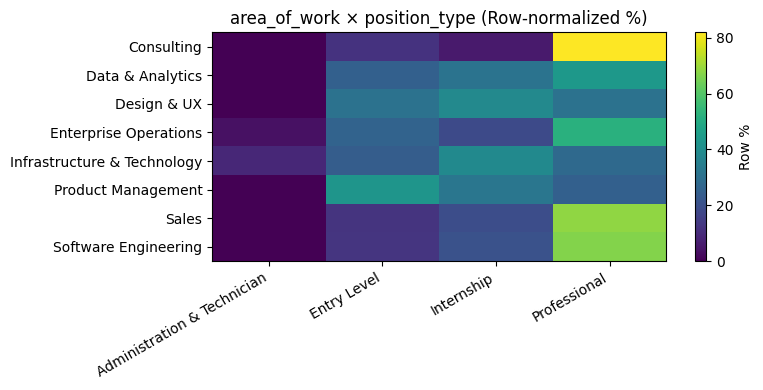

Chi-square test: area_of_work vs position_type:
chi2 = 112.7832, dof = 21, p-value = 1.47904e-14
Cramér's V = 0.2913  


In [28]:
from scipy.stats import chi2_contingency

# Use Top area_of_work，preventing matrix too big
top_areas2 = df3["area_of_work"].value_counts().head(8).index
df_cat = df3[df3["area_of_work"].isin(top_areas2)].dropna(subset=["area_of_work", "position_type"]).copy()

ct = pd.crosstab(df_cat["area_of_work"], df_cat["position_type"])
display(ct)

# Row-normalized (%)
ct_row = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 4))
plt.imshow(ct_row.values, aspect="auto")
plt.colorbar(label="Row %")
plt.xticks(range(ct_row.shape[1]), ct_row.columns, rotation=30, ha="right")
plt.yticks(range(ct_row.shape[0]), ct_row.index)
plt.title("area_of_work × position_type (Row-normalized %)")
plt.tight_layout()
plt.show()

# Chi-square
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square test: area_of_work vs position_type:")
print(f"chi2 = {chi2:.4f}, dof = {dof}, p-value = {p:.6g}")

# Cramér's V
n = ct.values.sum()
r, k = ct.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, k-1)))
print(f"Cramér's V = {cramers_v:.4f}  ")


## 3.5 Conclusion

Using robust summaries (medians and quantiles), salary differs significantly across business areas, position types, and required education levels, with position_type showing the strongest separation. The contingency analysis indicates that area_of_work and position_type are not independent and exhibit a moderate structural association, so salary gaps likely reflect both cross-area differences and differences in the composition of job levels within each area. For deeper explanation or modeling, position_type should be treated as a primary control variable, and stratification or interaction with area_of_work is likely informative.


# 4. Time Trends & Additional Checks

This section adds a time dimension to identify shifts in posting volume and salary levels over the observed window, and complements the analysis with outlier and missingness checks. Because the time span is relatively short and postings are concentrated near the end of the window, the discussion emphasizes descriptive evidence and reporting units, avoiding over-interpreting short-term fluctuations as long-run trends.


In [29]:
df4 = df2.copy()

if "date_posted_dt" not in df4.columns:
    df4["date_posted_dt"] = pd.to_datetime(df4["date_posted"], format="%d-%b-%Y", errors="coerce")

df4_time = df4.dropna(subset=["date_posted_dt"]).copy()
df4_time["week"] = df4_time["date_posted_dt"].dt.to_period("W").dt.start_time
df4_time["month"] = df4_time["date_posted_dt"].dt.to_period("M").dt.start_time

print("df4_time shape:", df4_time.shape)
print("Date range:", df4_time["date_posted_dt"].min().date(), "to", df4_time["date_posted_dt"].max().date())


df4_time shape: (471, 18)
Date range: 2025-08-14 to 2026-02-04


## 4.1 Posting Volume Over Time (Weekly/Monthly)

Monthly aggregation shows a strong concentration of postings in January 2026 (261), followed by February 2026 (84) and December 2025 (65), with far fewer in October (32) and November (28) 2025 and only a single posting in August. Weekly aggregation highlights a rapid ramp-up near the end of the sample: the series increases from the week of 2026-01-05 (27) to 01-12 (58) and 01-19 (61), peaks at 01-26 (115), and remains elevated in the week of 02-02 (84). Any time-trend interpretation should therefore be conditioned on the uneven posting volume over time.


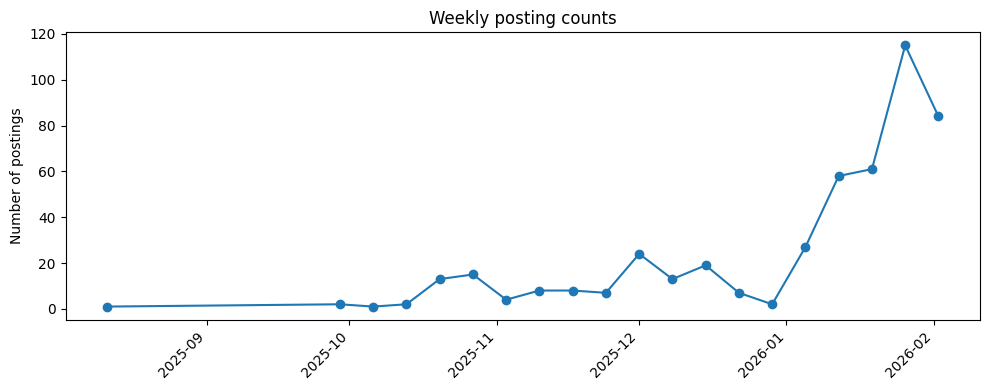

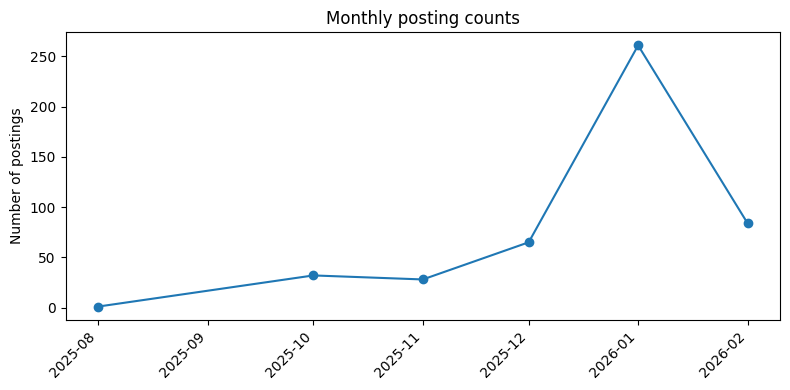

,weekly_count
week,
2025-12-01,24
2025-12-08,13
2025-12-15,19
2025-12-22,7
2025-12-29,2
2026-01-05,27
2026-01-12,58
2026-01-19,61
2026-01-26,115


,monthly_count
month,
2025-08-01,1
2025-10-01,32
2025-11-01,28
2025-12-01,65
2026-01-01,261
2026-02-01,84


In [30]:
weekly_counts = df4_time.groupby("week").size().sort_index()
monthly_counts = df4_time.groupby("month").size().sort_index()

# Weekly trend
plt.figure(figsize=(10, 4))
plt.plot(weekly_counts.index, weekly_counts.values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of postings")
plt.title("Weekly posting counts")
plt.tight_layout()
plt.show()

# Monthly trend
plt.figure(figsize=(8, 4))
plt.plot(monthly_counts.index, monthly_counts.values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of postings")
plt.title("Monthly posting counts")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"weekly_count": weekly_counts}).tail(10))
display(pd.DataFrame({"monthly_count": monthly_counts}))


## 4.2 Salary Over Time (Monthly Median + IQR)

Using postings with available salary, the monthly median mid_salary is about 107.3k in Nov 2025, increases to about 120k in Dec 2025, rises further to about 155.75k in Jan 2026, and then moderates to about 141k in Feb 2026. Sample sizes are much larger in Jan–Feb, so the higher median may reflect both genuine shifts and compositional changes due to concentrated posting activity; the interquartile range also indicates wider dispersion in early 2026, with a noticeably higher upper quartile suggesting more frequent high-paying roles during that period. Given the short window and end-loaded volume, it is best framed as a short-run level shift with potential composition effects rather than a long-run trend.


,n,median,q25,q75
month,,,,
2025-08-01,1,106800.0,106800.0,106800.0
2025-10-01,32,122750.0,111384.0,150900.0
2025-11-01,28,107300.0,100937.5,126000.0
2025-12-01,65,120000.0,101190.0,158000.0
2026-01-01,260,155750.0,111500.0,183500.0
2026-02-01,84,141000.0,107100.0,187375.0


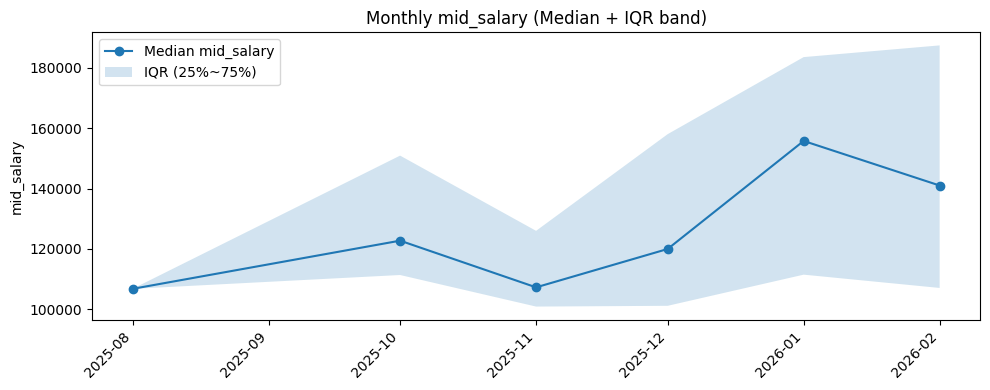

In [31]:
df4_sal = df4_time.dropna(subset=["mid_salary"]).copy()

monthly_salary = df4_sal.groupby("month")["mid_salary"].agg(
    n="count",
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).sort_index()

display(monthly_salary)

# Plot median line + IQR band
plt.figure(figsize=(10, 4))
plt.plot(monthly_salary.index, monthly_salary["median"].values, marker="o", label="Median mid_salary")
plt.fill_between(
    monthly_salary.index,
    monthly_salary["q25"].values,
    monthly_salary["q75"].values,
    alpha=0.2,
    label="IQR (25%~75%)"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("mid_salary")
plt.title("Monthly mid_salary (Median + IQR band)")
plt.tight_layout()
plt.legend()
plt.show()


## 4.3 Salary Trends by area_of_work (Top 4)

To reduce noise from very small groups, this subsection focuses on the four most frequent area_of_work categories and compares their monthly median salary trajectories. The main goal is not month-by-month micro-fluctuations, but whether there is a persistent ranking across areas and whether the January 2026 posting surge coincides with a level shift or divergence between areas. When a business area shows a clear median uplift in Jan–Feb alongside a jump in volume, it often points to a compositional change toward more senior or higher-paying roles, which should be interpreted together with the position_type mix.


area_of_work,Consulting,Infrastructure & Technology,Sales,Software Engineering
month,,,,
2025-10-01,18,8,1,1
2025-11-01,3,9,5,3
2025-12-01,8,23,2,11
2026-01-01,69,50,25,65
2026-02-01,18,10,8,22


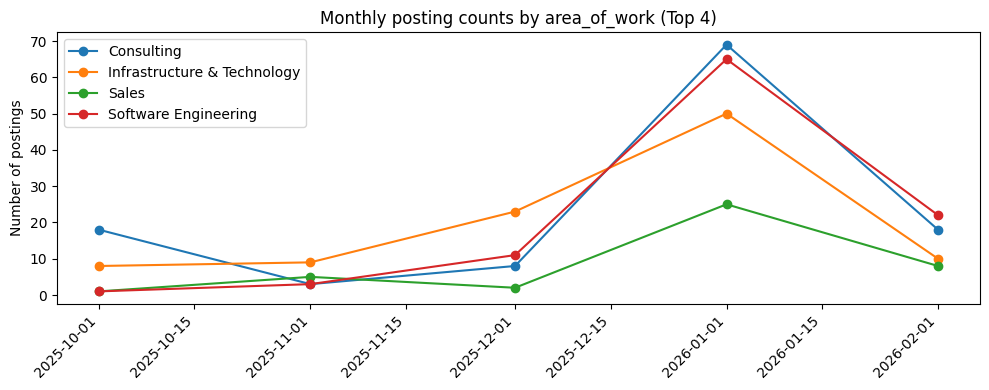

In [32]:
top_k = 4
top_areas = df4_time["area_of_work"].value_counts().head(top_k).index.tolist()

df_area_time = df4_time[df4_time["area_of_work"].isin(top_areas)].copy()
area_month_counts = pd.crosstab(df_area_time["month"], df_area_time["area_of_work"]).sort_index()

display(area_month_counts)

plt.figure(figsize=(10, 4))
for col in area_month_counts.columns:
    plt.plot(area_month_counts.index, area_month_counts[col].values, marker="o", label=col)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of postings")
plt.title(f"Monthly posting counts by area_of_work (Top {top_k})")
plt.tight_layout()
plt.legend()
plt.show()


## 4.4 Outliers and Extreme Salary Checks

The salary fields contain a small number of extreme values (for example, the maximum max_salary_num reaches 410k), which can disproportionately influence mean-variance summaries. For interpretability and robustness, medians and quantiles are preferred, and the highest-salary postings are worth a quick manual validation by checking whether the job title, business area, and position type plausibly align with the pay level while also confirming internal consistency between min_salary_num and max_salary_num. If modeling is pursued later, techniques such as log transforms, winsorization, or robust regression can reduce sensitivity to extremes without dropping observations.


In [33]:
df_out = df4_time.dropna(subset=["mid_salary"]).copy()

q1 = df_out["mid_salary"].quantile(0.25)
q3 = df_out["mid_salary"].quantile(0.75)
iqr = q3 - q1

low_thr = q1 - 1.5 * iqr
high_thr = q3 + 1.5 * iqr

outliers = df_out[(df_out["mid_salary"] < low_thr) | (df_out["mid_salary"] > high_thr)].copy()

print("Outlier detection (IQR) on mid_salary")
print(f"Q1={q1:,.0f}, Q3={q3:,.0f}, IQR={iqr:,.0f}")
print(f"Lower threshold={low_thr:,.0f}, Upper threshold={high_thr:,.0f}")
print(f"Outlier count={len(outliers)} out of {len(df_out)} ({len(outliers)/len(df_out)*100:.2f}%)")

# Top high / low salary examples
cols_show = ["job_id", "job_title", "date_posted", "state_province", "area_of_work", "position_type", "min_salary_num", "max_salary_num", "mid_salary", "salary_range"]

top_high = df_out.sort_values("mid_salary", ascending=False).head(10)[cols_show]
top_low = df_out.sort_values("mid_salary", ascending=True).head(10)[cols_show]

print("\nTop 10 highest mid_salary:")
display(top_high)

print("\nTop 10 lowest mid_salary:")
display(top_low)


Outlier detection (IQR) on mid_salary
Q1=107,100, Q3=178,500, IQR=71,400
Lower threshold=0, Upper threshold=285,600
Outlier count=1 out of 470 (0.21%)

Top 10 highest mid_salary:


,job_id,job_title,date_posted,state_province,area_of_work,position_type,min_salary_num,max_salary_num,mid_salary,salary_range
348,89533,"Principal Engineer, Db2 for z/OS",04-Feb-2026,California,Software Engineering,Professional,275000.0,410000.0,342500.0,135000.0
300,80088,Software Engineer - Streaming,03-Feb-2026,"Texas, Massachusetts, California",Software Engineering,Professional,220800.0,331200.0,276000.0,110400.0
71,86223,Ecosystem Technical Strategist,23-Jan-2026,"Texas, New York, California",Sales,Professional,162000.0,378000.0,270000.0,216000.0
377,90520,Senior Quantum Error Correction Theorist,03-Feb-2026,New York,Research,Professional,219000.0,296000.0,257500.0,77000.0
155,87906,Staff Software Engineer - HashiCorp Secure Run...,27-Jan-2026,"Texas, Massachusetts, California",Software Engineering,Professional,189000.0,324000.0,256500.0,135000.0
307,72905,Senior Digital Asset Sales,03-Feb-2026,New York,Sales,Professional,243000.0,270000.0,256500.0,27000.0
457,83085,Staff Engineer-Full Stack-HCP Terraform Founda...,05-Jan-2026,"Texas, North Carolina, Massachusetts, California",Software Engineering,Professional,189000.0,324000.0,256500.0,135000.0
10,72906,Senior Digital Asset Tech Sales,20-Jan-2026,New York,Sales,Professional,243000.0,270000.0,256500.0,27000.0
121,81989,U.S. Public Sector Compliance Officer,20-Dec-2025,"Texas, New York, Virginia, Alabama, Colorado, ...",Enterprise Operations,Professional,184000.0,317000.0,250500.0,133000.0
43,85759,Industry Quantum Consultant,12-Jan-2026,New York,Consulting,Professional,200000.0,280000.0,240000.0,80000.0



Top 10 lowest mid_salary:


,job_id,job_title,date_posted,state_province,area_of_work,position_type,min_salary_num,max_salary_num,mid_salary,salary_range
55,90253,Tier 1 Help Desk Analyst,03-Feb-2026,"Virginia, Maryland, West Virginia, District of...",Infrastructure & Technology,Administration & Technician,33000.0,38000.0,35500.0,5000.0
419,87033,Package Specialist Intern 2026 – Client Innova...,16-Jan-2026,"Michigan, Louisiana",Infrastructure & Technology,Internship,29120.0,51484.0,40302.0,22364.0
21,87269,Data Engineer Intern 2026 – Client Innovation ...,16-Jan-2026,"New York, Michigan, Louisiana",Data & Analytics,Internship,29120.0,51484.0,40302.0,22364.0
170,87026,Data Scientist Intern 2026 – Client Innovation...,19-Jan-2026,New York,Enterprise Operations,Internship,29120.0,51484.0,40302.0,22364.0
416,76379,"System Services Representatives - San Antonio, TX",23-Dec-2025,Texas,Infrastructure & Technology,Administration & Technician,33000.0,57000.0,45000.0,24000.0
17,86493,"System Services Representative - Monroe, LA",21-Jan-2026,Louisiana,Infrastructure & Technology,Administration & Technician,37000.0,66000.0,51500.0,29000.0
119,79935,System Services Representative - Nashville,30-Dec-2025,Tennessee,Infrastructure & Technology,Administration & Technician,37000.0,66000.0,51500.0,29000.0
402,89490,System Services Representative,04-Feb-2026,Illinois,Infrastructure & Technology,Administration & Technician,37000.0,66000.0,51500.0,29000.0
124,86951,IT Lab Tech - Thermal Apprentice,27-Jan-2026,New York,Infrastructure & Technology,Internship,49200.0,54120.0,51660.0,4920.0
162,90517,Mainframe System Verification Tester Apprentice,02-Feb-2026,New York,Infrastructure & Technology,Internship,49200.0,54120.0,51660.0,4920.0


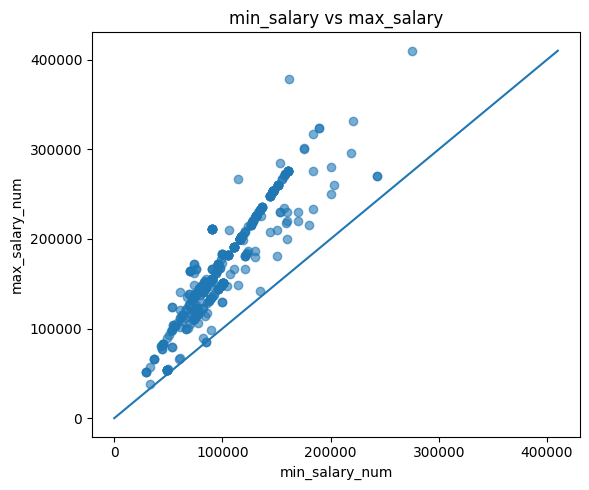

In [34]:
df_scatter = df4_time.dropna(subset=["min_salary_num", "max_salary_num"]).copy()

plt.figure(figsize=(6, 5))
plt.scatter(df_scatter["min_salary_num"], df_scatter["max_salary_num"], alpha=0.6)
mx = max(df_scatter["max_salary_num"].max(), df_scatter["min_salary_num"].max())
plt.plot([0, mx], [0, mx])  # 45-degree line
plt.xlabel("min_salary_num")
plt.ylabel("max_salary_num")
plt.title("min_salary vs max_salary")
plt.tight_layout()
plt.show()


In [35]:
df_range = df4_time.dropna(subset=["salary_range", "mid_salary"]).copy()

zero_range = df_range[df_range["salary_range"] == 0]
print("salary_range == 0 count:", len(zero_range), f"({len(zero_range)/len(df_range)*100:.2f}%)")

thr_range = df_range["salary_range"].quantile(0.99)
large_range = df_range[df_range["salary_range"] >= thr_range].sort_values("salary_range", ascending=False)

print("Top 1% salary_range threshold:", f"{thr_range:,.0f}")
display(large_range[["job_id","job_title","area_of_work","position_type","min_salary_num","max_salary_num","salary_range"]].head(15))


salary_range == 0 count: 2 (0.43%)
Top 1% salary_range threshold: 133,620


,job_id,job_title,area_of_work,position_type,min_salary_num,max_salary_num,salary_range
71,86223,Ecosystem Technical Strategist,Sales,Professional,162000.0,378000.0,216000.0
118,77937,Software Engineer - Opensearch,Software Engineering,Professional,114500.0,267100.0,152600.0
155,87906,Staff Software Engineer - HashiCorp Secure Run...,Software Engineering,Professional,189000.0,324000.0,135000.0
348,89533,"Principal Engineer, Db2 for z/OS",Software Engineering,Professional,275000.0,410000.0,135000.0
457,83085,Staff Engineer-Full Stack-HCP Terraform Founda...,Software Engineering,Professional,189000.0,324000.0,135000.0


## 4.5 Group Differences in Missingness

Overall missingness is much higher in preferred_education and preferred_technical_experience than in most other fields, and the grouped results suggest the missingness is not purely random: missing rates vary across business areas and position types, with some groups exceeding the overall averages. This implies that comparisons using “preferred” fields should always report sample sizes and missing rates, and should not interpret missing as “no requirement.” A safer reporting stance is to treat missing as “not disclosed / not provided” and note that these fields partly capture how detailed the posting text is, not only the underlying job requirements.


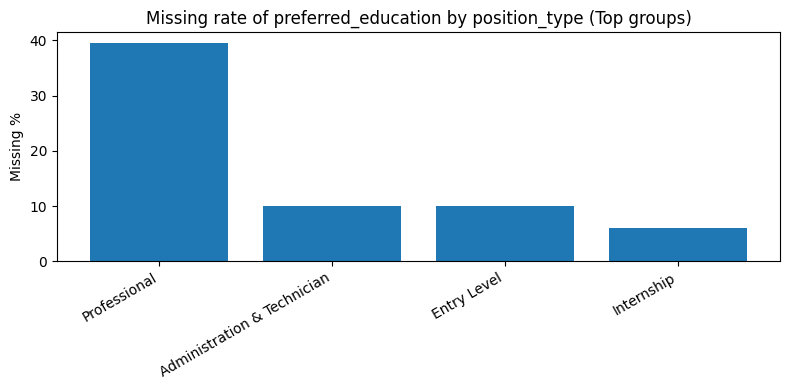

,missing_pct
position_type,
Professional,39.483395
Administration & Technician,10.000000
Entry Level,10.000000
Internship,6.000000


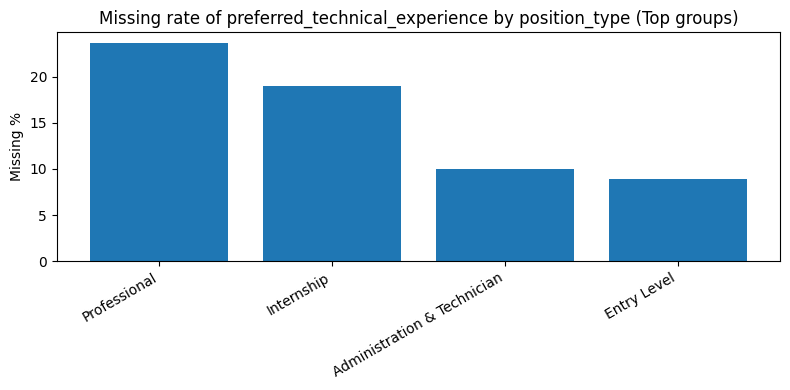

,missing_pct
position_type,
Professional,23.616236
Internship,19.000000
Administration & Technician,10.000000
Entry Level,8.888889


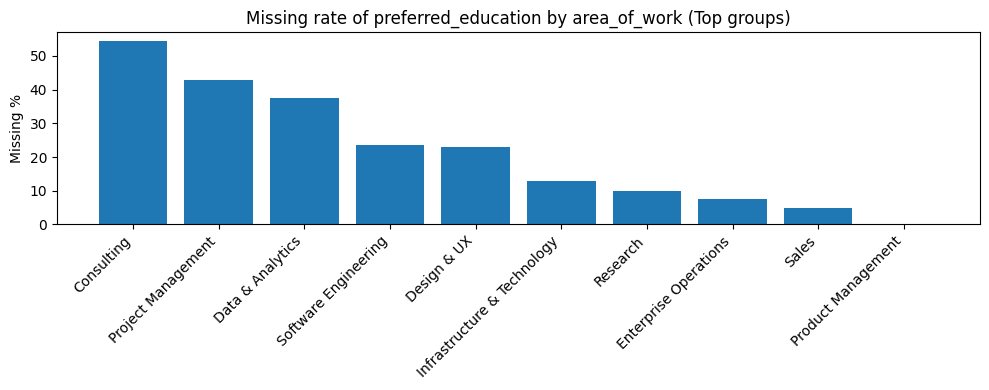

,missing_pct
area_of_work,
Consulting,54.310345
Project Management,42.857143
Data & Analytics,37.500000
Software Engineering,23.529412
Design & UX,23.076923
Infrastructure & Technology,13.000000
Research,10.000000
Enterprise Operations,7.407407
Sales,4.878049


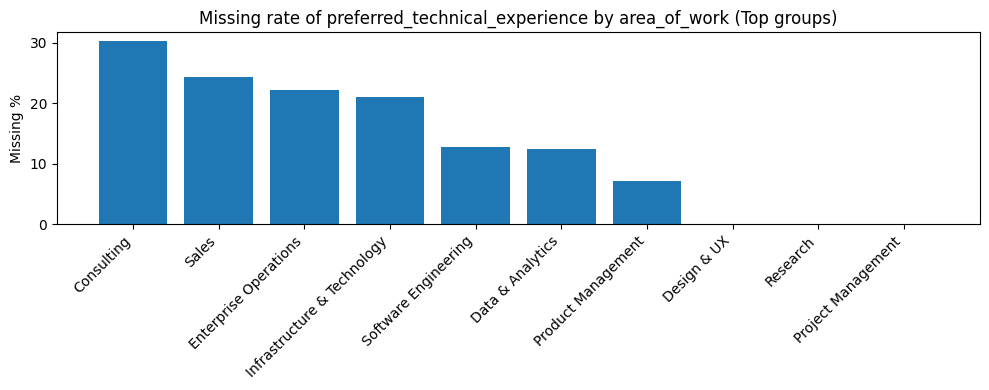

,missing_pct
area_of_work,
Consulting,30.172414
Sales,24.390244
Enterprise Operations,22.222222
Infrastructure & Technology,21.000000
Software Engineering,12.745098
Data & Analytics,12.500000
Product Management,7.142857
Design & UX,0.000000
Research,0.000000


In [36]:
def missing_rate_by_group(df, group_col, target_col, top_n=10):
    tmp = df.dropna(subset=[group_col]).copy()
    # only show top_n
    top_groups = tmp[group_col].value_counts().head(top_n).index
    tmp = tmp[tmp[group_col].isin(top_groups)]
    out = tmp.groupby(group_col)[target_col].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False)
    return out

# By position_type
mr_pos_prefedu = missing_rate_by_group(df4, "position_type", "preferred_education", top_n=10)
mr_pos_preftech = missing_rate_by_group(df4, "position_type", "preferred_technical_experience", top_n=10)

plt.figure(figsize=(8,4))
plt.bar(mr_pos_prefedu.index, mr_pos_prefedu.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Missing %")
plt.title("Missing rate of preferred_education by position_type (Top groups)")
plt.tight_layout()
plt.show()
display(mr_pos_prefedu.to_frame("missing_pct"))

plt.figure(figsize=(8,4))
plt.bar(mr_pos_preftech.index, mr_pos_preftech.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Missing %")
plt.title("Missing rate of preferred_technical_experience by position_type (Top groups)")
plt.tight_layout()
plt.show()
display(mr_pos_preftech.to_frame("missing_pct"))

# By area_of_work
mr_area_prefedu = missing_rate_by_group(df4, "area_of_work", "preferred_education", top_n=10)
mr_area_preftech = missing_rate_by_group(df4, "area_of_work", "preferred_technical_experience", top_n=10)

plt.figure(figsize=(10,4))
plt.bar(mr_area_prefedu.index, mr_area_prefedu.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing %")
plt.title("Missing rate of preferred_education by area_of_work (Top groups)")
plt.tight_layout()
plt.show()
display(mr_area_prefedu.to_frame("missing_pct"))

plt.figure(figsize=(10,4))
plt.bar(mr_area_preftech.index, mr_area_preftech.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing %")
plt.title("Missing rate of preferred_technical_experience by area_of_work (Top groups)")
plt.tight_layout()
plt.show()
display(mr_area_preftech.to_frame("missing_pct"))


## 4.6 Conclusion

Posting volume is heavily end-loaded, with a large concentration in January 2026, so short-run trends are best interpreted as a mixture of timing effects and compositional shifts rather than long-run patterns. Monthly median salary rises in early 2026 and dispersion widens, suggesting high-paying postings become more frequent during that period, but the interpretation should be tied back to changes in position_type and area_of_work composition. In addition, missingness in preferred fields varies by group, so any conclusions involving these variables should explicitly acknowledge reporting units, missingness behavior, and the resulting limitations to maintain robustness and reproducibility.


# 5. Data Preprocessing

## 5.1 Final Dataset Selection

To prepare the dataset for modeling-oriented preprocessing, we start from the de-duplicated dataset (`df_eda`), which contains 471 unique job postings.
The earlier sections focused on data cleaning and exploratory analysis; in this section, we transition from an analysis-ready dataset to a model-ready dataset. We therefore:

Use the de-duplicated dataset to avoid double-counting postings.
Retain variables relevant for salary modeling and categorical comparisons.
Exclude identifiers (e.g., `job_id`) that are not predictive features.
Ensure that only validated numeric salary fields (e.g., `min_salary_num`, `max_salary_num`, `mid_salary`, `salary_range`) are used.

This dataset will serve as the base for subsequent preprocessing steps, including missing value handling, categorical encoding, and numerical scaling.


In [37]:
# Start from de-duplicated dataset
df_model = df_eda.copy()

print("Initial df_model shape:", df_model.shape)

# Select relevant columns for modeling
model_cols = [
    "mid_salary",
    "salary_range",
    "min_salary_num",
    "max_salary_num",
    "position_type",
    "area_of_work",
    "required_education",
    "preferred_education",
    "date_posted_dt"
]

df_model = df_model[model_cols].copy()

print("Selected modeling columns shape:", df_model.shape)
df_model.head()

Initial df_model shape: (471, 16)
Selected modeling columns shape: (471, 9)


,mid_salary,salary_range,min_salary_num,max_salary_num,position_type,area_of_work,required_education,preferred_education,date_posted_dt
0,128520.0,75600.0,90720.0,166320.0,Internship,Software Engineering,High School Diploma/GED,Bachelor's Degree,2026-01-30
1,196000.0,104000.0,144000.0,248000.0,Professional,Software Engineering,Bachelor's Degree,<NA>,2025-11-26
2,178500.0,95000.0,131000.0,226000.0,Professional,Software Engineering,High School Diploma/GED,Bachelor's Degree,2026-02-03
3,114562.5,29375.0,99875.0,129250.0,Professional,Infrastructure & Technology,Bachelor's Degree,Master's Degree,2025-12-19
4,200500.0,107000.0,147000.0,254000.0,Professional,Enterprise Operations,Bachelor's Degree,Master's Degree,2026-01-29


## 5.2 Missing Value Strategy

To prepare a model-ready dataset, we implement differentiated missing value handling strategies for numerical and categorical variables.

### Numerical Variables

The following salary-related variables are considered core modeling variables:

1. `mid_salary`
2. `min_salary_num`
3. `max_salary_num`
4. `salary_range`

Because these variables directly determine compensation levels and form the basis of downstream modeling, observations with missing values in any of these fields are removed. Given the very low missingness observed in earlier sections, this removal does not materially reduce the dataset size.

### Categorical Variables

For categorical education variables:

1. `preferred_education`
2. `required_education`

Missing values are replaced with `"Unknown"` rather than dropped. In this context, missingness may reflect that the information was not disclosed in the posting, rather than being truly absent. Treating missing values as an explicit category preserves sample size and avoids introducing bias through case deletion.


In [38]:
print("Before missing value handling:", df_model.shape)

num_core_cols = [
    "mid_salary",
    "min_salary_num",
    "max_salary_num",
    "salary_range"
]

missing_num_count = df_model[num_core_cols].isna().any(axis=1).sum()
print("Rows with missing core numerical variables:", missing_num_count)

df_model = df_model.dropna(subset=num_core_cols).copy()

print("After dropping numeric NA:", df_model.shape)

cat_cols = ["preferred_education", "required_education"]

for col in cat_cols:
    missing_cat = df_model[col].isna().sum()
    print(f"Missing in {col} before fill:", missing_cat)
    df_model[col] = df_model[col].fillna("Unknown")

print("\nCheck remaining missing values:")
print(df_model[num_core_cols + cat_cols].isna().sum())


Before missing value handling: (471, 9)
Rows with missing core numerical variables: 1
After dropping numeric NA: (470, 9)
Missing in preferred_education before fill: 123
Missing in required_education before fill: 11

Check remaining missing values:
mid_salary             0
min_salary_num         0
max_salary_num         0
salary_range           0
preferred_education    0
required_education     0
dtype: int64


## 5.3 Rare Category Pooling

Many categorical variables in scraped job-posting data exhibit a **long-tail distribution**: a small number of categories appear frequently, while many categories appear only a handful of times.  

If we directly one-hot encode these categories, we may create a large number of sparse dummy variables, which can:
1. increase model complexity and variance,
2. reduce interpretability,
3. and cause unstable estimates for rare categories.

To address this, we **pool rare categories into an `"Other"` group** based on a frequency threshold. This retains the main signal from frequent categories while controlling dimensionality. In our implementation, we pooled categories with fewer than 10 occurrences into an “Other” group to reduce sparsity in one-hot encoding.


In [39]:
print("Before rare pooling:", df_model.shape)

# Categorical columns to pool (adjust if you include more later)
cat_cols = [
    "preferred_education",
    "required_education",
    "position_type",
    "area_of_work",
]

# Helper: pool rare categories based on minimum count or minimum proportion
def pool_rare(series, min_count=10, min_prop=None, other_label="Other"):
    """
    Pool rare categories into `other_label`.

    Parameters
    ----------
    series : pd.Series
        Categorical column.
    min_count : int
        Categories with count < min_count will be pooled.
    min_prop : float or None
        Alternative threshold using proportion (e.g., 0.01). If provided, overrides min_count.
    other_label : str
        Label for pooled categories.
    """
    s = series.astype("string").fillna("Unknown").str.strip()

    vc = s.value_counts(dropna=False)

    if min_prop is not None:
        rare_cats = vc[vc / vc.sum() < min_prop].index
    else:
        rare_cats = vc[vc < min_count].index

    return s.where(~s.isin(rare_cats), other_label)


MIN_COUNT = 10          # good default for ~471 rows


# Apply pooling + show before/after category counts
for col in cat_cols:
    print(f"\n--- {col} ---")
    before_n = df_model[col].nunique(dropna=False)
    print("Unique categories (before):", before_n)
    print("Top counts (before):")
    print(df_model[col].value_counts(dropna=False).head(10))

    df_model[col] = pool_rare(df_model[col], min_count=MIN_COUNT, min_prop=None, other_label="Other")

    after_n = df_model[col].nunique(dropna=False)
    print("Unique categories (after):", after_n)
    print("Top counts (after):")
    print(df_model[col].value_counts(dropna=False).head(10))

print("\nAfter rare pooling:", df_model.shape)


Before rare pooling: (470, 9)

--- preferred_education ---
Unique categories (before): 7
Top counts (before):
preferred_education
Bachelor's Degree                     240
Unknown                               123
Master's Degree                        71
Associate's Degree/College Diploma     21
Doctorate Degree                       10
High School Diploma/GED                 3
Technical Diploma                       2
Name: count, dtype: Int64
Unique categories (after): 6
Top counts (after):
preferred_education
Bachelor's Degree                     240
Unknown                               123
Master's Degree                        71
Associate's Degree/College Diploma     21
Doctorate Degree                       10
Other                                   5
Name: count, dtype: Int64

--- required_education ---
Unique categories (before): 7
Top counts (before):
required_education
Bachelor's Degree                     221
High School Diploma/GED               218
Unknown              

## 5.4 Encoding Strategy

Most predictors in this project are **categorical** (e.g., education, area of work, position type). Since common statistical and machine learning models require numeric inputs, we convert categorical variables into numeric features.

### Why One-Hot Encoding?

We use **one-hot encoding** because these categories are **nominal** (no guaranteed ordinal ranking). One-hot encoding:
1. avoids imposing an artificial order (which would happen with label encoding),
2. allows models to estimate separate effects for each category,
3. and is widely compatible with linear models and many ML models.

To reduce multicollinearity in linear models, we apply `drop_first=True` so that one level is treated as the reference category.


In [40]:
print("Before encoding:", df_model.shape)

# Identify categorical columns (object/string/category)
cat_cols = df_model.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("Categorical columns to encode:", cat_cols)

df_encoded = pd.get_dummies(
    df_model,
    columns=cat_cols,
    drop_first=True,      # avoid dummy trap for linear models
    dtype=int             # keep as 0/1
)

print("After encoding:", df_encoded.shape)

print("\nRemaining missing values (top):")
print(df_encoded.isna().sum().sort_values(ascending=False).head(10))

df_encoded.head()

# Compare number of features before/after encoding
print("Num features before:", df_model.shape[1])
print("Num features after :", df_encoded.shape[1])


Before encoding: (470, 9)
Categorical columns to encode: ['position_type', 'area_of_work', 'required_education', 'preferred_education']
After encoding: (470, 25)

Remaining missing values (top):
mid_salary                       0
salary_range                     0
min_salary_num                   0
max_salary_num                   0
date_posted_dt                   0
position_type_Entry Level        0
position_type_Internship         0
position_type_Professional       0
area_of_work_Data & Analytics    0
area_of_work_Design & UX         0
dtype: int64
Num features before: 9
Num features after : 25


## 5.5 Numerical Scaling

The salary-related variables (`mid_salary`, `min_salary_num`, `max_salary_num`, `salary_range`) are measured on large monetary scales and have different ranges.

To ensure numerical stability and comparability across features, we apply **standardization (z-score scaling)**:

$$
X_{scaled} = \frac{X - \mu}{\sigma}
$$

### Why Standardize?

1. Salary variables are measured in thousands, while dummy variables are 0/1.
2. Large-scale features may dominate optimization in gradient-based models.
3. Standardization improves numerical stability.
4. It makes coefficient magnitudes more comparable in linear models.
5. It is particularly important for regularized models (Ridge/Lasso) and distance-based models.

We use **StandardScaler**, which centers variables to mean 0 and variance 1.


In [41]:
from sklearn.preprocessing import StandardScaler

print("Before scaling:", df_encoded.shape)

# Identify numerical salary variables
num_cols = [
    "mid_salary",
    "min_salary_num",
    "max_salary_num",
    "salary_range"
]

# Initialize scaler
scaler = StandardScaler()

# Fit + transform
df_scaled = df_encoded.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

print("After scaling:", df_scaled.shape)

# Check means and stds
print("\nScaled variable means (should be ~0):")
print(df_scaled[num_cols].mean())

print("\nScaled variable std (should be ~1):")
print(df_scaled[num_cols].std())


Before scaling: (470, 25)
After scaling: (470, 25)

Scaled variable means (should be ~0):
mid_salary       -1.511793e-17
min_salary_num   -2.267690e-17
max_salary_num    1.511793e-17
salary_range      2.267690e-17
dtype: float64

Scaled variable std (should be ~1):
mid_salary        1.001066
min_salary_num    1.001066
max_salary_num    1.001066
salary_range      1.001066
dtype: float64


## 5.6 Final Model-Ready Dataset

After completing missing value handling, rare category pooling, one-hot encoding, and numerical scaling, we obtain the final model-ready dataset.

This dataset:

1. Contains only numeric variables
2. Has no missing values
3. Uses standardized salary features
4. Uses one-hot encoded categorical variables
5. Avoids high-dimensional sparse categories through pooling


In [42]:
df_final = df_scaled.copy()

print("Final dataset shape:")
print(df_final.shape)

print("\nNumber of features:")
print(df_final.shape[1])

print("\nAny remaining missing values?")
print(df_final.isna().sum().sum())

print("\nPreview:")
df_final.head()

print("\nSummary statistics (numeric variables):")
display(df_final.describe())

print("\nFeature types:")
print(df_final.dtypes.value_counts())

Final dataset shape:
(470, 25)

Number of features:
25

Any remaining missing values?
0

Preview:

Summary statistics (numeric variables):


,mid_salary,salary_range,min_salary_num,max_salary_num,date_posted_dt,position_type_Entry Level,position_type_Internship,position_type_Professional,area_of_work_Data & Analytics,area_of_work_Design & UX,area_of_work_Enterprise Operations,area_of_work_Infrastructure & Technology,area_of_work_Other,area_of_work_Product Management,area_of_work_Research,area_of_work_Sales,area_of_work_Software Engineering,required_education_High School Diploma/GED,required_education_Other,required_education_Unknown,preferred_education_Bachelor's Degree,preferred_education_Doctorate Degree,preferred_education_Master's Degree,preferred_education_Other,preferred_education_Unknown
count,4.700000e+02,4.700000e+02,4.700000e+02,4.700000e+02,470,470.000000,470.000000,470.000000,470.000000,470.00000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000
mean,-1.511793e-17,2.267690e-17,-2.267690e-17,1.511793e-17,2026-01-07 08:53:06.382978816,0.191489,0.212766,0.574468,0.034043,0.02766,0.057447,0.212766,0.036170,0.059574,0.021277,0.087234,0.217021,0.463830,0.042553,0.023404,0.510638,0.021277,0.151064,0.010638,0.261702
min,-2.203338e+00,-2.441568e+00,-2.050952e+00,-2.301005e+00,2025-08-14 00:00:00,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.147895e-01,-7.376790e-01,-7.813382e-01,-6.492330e-01,2025-12-22 00:00:00,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.555444e-01,-5.782724e-02,-1.409039e-01,-8.763033e-02,2026-01-21 00:00:00,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,7.696009e-01,7.958212e-01,6.790664e-01,8.043268e-01,2026-01-29 00:00:00,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,4.179125e+00,4.919233e+00,4.537750e+00,3.843588e+00,2026-02-04 00:00:00,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,1.001066e+00,1.001066e+00,1.001066e+00,1.001066e+00,NaN,0.393892,0.409700,0.494950,0.181532,0.16417,0.232942,0.409700,0.186912,0.236949,0.144459,0.282478,0.412656,0.499221,0.202063,0.151345,0.500419,0.144459,0.358493,0.102701,0.440030



Feature types:
int64             20
float64            4
datetime64[ns]     1
Name: count, dtype: int64


# 6. Feature Engineering

### 6.1 Load and standardize

Before creating advanced features, we need to make sure the dataset is consistent and machine-readable. Job datasets often include formatting issues (extra spaces, inconsistent categories, dates stored as strings, salaries stored with commas). If we don’t standardize these first, feature engineering steps can fail or create misleading categories. I strip whitespace from text fields, parse date_posted into a real datetime column, and convert min_salary / max_salary into numeric values. I also remove duplicate job postings by job_id and drop rows missing core fields needed for salary modeling.

In [43]:
#import, load and basic normalization, somewhat similar to earlier steps but more systematic and modular for modeling preparation
import re
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

CSV_PATH = "ibm_jobs.csv"

df_raw = pd.read_csv(CSV_PATH)

#take out whitespace in all object columns (important for clean categories)
obj_cols = df_raw.select_dtypes(include="object").columns
df = df_raw.copy()
for c in obj_cols:
    df[c] = df[c].astype("string").str.strip()

df["date_posted_dt"] = pd.to_datetime(df["date_posted"], format="%d-%b-%Y", errors="coerce")

#convert salary strings like "90,720.00" to numeric
def to_numeric_money(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True)  #remove commas/$/spaces etc.
    s = s.replace({"": np.nan, "nan": np.nan})
    return pd.to_numeric(s, errors="coerce")

df["min_salary_num"] = to_numeric_money(df["min_salary"])
df["max_salary_num"] = to_numeric_money(df["max_salary"])

#drop duplicates (job_id is a natural key in this dataset)
df = df.drop_duplicates(subset=["job_id"]).copy()

#basic required fields: keep rows with core salary and title
df = df.dropna(subset=["job_title", "min_salary_num", "max_salary_num"]).copy()

#fill optional text fields so downstream text processing doesn't break
df["preferred_technical_experience"] = df["preferred_technical_experience"].fillna("").astype("string")
df["preferred_education"] = df["preferred_education"].fillna("Unknown").astype("string")
df["required_education"] = df["required_education"].fillna("Unknown").astype("string")
df["area_of_work"] = df["area_of_work"].fillna("Unknown").astype("string")
df["position_type"] = df["position_type"].fillna("Unknown").astype("string")
df["state_province"] = df["state_province"].fillna("Unknown").astype("string")

### 6.2 advanced engineered numeric salary vars

Raw min and max salary are informative, but they don’t directly summarize compensation in a way that models learn best. In real postings, salary often comes as a range, which contains extra information about how “wide” or uncertain the compensation band is. A job with a wide range may reflect flexible seniority or variable responsibility, which can correlate with the salary level. We create mid_salary (central estimate), salary_range (spread), salary_range_pct (spread normalized by level), and min_to_max_ratio (tight vs loose range). We also log-transform salary (log_mid_salary) because salary distributions are usually right-skewed; logging reduces skew and makes regression models more stable.

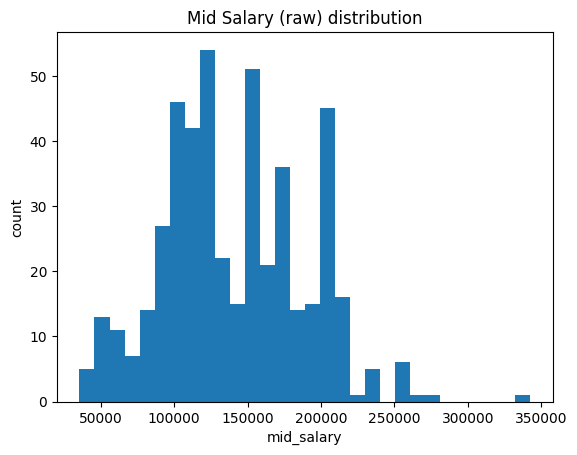

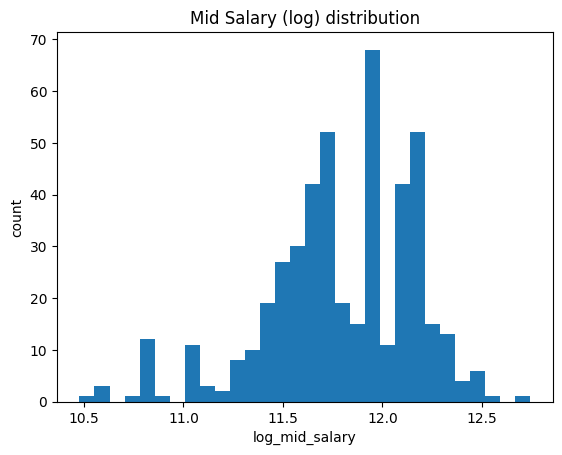

In [44]:
df["mid_salary"] = (df["min_salary_num"] + df["max_salary_num"]) / 2
df["salary_range"] = df["max_salary_num"] - df["min_salary_num"]

df["salary_range_pct"] = np.where(df["mid_salary"] > 0, df["salary_range"] / df["mid_salary"], np.nan)
df["min_to_max_ratio"] = np.where(df["max_salary_num"] > 0, df["min_salary_num"] / df["max_salary_num"], np.nan)

#log transform
df["log_mid_salary"] = np.log(df["mid_salary"].clip(lower=1))

plt.figure()
plt.hist(df["mid_salary"].dropna(), bins=30)
plt.title("Mid Salary (raw) distribution")
plt.xlabel("mid_salary")
plt.ylabel("count")
plt.show()
plt.figure()
plt.hist(df["log_mid_salary"].dropna(), bins=30)
plt.title("Mid Salary (log) distribution")
plt.xlabel("log_mid_salary")
plt.ylabel("count")
plt.show()


### 6.3 Data Features
Job markets are time-dependent: hiring tends to follow cycles (monthly/quarterly planning, end-of-year hiring changes), and more recent postings can reflect urgency or current salary norms. If we ignore time, we treat a posting from months ago the same as one from yesterday, which can reduce interpretability. We convert date_posted into features like days_since_posted (recency), plus calendar features (posted_month, posted_dow, posted_is_weekend) that can capture seasonal or scheduling patterns without adding external data.

In [45]:

max_date = df["date_posted_dt"].max()
df["days_since_posted"] = (max_date - df["date_posted_dt"]).dt.days

df["posted_year"] = df["date_posted_dt"].dt.year
df["posted_month"] = df["date_posted_dt"].dt.month
df["posted_dow"] = df["date_posted_dt"].dt.dayofweek  # Mon=0, Sun=6
df["posted_is_weekend"] = (df["posted_dow"] >= 5).astype(int)

### 6.4 Location Features
Location strongly impacts salary due to cost of living and labor market differences. In this dataset, state_province sometimes lists multiple states, which is important: multi-state or distributed postings likely reflect remote or flexible hiring, which can affect salary and role competitiveness. We split state_province into a list, then engineer n_states_listed and is_multi_state_posting to capture geographic flexibility. I also define a primary_state and map it into a coarse primary_region (Northeast/Midwest/South/West). This reduces noise from many unique states while keeping meaningful geographic structure.

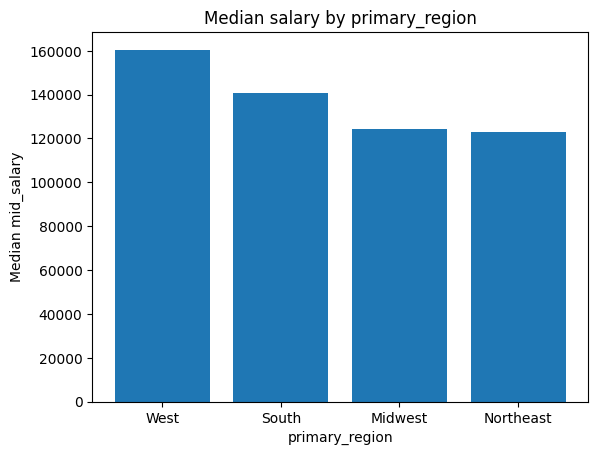

,primary_region,mid_salary
3,West,160500.0
2,South,140927.5
0,Midwest,124250.0
1,Northeast,123000.0


In [46]:
def split_states(x: str):
    if pd.isna(x) or x == "Unknown":
        return []
    parts = [p.strip() for p in str(x).split(",") if p.strip()]
    return parts

df["states_list"] = df["state_province"].apply(split_states)
df["n_states_listed"] = df["states_list"].apply(len)
df["is_multi_state_posting"] = (df["n_states_listed"] > 1).astype(int)

#use the first listed state as a “primary” state
df["primary_state"] = df["states_list"].apply(lambda L: L[0] if len(L) else "Unknown")

#map primary_state to US Census-like region buckets
REGION_MAP = {
    # Northeast
    "Maine":"Northeast","New Hampshire":"Northeast","Vermont":"Northeast","Massachusetts":"Northeast",
    "Rhode Island":"Northeast","Connecticut":"Northeast","New York":"Northeast","New Jersey":"Northeast",
    "Pennsylvania":"Northeast",
    # Midwest
    "Ohio":"Midwest","Michigan":"Midwest","Indiana":"Midwest","Wisconsin":"Midwest","Illinois":"Midwest",
    "Minnesota":"Midwest","Iowa":"Midwest","Missouri":"Midwest","North Dakota":"Midwest","South Dakota":"Midwest",
    "Nebraska":"Midwest","Kansas":"Midwest",
    # South
    "Delaware":"South","Maryland":"South","District of Columbia":"South","Virginia":"South","West Virginia":"South",
    "North Carolina":"South","South Carolina":"South","Georgia":"South","Florida":"South","Kentucky":"South",
    "Tennessee":"South","Mississippi":"South","Alabama":"South","Oklahoma":"South","Texas":"South","Arkansas":"South",
    "Louisiana":"South",
    # West
    "Idaho":"West","Montana":"West","Wyoming":"West","Nevada":"West","Utah":"West","Colorado":"West",
    "Arizona":"West","New Mexico":"West","Alaska":"West","Washington":"West","Oregon":"West","California":"West",
    "Hawaii":"West"
}
df["primary_region"] = df["primary_state"].map(REGION_MAP).fillna("Unknown")

region_med = df.groupby("primary_region")["mid_salary"].median().reset_index()
region_med = region_med.sort_values("mid_salary", ascending=False)

plt.figure()
plt.bar(region_med["primary_region"], region_med["mid_salary"])
plt.title("Median salary by primary_region")
plt.xlabel("primary_region")
plt.ylabel("Median mid_salary")
plt.show()

display(region_med)


### 6.5 Ordinal Education Features
Education requirements are naturally ordered (high school < bachelor’s < master’s < doctorate). Treating education as purely categorical throws away that ordering information. Also, the difference between required and preferred education can reflect how selective or advanced a role is, which often relates to compensation. I map education levels to an ordinal scale and create required_edu_level and preferred_edu_level. Then I compute edu_gap_preferred_minus_required to represent how much more the employer “wants” beyond the minimum. I also include a has_preferred_edu_specified indicator because missing preferred education may reflect less strict postings.

In [47]:
EDU_ORDER = {
    "Unknown": 0,
    "High School Diploma/GED": 1,
    "Technical Diploma": 2,
    "Associate's Degree/College Diploma": 3,
    "Bachelor's Degree": 4,
    "Master's Degree": 5,
    "Doctorate Degree": 6
}

df["required_edu_level"] = df["required_education"].map(EDU_ORDER).fillna(0).astype(int)
df["preferred_edu_level"] = df["preferred_education"].map(EDU_ORDER).fillna(0).astype(int)

#how much higher the preferred education is compared to minimum requirement
df["edu_gap_preferred_minus_required"] = df["preferred_edu_level"] - df["required_edu_level"]
df["has_preferred_edu_specified"] = (df["preferred_education"] != "Unknown").astype(int)


### 6.6 Job Title Parsing
Job titles contain extremely strong salary signals — words like “Senior,” “Lead,” “Manager,” and “Director” often correspond to pay bands and responsibility levels. Titles also indicate job families (engineering, data, security, product), which have different market rates. I extract binary flags for seniority markers (intern/entry/senior/lead/manager/director+) and role family categories using simple regex patterns. These engineered features are interpretable and help models capture compensation structure without requiring manual labeling of titles.

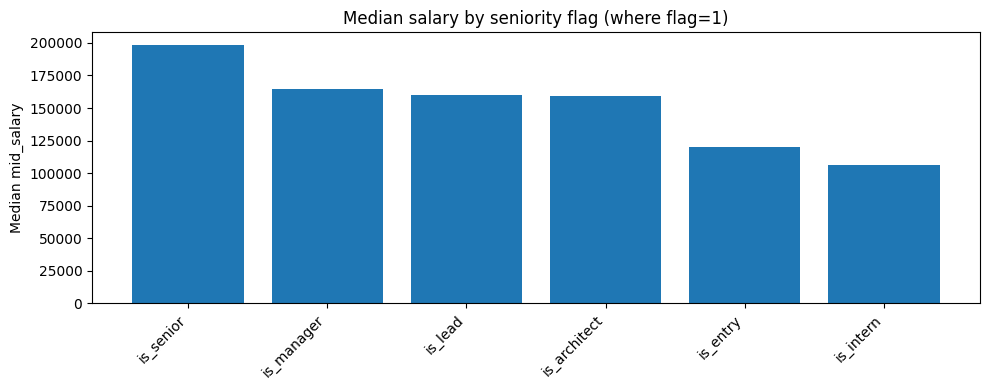

,feature,median_mid_salary,n
0,is_senior,198250.0,76
1,is_manager,164500.0,39
2,is_lead,159750.0,44
3,is_architect,159500.0,32
4,is_entry,120000.0,59
5,is_intern,106500.0,83


In [48]:
title = df["job_title"].fillna("").astype(str).str.lower()

def has_any(patterns, s):
    return int(any(re.search(p, s) for p in patterns))

SENIORITY_PATTERNS = {
    "is_intern": [r"\bintern\b"],
    "is_entry": [r"\bentry\b", r"\bjunior\b", r"\bjr\b"],
    "is_senior": [r"\bsenior\b", r"\bsr\b"],
    "is_lead": [r"\blead\b", r"\bprincipal\b", r"\bstaff\b"],
    "is_manager": [r"\bmanager\b", r"\bprogram manager\b", r"\bproduct manager\b"],
    "is_director_plus": [r"\bdirector\b", r"\bvp\b", r"\bvice president\b", r"\bchief\b"],
    "is_architect": [r"\barchitect\b"],
}

for col, pats in SENIORITY_PATTERNS.items():
    df[col] = title.apply(lambda s: has_any(pats, s))

#role family buckets
ROLE_PATTERNS = {
    "role_engineering": [r"\bengineer\b", r"\bdeveloper\b"],
    "role_data": [r"\bdata\b", r"\banalyst\b", r"\bml\b", r"\bmachine learning\b"],
    "role_security": [r"\bsecurity\b", r"\bcompliance\b", r"\brisk\b"],
    "role_product": [r"\bproduct\b"],
    "role_design": [r"\bdesign\b", r"\bux\b", r"\bui\b"],
    "role_sales": [r"\bsales\b", r"\baccount\b", r"\bclient\b"],
    "role_consulting": [r"\bconsult\b", r"\bconsultant\b"],
    "role_research": [r"\bresearch\b", r"\bscientist\b"],
    "role_devops": [r"\bdevops\b", r"\bsre\b", r"\bsite reliability\b"],
}
for col, pats in ROLE_PATTERNS.items():
    df[col] = title.apply(lambda s: has_any(pats, s))

df["title_len"] = df["job_title"].astype(str).str.len()
df["title_word_count"] = df["job_title"].astype(str).str.split().apply(len)

seniority_cols = ["is_intern", "is_entry", "is_senior", "is_lead", "is_manager", "is_director_plus", "is_architect"]

summary = []
for col in seniority_cols:
    if col in df.columns:
        subset = df[df[col] == 1]["mid_salary"].dropna()
        summary.append((col, subset.median(), subset.count()))
summary_df = pd.DataFrame(summary, columns=["feature", "median_mid_salary", "n"])

summary_df = summary_df.sort_values("median_mid_salary", ascending=False)

#make sure the salary column is numeric
summary_df["median_mid_salary"] = pd.to_numeric(summary_df["median_mid_salary"], errors="coerce")
#drop anything invalid
summary_df = summary_df.dropna(subset=["median_mid_salary"]).copy()
#reset index so positions are clean
summary_df = summary_df.sort_values("median_mid_salary", ascending=False).reset_index(drop=True)
#numeric positions
x = np.arange(len(summary_df))

#plot it to make sure we are doing okay so far
plt.figure(figsize=(10, 4))
plt.bar(x, summary_df["median_mid_salary"].astype(float).values)
plt.title("Median salary by seniority flag (where flag=1)")
plt.ylabel("Median mid_salary")
plt.xticks(x, summary_df["feature"].astype(str).values, rotation=45, ha="right")
plt.tight_layout()
plt.show()
display(summary_df)



### 6.7 Preferred Technical Experience
The preferred_technical_experience field contains high-value signals, but it’s unstructured text. Two postings might describe similar requirements in different wording. Turning this text into features allows analysis and modeling to pick up demand for specific tools (Python, AWS, SQL, ML) and experience levels (e.g., “5+ years”). I extract experience years (exp_years_min, exp_years_max, and whether any years were mentioned) using regex, create interpretable skill flags for common technologies, and compute n_skills_mentioned as a proxy for technical complexity. I also add text length features (exp_text_len, exp_text_word_count) as lightweight indicators of how detailed the requirements are.

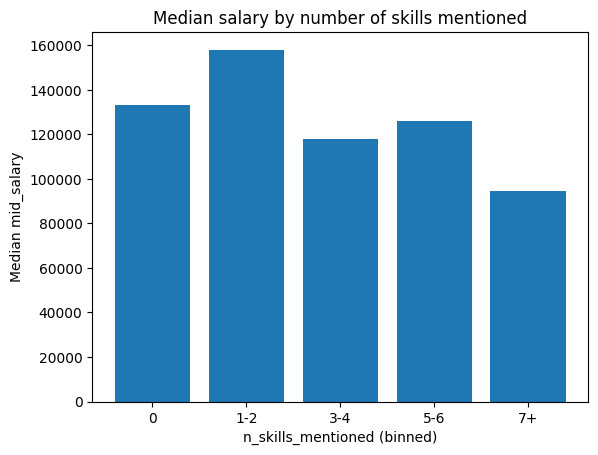

,skills_bin,mid_salary
0,0,133000.0
1,1-2,158000.0
2,3-4,117748.0
3,5-6,126000.0
4,7+,94350.0


In [49]:
#combine text fields so skill extraction sees both title n experience text
df["text_all"] = (df["job_title"].fillna("") + " " + df["preferred_technical_experience"].fillna("")).astype(str).str.lower()

#extract experience years (min / max mentioned)
YEAR_REGEX = re.compile(r"(\d+)\s*\+?\s*(?:years?|yrs?)\b")

def extract_years(text):
    nums = [int(m.group(1)) for m in YEAR_REGEX.finditer(text)]
    if len(nums) == 0:
        return pd.Series({"exp_years_min": np.nan, "exp_years_max": np.nan, "exp_years_any": 0})
    return pd.Series({"exp_years_min": min(nums), "exp_years_max": max(nums), "exp_years_any": 1})

years_df = df["preferred_technical_experience"].fillna("").astype(str).str.lower().apply(extract_years)
df = pd.concat([df, years_df], axis=1)

SKILL_PATTERNS = {
    "skill_python": r"\bpython\b",
    "skill_java": r"\bjava\b",
    "skill_sql": r"\bsql\b",
    "skill_r": r"\br\b(?![a-z])",
    "skill_aws": r"\baws\b|\bamazon web services\b",
    "skill_azure": r"\bazure\b",
    "skill_gcp": r"\bgcp\b|\bgoogle cloud\b",
    "skill_kubernetes": r"\bkubernetes\b|\bk8s\b",
    "skill_docker": r"\bdocker\b",
    "skill_linux": r"\blinux\b",
    "skill_spark": r"\bspark\b",
    "skill_tableau": r"\btableau\b",
    "skill_powerbi": r"\bpower\s*bi\b",
    "skill_ml": r"\bmachine learning\b|\bml\b",
    "skill_genai": r"\bgenerative ai\b|\bgenai\b|\bllm\b",
    "skill_security": r"\bsecurity\b|\biam\b|\bsiem\b",
    "skill_devops": r"\bci/cd\b|\bcicd\b|\bjenkins\b|\bterraform\b|\bansible\b",
    "skill_sap": r"\bsap\b|\bs\/4hana\b|\bhana\b",
}

for col, pat in SKILL_PATTERNS.items():
    df[col] = df["text_all"].str.contains(pat, regex=True).astype(int)

#how many distinct skills are mentioned, density
skill_cols = list(SKILL_PATTERNS.keys())
df["n_skills_mentioned"] = df[skill_cols].sum(axis=1)

df["exp_text_len"] = df["preferred_technical_experience"].astype(str).str.len()
df["exp_text_word_count"] = df["preferred_technical_experience"].astype(str).str.split().apply(len)

#bin number of skills and compare median salary
df["skills_bin"] = pd.cut(df["n_skills_mentioned"], bins=[-1,0,2,4,6,100],
                          labels=["0","1-2","3-4","5-6","7+"])

skills_med = df.groupby("skills_bin")["mid_salary"].median().reset_index()

plt.figure()
plt.bar(skills_med["skills_bin"].astype(str), skills_med["mid_salary"])
plt.title("Median salary by number of skills mentioned")
plt.xlabel("n_skills_mentioned (binned)")
plt.ylabel("Median mid_salary")
plt.show()
display(skills_med)


### 6.8 Final Feature Table for modeling (X) and target (y)
After feature engineering, we need a clean separation between predictors (X) and the target (y). We also want to avoid data leakage: if we predict salary, we should not include columns that directly encode the salary itself in raw form. We use log_mid_salary as the target because it reduces skew. We remove identifiers (job_id) and raw salary fields (min_salary, max_salary, and intermediate salary columns) from X, while keeping engineered predictors and relevant job attributes.

In [50]:
# ------------------------------------------------------------
# 6.8 Final Feature Table for modeling (X) and target (y)
# ------------------------------------------------------------

# Target: log-transformed midpoint salary
y = df["log_mid_salary"].copy()

# Salary-related columns should not be used as predictors.
# These columns directly contain salary information or are derived from salary,
# so keeping them would cause data leakage.
salary_leakage_cols = [
    "min_salary",
    "max_salary",
    "min_salary_num",
    "max_salary_num",
    "mid_salary",
    "salary_range",
    "salary_range_pct",
    "min_to_max_ratio",
    "log_mid_salary"
]

# Other columns that are identifiers or raw helper columns
other_drop_cols = [
    "job_id",
    "date_posted",
    "states_list"
]

drop_cols = salary_leakage_cols + other_drop_cols
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols).copy()

# Keep only rows with valid target values
valid_idx = y.notna() & np.isfinite(y)

X = X.loc[valid_idx].copy()
y = y.loc[valid_idx].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

# Check salary leakage
leakage_check = [
    "min_salary", "max_salary", "mid_salary", "log_mid_salary",
    "salary_range", "salary_range_pct", "min_to_max_ratio"
]

print("Salary leakage columns still in X:")
print([col for col in leakage_check if col in X.columns])

X shape: (469, 65)
y shape: (469,)
Salary leakage columns still in X:
[]


In [51]:
numeric_features = [
    # date
    "days_since_posted", "posted_month", "posted_dow", "posted_is_weekend",
    # location structure
    "n_states_listed", "is_multi_state_posting",
    # education ordinal
    "required_edu_level", "preferred_edu_level", "edu_gap_preferred_minus_required", "has_preferred_edu_specified",
    # title structure
    "title_len", "title_word_count",
    # experience derived
    "exp_years_min", "exp_years_max", "exp_years_any",
    "exp_text_len", "exp_text_word_count",
    # seniority + role flags
    "is_intern","is_entry","is_senior","is_lead","is_manager","is_director_plus","is_architect",
    "role_engineering","role_data","role_security","role_product","role_design","role_sales","role_consulting","role_research","role_devops",
    # skill flags
    "n_skills_mentioned",
] + skill_cols

categorical_features = [
    "state_province","primary_state","primary_region","area_of_work","position_type","required_education","preferred_education",
]

text_feature = "text_all"

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=2000,      #limit vocab size
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("txt", text_transformer, text_feature),
    ],
    remainder="drop"
)

#fit-transform into a model-ready matrix
X_processed = preprocessor.fit_transform(X, y)

print("Raw X shape:", X.shape)
print("Processed X shape:", X_processed.shape)
print("y shape:", y.shape)

#jus to show which engineered columns were added (quick sanity)
engineered_preview_cols = [
    "days_since_posted","n_states_listed","primary_region",
    "required_edu_level","edu_gap_preferred_minus_required",
    "is_senior","is_manager","role_data",
    "exp_years_min","n_skills_mentioned",
    "skill_python","skill_sql","skill_aws","skill_ml"
]
print("\nEngineered feature preview:")
display(df[engineered_preview_cols].head(8))


Raw X shape: (469, 65)
Processed X shape: (469, 2264)
y shape: (469,)

Engineered feature preview:


,days_since_posted,n_states_listed,primary_region,required_edu_level,edu_gap_preferred_minus_required,is_senior,is_manager,role_data,exp_years_min,n_skills_mentioned,skill_python,skill_sql,skill_aws,skill_ml
0,5,1,West,1,3,0,0,0,NaN,3,0,0,1,0
1,70,4,Midwest,4,-4,0,0,0,NaN,6,0,0,0,1
2,1,3,South,1,3,1,0,0,NaN,1,0,0,0,0
3,47,1,South,4,1,0,0,0,NaN,1,0,0,1,0
4,6,5,Midwest,4,1,1,0,0,NaN,0,0,0,0,0
5,97,9,South,4,0,0,0,0,NaN,3,1,0,0,0
6,96,9,South,1,3,0,0,0,NaN,1,0,0,0,0
7,75,3,South,1,3,0,0,0,NaN,5,1,1,0,0


# 7. Feature Engineering

## 7.1 Setup for Unsupervised Learning

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

# Check original feature table and target
print("Raw X shape before removing leakage:", X.shape)
print("Target y shape:", y.shape)

# Salary-related columns should NOT be used as input features.
# These variables are derived from the salary itself, so keeping them would cause leakage.
salary_leakage_cols = [
    "min_salary",
    "max_salary",
    "min_salary_num",
    "max_salary_num",
    "mid_salary",
    "salary_range",
    "salary_range_pct",
    "min_to_max_ratio",
    "log_mid_salary"
]

# Find leakage columns currently in X
leakage_in_X_before = [col for col in salary_leakage_cols if col in X.columns]
print("Salary leakage columns found in X before removal:", leakage_in_X_before)

# Remove leakage columns from X
X_clean = X.drop(columns=leakage_in_X_before).copy()

# Keep only rows with valid target values for later interpretation.
# Note: y is not used to create PCA or clusters; it is only used later to interpret results.
valid_idx = y.notna() & np.isfinite(y)

X_unsup_raw = X_clean.loc[valid_idx].copy()
df_unsup = df.loc[valid_idx].copy()
y_unsup = y.loc[valid_idx].copy()

# Confirm that no salary leakage columns remain in X_unsup_raw
leakage_in_X_after = [col for col in salary_leakage_cols if col in X_unsup_raw.columns]

print("Raw X shape after removing leakage:", X_clean.shape)
print("Unsupervised X shape:", X_unsup_raw.shape)
print("Unsupervised df shape:", df_unsup.shape)
print("Salary leakage columns found in X after removal:", leakage_in_X_after)

if len(leakage_in_X_after) == 0:
    print("No salary leakage columns remain in the unsupervised feature matrix.")
else:
    print("Warning: salary leakage columns still exist. Please check the feature list.")

Raw X shape before removing leakage: (469, 65)
Target y shape: (469,)
Salary leakage columns found in X before removal: []
Raw X shape after removing leakage: (469, 65)
Unsupervised X shape: (469, 65)
Unsupervised df shape: (469, 77)
Salary leakage columns found in X after removal: []
No salary leakage columns remain in the unsupervised feature matrix.


## 7.2 Correlation Structure

In [53]:
# For correlation analysis, we focus on numeric engineered features.
# Salary variables are included only for interpretation.
# They were NOT used for PCA or clustering.

corr_cols = []

# Add engineered numeric features from Section 6.
for col in numeric_features:
    if col in df_unsup.columns:
        corr_cols.append(col)

# Add salary variables only for interpretation.
# mid_salary is included here so that we can compare feature patterns with salary,
# but it will be removed from the top-correlation plot later.
for col in ["mid_salary", "log_mid_salary"]:
    if col in df_unsup.columns:
        corr_cols.append(col)

# Remove duplicated columns while preserving order.
corr_cols = list(dict.fromkeys(corr_cols))

# Keep only selected columns.
df_corr = df_unsup[corr_cols].copy()

# Keep only numeric columns.
df_corr = df_corr.select_dtypes(include=[np.number])

# Keep only columns with variation.
df_corr = df_corr.loc[:, df_corr.nunique(dropna=True) > 1]

# Compute correlation matrix.
corr_matrix = df_corr.corr(numeric_only=True)

print("Number of numeric variables used for correlation analysis:", df_corr.shape[1])
print("Correlation matrix shape:", corr_matrix.shape)

Number of numeric variables used for correlation analysis: 53
Correlation matrix shape: (53, 53)


### 7.2.1 Correlation Heatmap

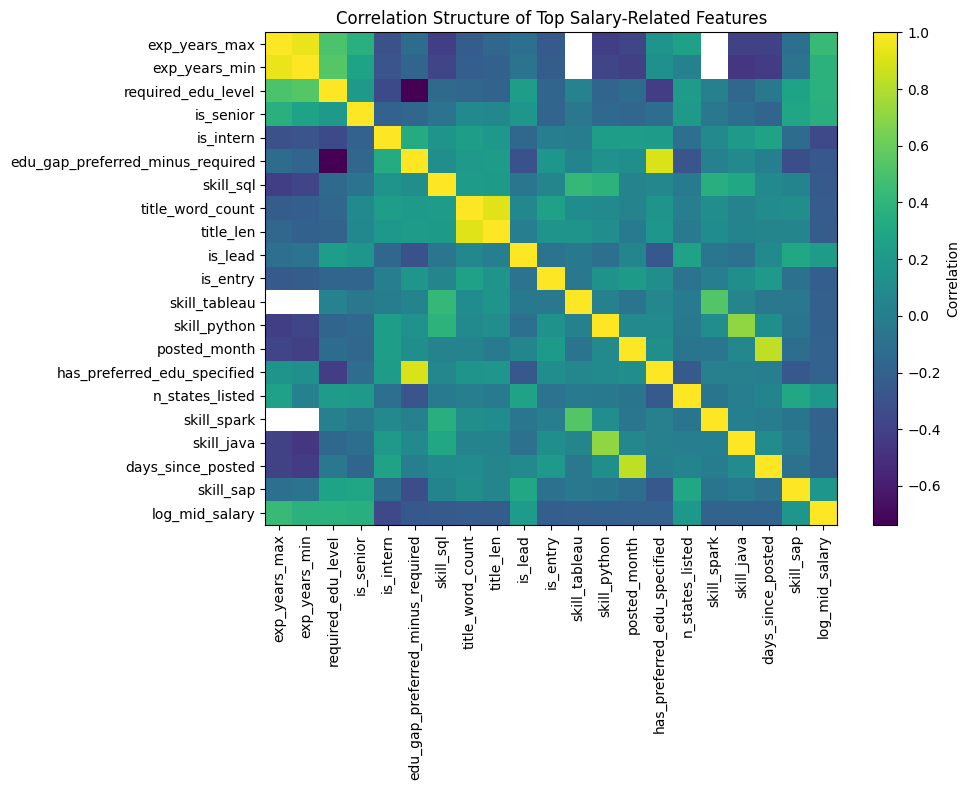

In [54]:
top_heatmap_cols = (
    corr_matrix["log_mid_salary"]
    .drop(labels=["log_mid_salary", "mid_salary"], errors="ignore")
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

heatmap_cols = top_heatmap_cols + ["log_mid_salary"]

corr_top = corr_matrix.loc[heatmap_cols, heatmap_cols]

plt.figure(figsize=(10, 8))
plt.imshow(corr_top, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=np.arange(len(corr_top.columns)),
    labels=corr_top.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(corr_top.columns)),
    labels=corr_top.columns
)

plt.title("Correlation Structure of Top Salary-Related Features")
plt.tight_layout()
plt.show()

# 7.2.2 Top Correlations with Salary

Top variables correlated with log_mid_salary, excluding salary-derived variables:


,correlation
exp_years_max,0.440161
exp_years_min,0.380029
required_edu_level,0.373493
is_senior,0.361991
is_intern,-0.356717
edu_gap_preferred_minus_required,-0.259310
skill_sql,-0.244182
title_word_count,-0.231327
title_len,-0.221569
is_lead,0.217343


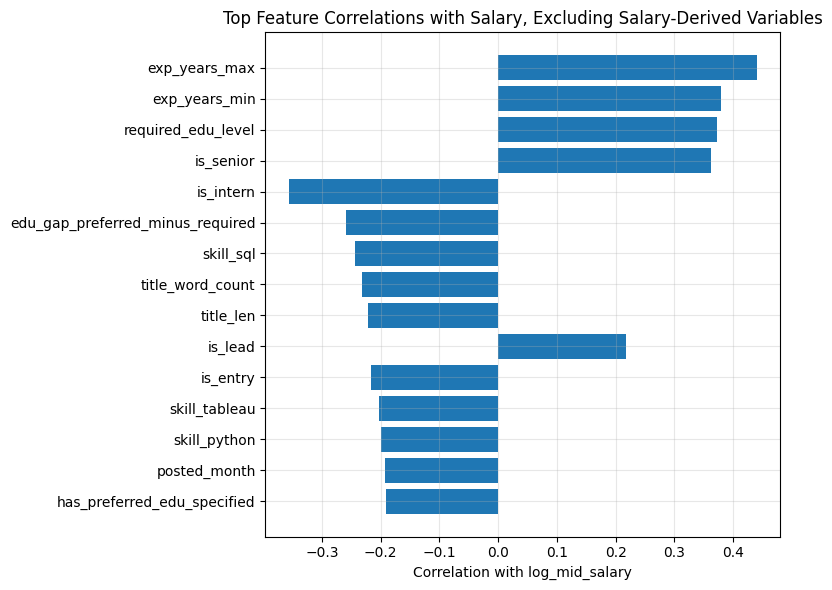

In [55]:
if "log_mid_salary" in corr_matrix.columns:
    salary_corr = (
        corr_matrix["log_mid_salary"]
        # Remove target itself and salary-derived variable.
        # mid_salary is almost the same information as log_mid_salary,
        # so it should not be shown as a regular feature.
        .drop(labels=["log_mid_salary", "mid_salary"], errors="ignore")
        .sort_values(key=lambda x: x.abs(), ascending=False)
    )

    print("Top variables correlated with log_mid_salary, excluding salary-derived variables:")
    display(salary_corr.head(20).to_frame("correlation"))

    top_corr_cols = salary_corr.head(15).index.tolist()

    plt.figure(figsize=(8, 6))
    plt.barh(
        top_corr_cols[::-1],
        salary_corr.loc[top_corr_cols][::-1]
    )
    plt.xlabel("Correlation with log_mid_salary")
    plt.title("Top Feature Correlations with Salary, Excluding Salary-Derived Variables")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("log_mid_salary is not available in the correlation matrix.")

## 7.3 PCA and Dimension Reduction

### 7.3.1 Preprocessing for PCA and Clustering

In [56]:
# This section prepares the unsupervised feature matrix for PCA and clustering.
# Salary variables have already been removed from X_unsup_raw.
# y_unsup and salary variables are only used later for interpretation.

from sklearn.preprocessing import FunctionTransformer

X_unsup_model = X_unsup_raw.copy()

# Identify column types
numeric_cols_unsup = X_unsup_model.select_dtypes(include=[np.number]).columns.tolist()

object_cols_unsup = X_unsup_model.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Text-heavy columns, if available
possible_text_cols = [
    "job_title",
    "preferred_technical_experience",
    "text_all"
]

text_cols_unsup = [col for col in possible_text_cols if col in X_unsup_model.columns]

# Categorical columns are object columns excluding text-heavy columns
categorical_cols_unsup = [
    col for col in object_cols_unsup
    if col not in text_cols_unsup
]

print("Number of numeric columns:", len(numeric_cols_unsup))
print("Number of categorical columns:", len(categorical_cols_unsup))
print("Text columns used:", text_cols_unsup)

# Fill missing text values before TF-IDF
for col in text_cols_unsup:
    X_unsup_model[col] = X_unsup_model[col].fillna("").astype(str)

# OneHotEncoder compatibility for different sklearn versions
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer_unsup = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_unsup = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

transformers_unsup = []

if len(numeric_cols_unsup) > 0:
    transformers_unsup.append(
        ("num", numeric_transformer_unsup, numeric_cols_unsup)
    )

if len(categorical_cols_unsup) > 0:
    transformers_unsup.append(
        ("cat", categorical_transformer_unsup, categorical_cols_unsup)
    )

# Add TF-IDF features for text columns
for col in text_cols_unsup:
    transformers_unsup.append(
        (
            f"tfidf_{col}",
            TfidfVectorizer(
                max_features=50,
                stop_words="english",
                ngram_range=(1, 2)
            ),
            col
        )
    )

preprocessor_unsup = ColumnTransformer(
    transformers=transformers_unsup,
    remainder="drop",
    sparse_threshold=0
)

X_unsup_processed = preprocessor_unsup.fit_transform(X_unsup_model)

print("Raw unsupervised feature matrix shape:", X_unsup_model.shape)
print("Processed unsupervised feature matrix shape:", X_unsup_processed.shape)

Number of numeric columns: 53
Number of categorical columns: 8
Text columns used: ['job_title', 'preferred_technical_experience', 'text_all']
Raw unsupervised feature matrix shape: (469, 65)
Processed unsupervised feature matrix shape: (469, 420)


### 7.3.2 PCA Explained Variance

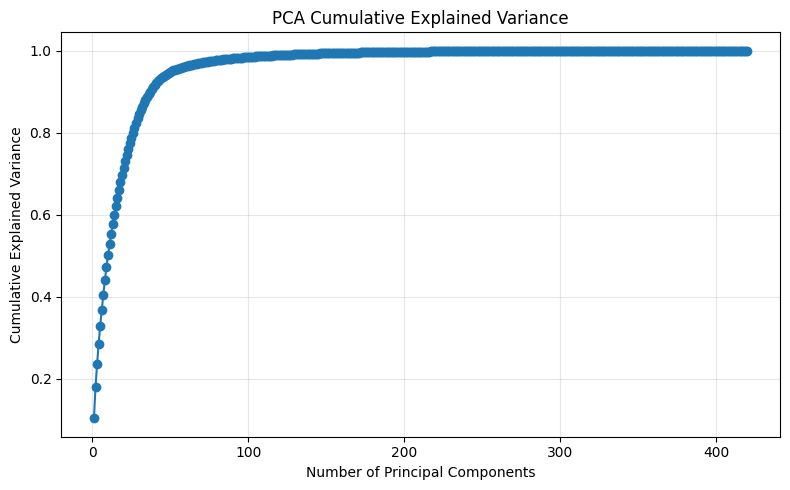

Explained variance ratio of first 10 principal components:
PC1: 0.1034
PC2: 0.0759
PC3: 0.0557
PC4: 0.0500
PC5: 0.0439
PC6: 0.0386
PC7: 0.0372
PC8: 0.0353
PC9: 0.0323
PC10: 0.0289
Number of PCs needed for 80% explained variance: 26
Number of PCs needed for 90% explained variance: 38


In [57]:
# PCA is used for dimensionality reduction and visualization.
# It summarizes the high-dimensional engineered feature space into principal components.

pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_unsup_processed)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cum_explained_var) + 1),
    cum_explained_var,
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Explained variance ratio of first 10 principal components:")
for i, value in enumerate(explained_var[:10], start=1):
    print(f"PC{i}: {value:.4f}")

# Find the number of PCs needed to explain 80% and 90% variance
n_pc_80 = np.argmax(cum_explained_var >= 0.80) + 1
n_pc_90 = np.argmax(cum_explained_var >= 0.90) + 1

print("Number of PCs needed for 80% explained variance:", n_pc_80)
print("Number of PCs needed for 90% explained variance:", n_pc_90)

### 7.3.3 Two-Dimensional PCA Projection

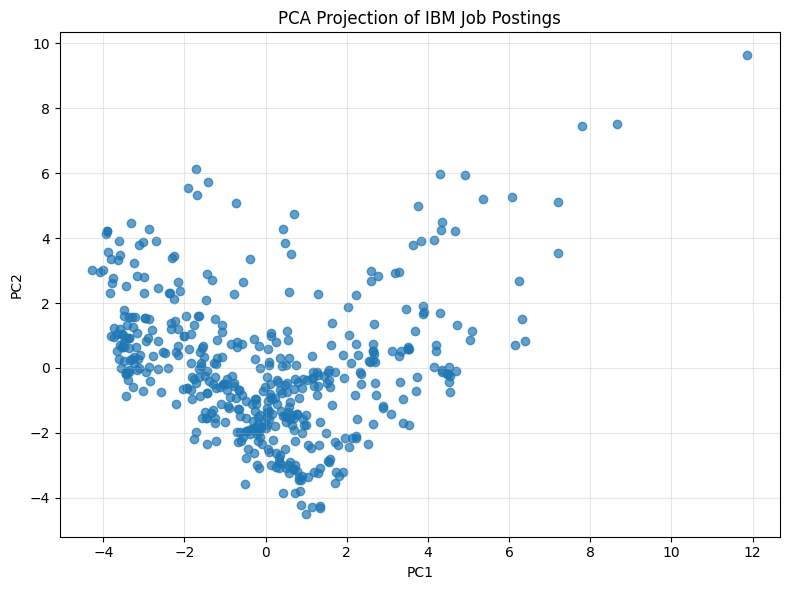

Explained variance by PC1 and PC2:
PC1: 0.1034
PC2: 0.0759
Total: 0.1793


In [58]:
# Use the first two principal components from the full PCA result for visualization.
# PC1 and PC2 are mainly used for plotting the high-dimensional job postings in 2D.

X_pca_2 = X_pca_full[:, :2]

df_unsup_results = df_unsup.copy()
df_unsup_results["PC1"] = X_pca_2[:, 0]
df_unsup_results["PC2"] = X_pca_2[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    df_unsup_results["PC1"],
    df_unsup_results["PC2"],
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of IBM Job Postings")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Explained variance by PC1 and PC2:")
print("PC1:", round(explained_var[0], 4))
print("PC2:", round(explained_var[1], 4))
print("Total:", round(explained_var[:2].sum(), 4))

## 7.4 K-Means Clustering

### 7.4.1 Choosing the Number of Clusters

Original processed feature matrix shape: (469, 420)
PCA-reduced clustering matrix shape: (469, 38)
Number of PCs used for clustering: 38


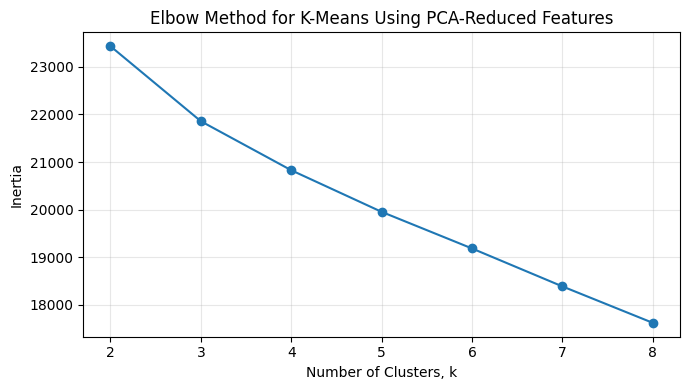

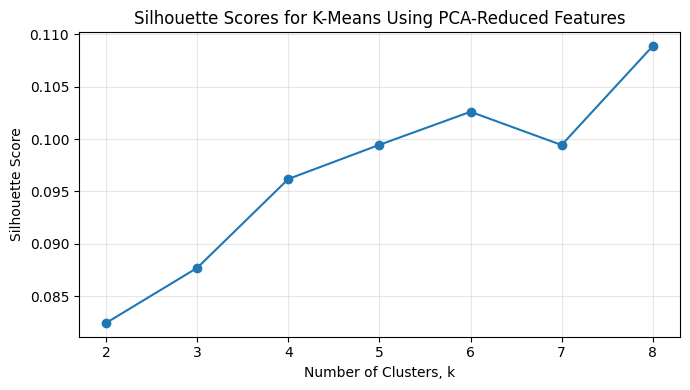

,k,inertia,silhouette_score
0,2,23434.702957,0.082449
1,3,21858.556322,0.087709
2,4,20828.499415,0.096191
3,5,19953.797053,0.099453
4,6,19184.499199,0.102607
5,7,18387.246911,0.099433
6,8,17621.453560,0.108872


Silhouette scores by k:
k=2: silhouette score = 0.0824
k=3: silhouette score = 0.0877
k=4: silhouette score = 0.0962
k=5: silhouette score = 0.0995
k=6: silhouette score = 0.1026
k=7: silhouette score = 0.0994
k=8: silhouette score = 0.1089
Best k based on silhouette score: 8


In [59]:
# K-means clustering is used to identify groups of similar job postings.
# Salary is not used to create clusters.
#
# Based on the PCA explained variance analysis, the first n_pc_90 components
# retain about 90% of the total variance. Therefore, we use the PCA-reduced
# feature matrix for clustering instead of the full 420-dimensional matrix.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the first n_pc_90 principal components for clustering.
# In the previous PCA section, n_pc_90 should be 38.
X_cluster = X_pca_full[:, :n_pc_90]

print("Original processed feature matrix shape:", X_unsup_processed.shape)
print("PCA-reduced clustering matrix shape:", X_cluster.shape)
print("Number of PCs used for clustering:", n_pc_90)

k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels_temp = kmeans_temp.fit_predict(X_cluster)

    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster, labels_temp)
    )

# Elbow plot
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of Clusters, k")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Using PCA-Reduced Features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Silhouette plot
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters, k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means Using PCA-Reduced Features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Store results in a table
cluster_selection_table = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(cluster_selection_table)

# Select best k based on silhouette score
best_k = list(k_values)[int(np.argmax(silhouette_scores))]

print("Silhouette scores by k:")
for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}: silhouette score = {score:.4f}")

print("Best k based on silhouette score:", best_k)

### 7.4.2 Final K-Means Clustering

Final k used for K-Means: 8
Clustering matrix shape: (469, 38)
Cluster counts:


,count
cluster,
0,73
1,188
2,76
3,27
4,53
5,25
6,6
7,21


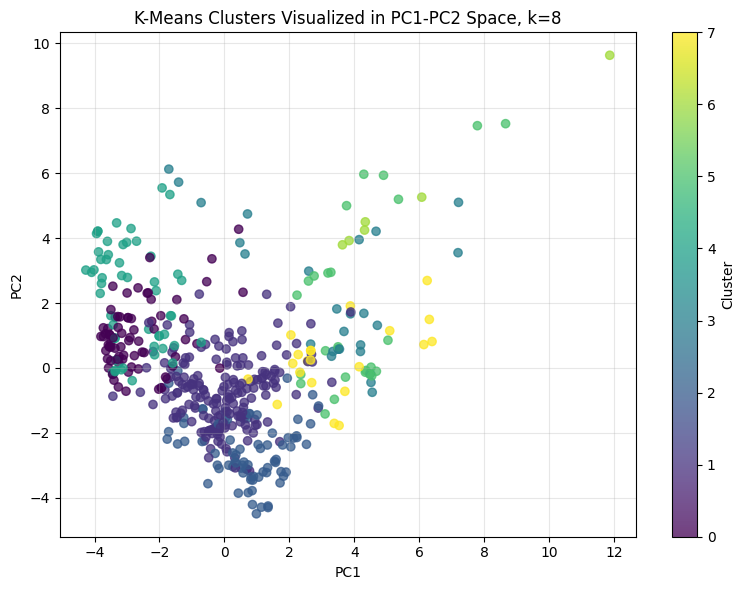

In [60]:
# Based on the silhouette score results, the best k is 8.
# The clustering is performed in the PCA-reduced feature space,
# using the first n_pc_90 principal components that retain about 90% variance.

print("Final k used for K-Means:", best_k)
print("Clustering matrix shape:", X_cluster.shape)

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

# Use PCA-reduced features for final clustering
cluster_labels = kmeans_final.fit_predict(X_cluster)

# Add cluster labels to the results dataframe
df_unsup_results["cluster"] = cluster_labels

print("Cluster counts:")
display(
    df_unsup_results["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

# Visualize clusters using the first two PCs.
# Note: clustering was done using the first n_pc_90 PCs, not only PC1 and PC2.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_unsup_results["PC1"],
    df_unsup_results["PC2"],
    c=df_unsup_results["cluster"],
    alpha=0.75
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters Visualized in PC1-PC2 Space, k={best_k}")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.5 Cluster Feature Patterns

In [61]:
# Salary was not used to create clusters.
# Here salary is used only to interpret whether different clusters have different compensation levels.
# Since k = 8 produced uneven cluster sizes, we include both counts and proportions.

# Basic cluster-level summary
cluster_summary = df_unsup_results.groupby("cluster").agg(
    n_jobs=("job_title", "count"),
    median_salary=("mid_salary", "median"),
    mean_salary=("mid_salary", "mean"),
    median_log_salary=("log_mid_salary", "median"),
    avg_required_edu_level=("required_edu_level", "mean"),
    avg_preferred_edu_level=("preferred_edu_level", "mean"),
    avg_exp_years_min=("exp_years_min", "mean"),
    avg_exp_years_max=("exp_years_max", "mean"),
    avg_n_skills=("n_skills_mentioned", "mean"),
    pct_intern=("is_intern", "mean"),
    pct_entry=("is_entry", "mean"),
    pct_senior=("is_senior", "mean"),
    pct_lead=("is_lead", "mean"),
    pct_manager=("is_manager", "mean"),
    pct_architect=("is_architect", "mean"),
    pct_data_role=("role_data", "mean"),
    pct_engineering_role=("role_engineering", "mean"),
    pct_consulting_role=("role_consulting", "mean"),
    pct_security_role=("role_security", "mean")
)

# Add cluster percentage
cluster_summary["pct_of_jobs"] = (
    cluster_summary["n_jobs"] / cluster_summary["n_jobs"].sum()
)

# Round numeric values
cluster_summary = cluster_summary.round(3)

# Most common area_of_work by cluster
top_area_by_cluster = (
    df_unsup_results.groupby("cluster")["area_of_work"]
    .agg(lambda x: x.value_counts(dropna=False).index[0])
    .to_frame("most_common_area_of_work")
)

# Most common position_type by cluster
top_position_by_cluster = (
    df_unsup_results.groupby("cluster")["position_type"]
    .agg(lambda x: x.value_counts(dropna=False).index[0])
    .to_frame("most_common_position_type")
)

# Most common primary_region by cluster, if available
if "primary_region" in df_unsup_results.columns:
    top_region_by_cluster = (
        df_unsup_results.groupby("cluster")["primary_region"]
        .agg(lambda x: x.value_counts(dropna=False).index[0])
        .to_frame("most_common_region")
    )
else:
    top_region_by_cluster = pd.DataFrame(index=cluster_summary.index)

# Combine all cluster profile information
cluster_profile = (
    cluster_summary
    .join(top_area_by_cluster)
    .join(top_position_by_cluster)
    .join(top_region_by_cluster)
)

# Reorder columns for easier interpretation
front_cols = [
    "n_jobs",
    "pct_of_jobs",
    "median_salary",
    "mean_salary",
    "median_log_salary",
    "most_common_area_of_work",
    "most_common_position_type"
]

if "most_common_region" in cluster_profile.columns:
    front_cols.append("most_common_region")

remaining_cols = [c for c in cluster_profile.columns if c not in front_cols]
cluster_profile = cluster_profile[front_cols + remaining_cols]

print("Cluster feature patterns:")
display(cluster_profile)

# Flag very small clusters for cautious interpretation
small_clusters = cluster_profile[cluster_profile["n_jobs"] < 10].index.tolist()

if len(small_clusters) > 0:
    print("Small clusters with fewer than 10 jobs:", small_clusters)
    print("These clusters may represent specialized postings or unusual feature patterns, so they should be interpreted cautiously.")

Cluster feature patterns:


,n_jobs,pct_of_jobs,median_salary,mean_salary,median_log_salary,most_common_area_of_work,most_common_position_type,most_common_region,avg_required_edu_level,avg_preferred_edu_level,avg_exp_years_min,avg_exp_years_max,avg_n_skills,pct_intern,pct_entry,pct_senior,pct_lead,pct_manager,pct_architect,pct_data_role,pct_engineering_role,pct_consulting_role,pct_security_role
cluster,,,,,,,,,,,,,,,,,,,,,,,
0,73,0.156,158000.0,153324.897,11.97,Consulting,Professional,South,3.712,0.000,4.000,4.200,0.384,0.014,0.027,0.082,0.014,0.096,0.247,0.082,0.110,0.151,0.000
1,188,0.401,150950.0,146904.332,11.925,Infrastructure & Technology,Professional,South,2.298,4.218,5.571,5.643,0.383,0.106,0.096,0.181,0.048,0.112,0.053,0.080,0.298,0.080,0.032
2,76,0.162,114781.25,118584.678,11.651,Infrastructure & Technology,Internship,South,1.961,4.026,2.500,2.500,0.289,0.395,0.276,0.039,0.039,0.132,0.026,0.053,0.237,0.053,0.013
3,27,0.058,120960.0,134530.259,11.703,Software Engineering,Internship,South,1.778,3.333,NaN,NaN,4.037,0.481,0.222,0.148,0.000,0.000,0.000,0.185,0.593,0.148,0.000
4,53,0.113,158000.0,169685.5,11.97,Consulting,Professional,South,3.962,1.132,3.667,5.333,0.849,0.000,0.019,0.491,0.585,0.000,0.038,0.189,0.038,0.528,0.057
5,25,0.053,99450.0,102590.2,11.507,Infrastructure & Technology,Entry Level,South,1.360,3.120,1.000,1.667,3.520,0.480,0.280,0.000,0.000,0.040,0.000,0.000,0.640,0.200,0.040
6,6,0.013,64355.0,68633.333,11.072,Software Engineering,Entry Level,South,3.000,4.667,NaN,NaN,4.500,0.167,0.000,0.000,0.000,0.000,0.000,0.167,0.833,0.000,0.000
7,21,0.045,134000.0,137741.0,11.806,Software Engineering,Professional,South,1.238,4.095,NaN,NaN,3.571,0.286,0.190,0.143,0.000,0.000,0.000,0.000,0.714,0.000,0.000


Small clusters with fewer than 10 jobs: [6]
These clusters may represent specialized postings or unusual feature patterns, so they should be interpreted cautiously.


### 7.5.1 Most Common Categorical Patterns by Cluster

In [62]:
# This section summarizes the most common categorical values in each cluster.
# We report both the modal category and its proportion within the cluster.

def most_common_value(x):
    x = x.dropna()
    if x.empty:
        return np.nan
    return x.value_counts().index[0]

def most_common_share(x):
    x = x.dropna()
    if x.empty:
        return np.nan
    return x.value_counts(normalize=True).iloc[0]

categorical_profile_cols = [
    "area_of_work",
    "position_type",
    "primary_region",
    "required_education",
    "preferred_education"
]

available_categorical_profile_cols = [
    col for col in categorical_profile_cols
    if col in df_unsup_results.columns
]

cluster_categorical_profile_parts = []

for col in available_categorical_profile_cols:
    temp = df_unsup_results.groupby("cluster")[col].agg(
        most_common=most_common_value,
        share=most_common_share
    )

    temp.columns = [
        f"{col}_mode",
        f"{col}_mode_share"
    ]

    cluster_categorical_profile_parts.append(temp)

cluster_categorical_profile = pd.concat(
    cluster_categorical_profile_parts,
    axis=1
).round(3)

print("Most common categorical patterns by cluster:")
display(cluster_categorical_profile)

Most common categorical patterns by cluster:


,area_of_work_mode,area_of_work_mode_share,position_type_mode,position_type_mode_share,primary_region_mode,primary_region_mode_share,required_education_mode,required_education_mode_share,preferred_education_mode,preferred_education_mode_share
cluster,,,,,,,,,,
0,Consulting,0.329,Professional,0.877,South,0.712,Bachelor's Degree,0.849,Unknown,1.000
1,Infrastructure & Technology,0.218,Professional,0.612,South,0.564,High School Diploma/GED,0.511,Bachelor's Degree,0.601
2,Infrastructure & Technology,0.316,Internship,0.408,South,0.539,High School Diploma/GED,0.671,Bachelor's Degree,0.750
3,Software Engineering,0.407,Internship,0.519,South,0.407,High School Diploma/GED,0.741,Bachelor's Degree,0.741
4,Consulting,0.925,Professional,0.981,South,0.698,Bachelor's Degree,0.962,Unknown,0.736
5,Infrastructure & Technology,0.640,Entry Level,0.480,South,0.600,High School Diploma/GED,0.880,Bachelor's Degree,0.720
6,Software Engineering,0.833,Entry Level,0.833,South,0.500,Bachelor's Degree,0.667,Master's Degree,0.667
7,Software Engineering,0.524,Professional,0.476,South,0.714,High School Diploma/GED,0.857,Bachelor's Degree,0.905


### 7.5.2 Salary Distribution by Cluster

/tmp/ipykernel_6489/2187016903.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


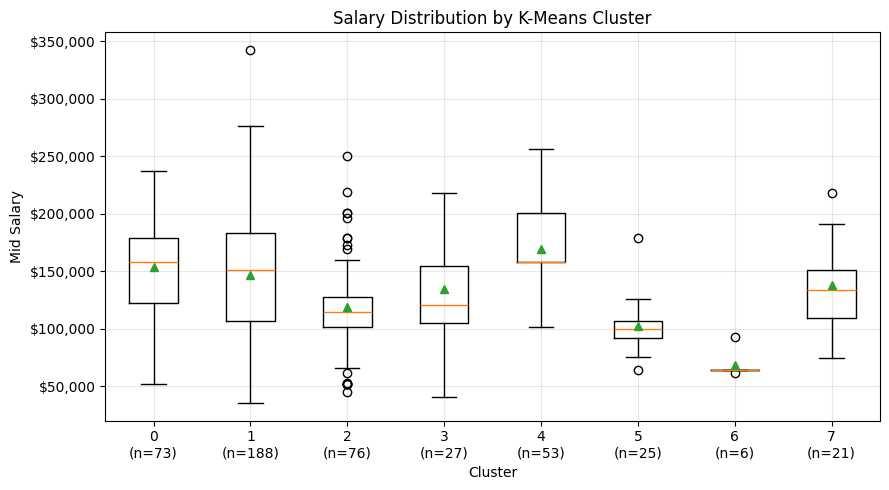

Salary summary by cluster:


,n_jobs,median_salary,mean_salary,min_salary,max_salary
cluster,,,,,
0,73,158000.0,153324.9,51500.0,237500.0
1,188,150950.0,146904.33,35500.0,342500.0
2,76,114781.25,118584.68,45000.0,250500.0
3,27,120960.0,134530.26,40302.0,218500.0
4,53,158000.0,169685.5,101460.0,256500.0
5,25,99450.0,102590.2,64355.0,178500.0
6,6,64355.0,68633.33,61880.0,92500.0
7,21,134000.0,137741.0,74960.0,218500.0


In [63]:
# Salary was NOT used to create clusters.
# We use salary here only to interpret whether the clusters differ in compensation.

import matplotlib.ticker as mtick

clusters_sorted = sorted(df_unsup_results["cluster"].unique())

salary_by_cluster = [
    df_unsup_results.loc[
        df_unsup_results["cluster"] == c,
        "mid_salary"
    ].dropna()
    for c in clusters_sorted
]

# Create x-axis labels with cluster sizes
cluster_sizes = (
    df_unsup_results["cluster"]
    .value_counts()
    .sort_index()
)

cluster_labels = [
    f"{c}\n(n={cluster_sizes.loc[c]})"
    for c in clusters_sorted
]

plt.figure(figsize=(9, 5))
plt.boxplot(
    salary_by_cluster,
    labels=cluster_labels,
    showmeans=True
)

plt.xlabel("Cluster")
plt.ylabel("Mid Salary")
plt.title("Salary Distribution by K-Means Cluster")
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table for salary distribution by cluster
salary_cluster_summary = (
    df_unsup_results
    .groupby("cluster")["mid_salary"]
    .agg(
        n_jobs="count",
        median_salary="median",
        mean_salary="mean",
        min_salary="min",
        max_salary="max"
    )
    .round(2)
)

print("Salary summary by cluster:")
display(salary_cluster_summary)

### 7.5.3 Skill Patterns by Cluster

Skill mention proportions by cluster:


,n_jobs,skill_python,skill_java,skill_sql,skill_r,skill_aws,skill_azure,skill_gcp,skill_kubernetes,skill_docker,skill_linux,skill_spark,skill_tableau,skill_powerbi,skill_ml,skill_genai,skill_security,skill_devops,skill_sap
cluster,,,,,,,,,,,,,,,,,,,
0,73,0.000,0.014,0.000,0.000,0.027,0.014,0.00,0.041,0.000,0.014,0.027,0.0,0.000,0.027,0.014,0.096,0.082,0.027
1,188,0.043,0.000,0.027,0.000,0.005,0.005,0.00,0.005,0.000,0.011,0.016,0.0,0.000,0.053,0.027,0.074,0.101,0.016
2,76,0.039,0.000,0.026,0.000,0.026,0.000,0.00,0.000,0.000,0.092,0.000,0.0,0.000,0.026,0.013,0.013,0.013,0.039
3,27,0.148,0.074,0.074,0.000,1.000,1.000,0.63,0.037,0.037,0.037,0.074,0.0,0.000,0.185,0.074,0.074,0.407,0.185
4,53,0.000,0.000,0.057,0.000,0.019,0.019,0.00,0.000,0.000,0.000,0.000,0.0,0.000,0.019,0.000,0.075,0.019,0.642
5,25,0.960,0.920,0.400,0.000,0.160,0.160,0.00,0.000,0.000,0.520,0.000,0.0,0.000,0.040,0.040,0.120,0.120,0.080
6,6,0.167,0.167,1.000,0.167,0.000,0.000,0.00,0.000,0.000,0.167,0.833,1.0,0.333,0.000,0.667,0.000,0.000,0.000
7,21,0.143,0.000,0.190,0.000,0.048,0.048,0.00,1.000,0.619,0.238,0.095,0.0,0.000,0.143,0.000,0.286,0.762,0.000


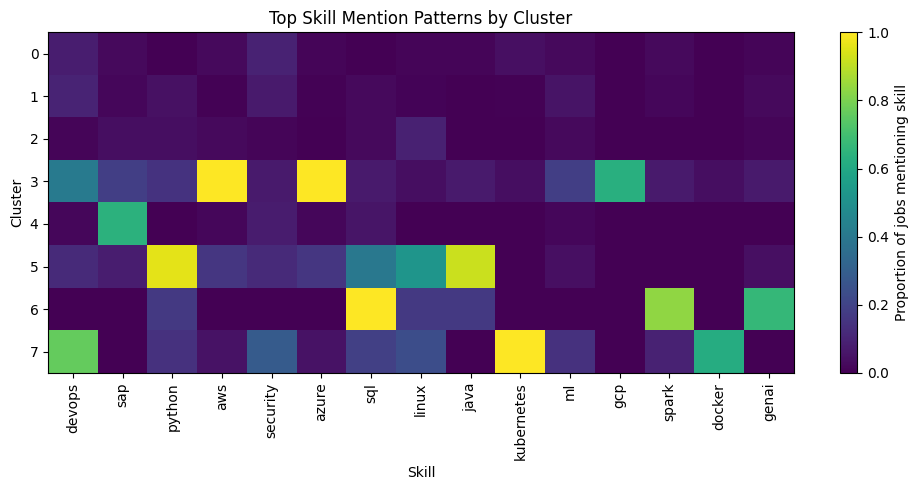

In [64]:
available_skill_cols = [
    col for col in df_unsup_results.columns
    if col.startswith("skill_")
]

if len(available_skill_cols) > 0:

    # Compute skill mention proportions by cluster
    skill_cluster_summary = (
        df_unsup_results
        .groupby("cluster")[available_skill_cols]
        .mean()
        .round(3)
    )

    # Add cluster sizes for interpretation
    cluster_sizes = (
        df_unsup_results["cluster"]
        .value_counts()
        .sort_index()
    )

    skill_cluster_summary_with_n = skill_cluster_summary.copy()
    skill_cluster_summary_with_n.insert(
        0,
        "n_jobs",
        cluster_sizes
    )

    print("Skill mention proportions by cluster:")
    display(skill_cluster_summary_with_n)

    # Select the most frequently mentioned skills overall for a cleaner heatmap
    top_skill_cols = (
        df_unsup_results[available_skill_cols]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .index
        .tolist()
    )

    skill_heatmap = skill_cluster_summary[top_skill_cols].copy()

    # Clean column labels for display
    clean_skill_labels = [
        col.replace("skill_", "")
        for col in skill_heatmap.columns
    ]

    plt.figure(figsize=(10, 5))
    plt.imshow(skill_heatmap, aspect="auto")
    plt.colorbar(label="Proportion of jobs mentioning skill")

    plt.xticks(
        ticks=np.arange(len(skill_heatmap.columns)),
        labels=clean_skill_labels,
        rotation=90
    )
    plt.yticks(
        ticks=np.arange(len(skill_heatmap.index)),
        labels=skill_heatmap.index
    )

    plt.xlabel("Skill")
    plt.ylabel("Cluster")
    plt.title("Top Skill Mention Patterns by Cluster")
    plt.tight_layout()
    plt.show()

else:
    print("No skill indicator columns found.")

## 7.6 Outlier Detection

Outlier detection matrix shape: (469, 38)
Outlier counts:


,count
is_outlier,
Normal,445
Outlier,24


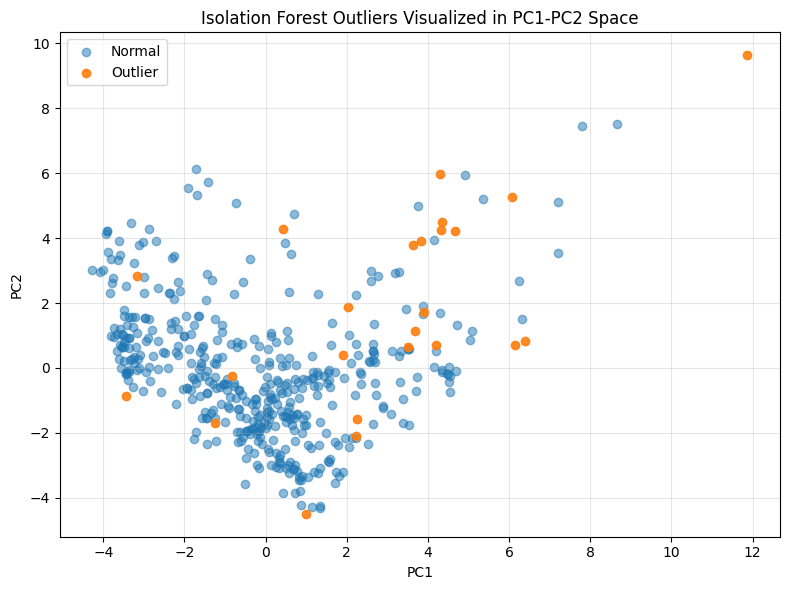

In [65]:
# Isolation Forest is used to detect unusual job postings based on the engineered feature space.
# Salary is not used as an input feature.
#
# To be consistent with K-Means clustering, we use the PCA-reduced feature matrix.
# X_cluster contains the first n_pc_90 principal components, retaining about 90% of variance.

from sklearn.ensemble import IsolationForest

print("Outlier detection matrix shape:", X_cluster.shape)

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Use PCA-reduced features for outlier detection
outlier_labels = iso_forest.fit_predict(X_cluster)

# IsolationForest returns:
# -1 = outlier
#  1 = normal observation
df_unsup_results["is_outlier"] = (outlier_labels == -1).astype(int)
df_unsup_results["outlier_score"] = iso_forest.decision_function(X_cluster)

print("Outlier counts:")
display(
    df_unsup_results["is_outlier"]
    .value_counts()
    .rename(index={0: "Normal", 1: "Outlier"})
    .to_frame("count")
)

# Visualize outliers using PC1 and PC2.
# Note: outlier detection was performed using the first n_pc_90 PCs,
# while this plot shows only the first two PCs for visualization.
plt.figure(figsize=(8, 6))

plt.scatter(
    df_unsup_results.loc[df_unsup_results["is_outlier"] == 0, "PC1"],
    df_unsup_results.loc[df_unsup_results["is_outlier"] == 0, "PC2"],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    df_unsup_results.loc[df_unsup_results["is_outlier"] == 1, "PC1"],
    df_unsup_results.loc[df_unsup_results["is_outlier"] == 1, "PC2"],
    alpha=0.9,
    label="Outlier"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Outliers Visualized in PC1-PC2 Space")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# Inspect the most unusual job postings

outlier_display_cols = [
    "job_title",
    "area_of_work",
    "position_type",
    "primary_region",
    "mid_salary",
    "log_mid_salary",
    "required_education",
    "preferred_education",
    "required_edu_level",
    "preferred_edu_level",
    "n_skills_mentioned",
    "exp_years_min",
    "exp_years_max",
    "is_intern",
    "is_entry",
    "is_senior",
    "is_lead",
    "is_manager",
    "is_architect",
    "role_data",
    "role_engineering",
    "role_consulting",
    "role_security",
    "cluster",
    "is_outlier",
    "outlier_score"
]

# Keep only columns that actually exist
outlier_display_cols = [
    col for col in outlier_display_cols
    if col in df_unsup_results.columns
]

outlier_table = (
    df_unsup_results[df_unsup_results["is_outlier"] == 1]
    [outlier_display_cols]
    .sort_values("outlier_score")
)

display(outlier_table.head(15))

,job_title,area_of_work,position_type,primary_region,mid_salary,log_mid_salary,required_education,preferred_education,required_edu_level,preferred_edu_level,n_skills_mentioned,exp_years_min,exp_years_max,is_intern,is_entry,is_senior,is_lead,is_manager,is_architect,role_data,role_engineering,role_consulting,role_security,cluster,is_outlier,outlier_score
331,"Associate Developer Intern 2026 – Microsoft, O...",Software Engineering,Internship,South,61880.0,11.032952,High School Diploma/GED,Bachelor's Degree,1,4,7,NaN,NaN,1,0,0,0,0,0,0,1,0,0,6,1,-0.157060
105,Associate Application Developer 2026,Software Engineering,Entry Level,South,92500.0,11.434964,High School Diploma/GED,Bachelor's Degree,1,4,4,NaN,NaN,0,0,0,0,0,0,0,1,0,0,6,1,-0.126437
107,Associate Security Specialist 2026 -Infrastruc...,Security,Entry Level,Midwest,64355.0,11.07217,Bachelor's Degree,Bachelor's Degree,4,4,4,NaN,NaN,0,0,0,0,0,0,0,0,0,1,5,1,-0.086521
411,Senior Program Manager,Consulting,Professional,South,196000.0,12.18587,Bachelor's Degree,Master's Degree,4,5,0,15.0,15.0,0,0,1,0,1,0,0,0,0,0,1,1,-0.081228
1,SAP Technology Architect,Software Engineering,Professional,Midwest,196000.0,12.18587,Bachelor's Degree,Unknown,4,0,6,NaN,NaN,0,0,0,0,0,1,0,0,0,0,0,1,-0.069008
130,Associate Business Transformation Consultant 2...,Consulting,Entry Level,South,99450.0,11.50741,High School Diploma/GED,Bachelor's Degree,1,4,1,1.0,1.0,0,0,0,0,0,0,1,0,1,0,1,1,-0.068715
456,Senior Data Security Consultant,Consulting,Professional,Midwest,211000.0,12.259613,Bachelor's Degree,Master's Degree,4,5,1,5.0,10.0,0,0,1,0,0,0,1,0,1,1,4,1,-0.051998
377,Associate Application Developer 2026– Hybrid C...,Software Engineering,Entry Level,Northeast,64355.0,11.07217,Bachelor's Degree,Master's Degree,4,5,4,NaN,NaN,0,0,0,0,0,0,1,1,0,0,6,1,-0.036400
122,U.S. Public Sector Compliance Officer,Enterprise Operations,Professional,South,250500.0,12.431214,Doctorate Degree,Doctorate Degree,6,6,0,NaN,NaN,0,0,0,0,0,0,0,0,0,1,2,1,-0.035266
18,Associate Package Specialist - Business Applic...,Infrastructure & Technology,Entry Level,South,64355.0,11.07217,Bachelor's Degree,Master's Degree,4,5,4,NaN,NaN,0,0,0,0,0,0,0,0,0,0,6,1,-0.028772


## 7.7 Save Unsupervised Results

In [67]:
required_result_cols = [
    "PC1",
    "PC2",
    "cluster",
    "is_outlier",
    "outlier_score"
]

missing_result_cols = [
    col for col in required_result_cols
    if col not in df_unsup_results.columns
]

if len(missing_result_cols) > 0:
    print("Warning: the following result columns are missing:")
    print(missing_result_cols)
else:
    print("All required unsupervised result columns are available.")

# Save full unsupervised result dataset
output_file = "ibm_jobs_with_unsupervised_results.csv"

df_unsup_results.to_csv(
    output_file,
    index=False
)

print("Saved file:", output_file)
print("Final unsupervised results shape:", df_unsup_results.shape)

# Save cluster summary if it exists
if "cluster_profile" in globals():
    cluster_profile.to_csv("cluster_profile_summary.csv", index=True)
    print("Saved file: cluster_profile_summary.csv")

# Save salary summary by cluster if it exists
if "salary_cluster_summary" in globals():
    salary_cluster_summary.to_csv("salary_summary_by_cluster.csv", index=True)
    print("Saved file: salary_summary_by_cluster.csv")

# Save categorical cluster profile if it exists
if "cluster_categorical_profile" in globals():
    cluster_categorical_profile.to_csv("cluster_categorical_profile.csv", index=True)
    print("Saved file: cluster_categorical_profile.csv")

# Save outlier table if it exists
if "outlier_table" in globals():
    outlier_table.to_csv("outlier_postings.csv", index=False)
    print("Saved file: outlier_postings.csv")

display(df_unsup_results.head())

All required unsupervised result columns are available.
Saved file: ibm_jobs_with_unsupervised_results.csv
Final unsupervised results shape: (469, 82)
Saved file: cluster_profile_summary.csv
Saved file: salary_summary_by_cluster.csv
Saved file: cluster_categorical_profile.csv
Saved file: outlier_postings.csv


,job_title,job_id,date_posted,state_province,area_of_work,min_salary,max_salary,position_type,required_education,preferred_education,preferred_technical_experience,date_posted_dt,min_salary_num,max_salary_num,mid_salary,salary_range,salary_range_pct,min_to_max_ratio,log_mid_salary,days_since_posted,posted_year,posted_month,posted_dow,posted_is_weekend,states_list,n_states_listed,is_multi_state_posting,primary_state,primary_region,required_edu_level,preferred_edu_level,edu_gap_preferred_minus_required,has_preferred_edu_specified,is_intern,is_entry,is_senior,is_lead,is_manager,is_director_plus,is_architect,role_engineering,role_data,role_security,role_product,role_design,role_sales,role_consulting,role_research,role_devops,title_len,title_word_count,text_all,exp_years_min,exp_years_max,exp_years_any,skill_python,skill_java,skill_sql,skill_r,skill_aws,skill_azure,skill_gcp,skill_kubernetes,skill_docker,skill_linux,skill_spark,skill_tableau,skill_powerbi,skill_ml,skill_genai,skill_security,skill_devops,skill_sap,n_skills_mentioned,exp_text_len,exp_text_word_count,skills_bin,PC1,PC2,cluster,is_outlier,outlier_score
0,Software Developer Intern 2026: SVL,75759,30-Jan-2026,California,Software Engineering,"90,720.00","166,320.00",Internship,High School Diploma/GED,Bachelor's Degree,"Exposure to cloud platforms (IBM Cloud, AWS, o...",2026-01-30,90720.0,166320.0,128520.0,75600.0,0.588235,0.545455,11.76384,5,2026,1,4,0,[California],1,0,California,West,1,4,3,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,35,5,software developer intern 2026: svl exposure t...,NaN,NaN,0.0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,3,374,51,3-4,3.509774,0.581406,3,0,0.076145
1,SAP Technology Architect,72352,26-Nov-2025,"Illinois, Texas, Indiana, New Jersey",Software Engineering,"144,000.00","248,000.00",Professional,Bachelor's Degree,Unknown,"SAP S/4HANA, SAP BTP (CAP, RAP, Event Mesh, In...",2025-11-26,144000.0,248000.0,196000.0,104000.0,0.530612,0.580645,12.18587,70,2025,11,2,0,"[Illinois, Texas, Indiana, New Jersey]",4,1,Illinois,Midwest,4,0,-4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,24,3,"sap technology architect sap\ns/4hana, sap btp...",NaN,NaN,0.0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,1,0,1,1,6,469,63,5-6,0.439902,4.271713,0,1,-0.069008
2,"Senior Software Engineer, (Boundary) - HashiCorp",82844,03-Feb-2026,"Texas, Massachusetts, California",Software Engineering,"131,000.00","226,000.00",Professional,High School Diploma/GED,Bachelor's Degree,What's nice to have (preferred qualifications)...,2026-02-03,131000.0,226000.0,178500.0,95000.0,0.532213,0.579646,12.092344,1,2026,2,1,0,"[Texas, Massachusetts, California]",3,1,Texas,South,1,4,3,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,48,6,"senior software engineer, (boundary) - hashico...",NaN,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,226,29,1-2,0.926802,-0.348722,1,0,0.125212
3,DevOps Engineer - AWS,80597,19-Dec-2025,Texas,Infrastructure & Technology,"99,875.00","129,250.00",Professional,Bachelor's Degree,Master's Degree,,2025-12-19,99875.0,129250.0,114562.5,29375.0,0.256410,0.772727,11.648876,47,2025,12,4,0,[Texas],1,0,Texas,South,4,5,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,21,4,devops engineer - aws,NaN,NaN,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1-2,0.710571,-1.548667,2,0,0.002773
4,Federal Senior Compliance Lead - CAS / FAR SME,86235,29-Jan-2026,"Minnesota, New York, Virginia, Maryland, Distr...",Enterprise Operations,"147,000.00","254,000.00",Professional,Bachelor's Degree,Master's Degree,Direct experience with the Defense Contract Au...,2026-01-29,147000.0,254000.0,200500.0,107000.0,0.533666,0.578740,12.20857,6,2026,1,3,0,"[Minnesota, New York, Virginia, Maryland, Dist...",5,1,Minnesota,Midwest,4,5,1,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,46,9,federal senior compliance lead - cas / far sme...,NaN,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,223,31,0,-1.611368,0.485443,1,0,0.032435


# 8. Supervised Learning

# Model development

**Goal: predict the log midpoint salary based on features as defined in section 6.8.**

## 8.1 Random Forest

In [68]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold

# Fresh copies so nothing above is affected
X_sup = X.copy()
y_sup = y.copy()

# Drop rows where the target is missing
valid_mask = y_sup.notna() & np.isfinite(y_sup)

X_sup = X_sup.loc[valid_mask].copy()
y_sup = y_sup.loc[valid_mask].copy()

# Check salary leakage before modeling
leakage_check = [
    "min_salary",
    "max_salary",
    "mid_salary",
    "log_mid_salary",
    "salary_range",
    "salary_range_pct",
    "min_to_max_ratio"
]

leakage_in_X = [col for col in leakage_check if col in X_sup.columns]

print("Salary leakage columns still in X_sup:")
print(leakage_in_X)

# Single shared train-test split used by all three models
X_train, X_test, y_train, y_test = train_test_split(
    X_sup,
    y_sup,
    test_size=0.25,
    random_state=42
)

print(f"Total usable rows : {len(y_sup)}")
print(f"Train             : {X_train.shape[0]} rows")
print(f"Test              : {X_test.shape[0]} rows")

# Shared CV splitter used by all three models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

Salary leakage columns still in X_sup:
[]
Total usable rows : 469
Train             : 351 rows
Test              : 118 rows


In [69]:
# Shared preprocessor defined once here, used by all three models
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

numeric_features_ridge = [col for col in numeric_features if col in X_sup.columns]
categorical_features_ridge = [col for col in categorical_features if col in X_sup.columns]
text_feature_ridge = text_feature if text_feature in X_sup.columns else None

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

transformers = [
    ("num", numeric_transformer, numeric_features_ridge),
    ("cat", categorical_transformer, categorical_features_ridge)
]

if text_feature_ridge is not None:
    text_transformer = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            max_features=100,
            ngram_range=(1, 2),
            min_df=2,
            stop_words="english"
        ))
    ])
    transformers.append(("txt", text_transformer, text_feature_ridge))

ridge_preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

print(f"Shared preprocessor defined.")
print(f"  Numeric features     : {len(numeric_features_ridge)}")
print(f"  Categorical features : {len(categorical_features_ridge)}")
print(f"  Text feature         : {text_feature_ridge}")

Shared preprocessor defined.
  Numeric features     : 52
  Categorical features : 7
  Text feature         : text_all


In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

pipe_rf = Pipeline(steps=[
    ("pre", ridge_preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_features=0.33,
        random_state=42,
        n_jobs=-1
    ))
])

cv_results = cross_validate(
    pipe_rf,
    X_train,
    y_train,
    cv=kf,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    return_train_score=True,
    n_jobs=-1
)

In [71]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "rf__n_estimators": [200, 500],
    "rf__max_features": [0.33, "sqrt", 0.2, 0.5],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_depth": [20, 40],
}

# Use RandomizedSearchCV to pick 20 combinations randomly
search = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters found:")
print(search.best_params_)

Best parameters found:
{'rf__n_estimators': 500, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.33, 'rf__max_depth': 40}


In [72]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Baseline CV results
baseline_rmse_cv = (-cv_results["test_neg_root_mean_squared_error"]).mean()
baseline_mae_cv = (-cv_results["test_neg_mean_absolute_error"]).mean()
baseline_r2_cv = cv_results["test_r2"].mean()

# Tuned model CV result
tuned_rmse_cv = -search.best_score_

# Tuned model on held-out test set
y_pred_log = search.best_estimator_.predict(X_test)

rf_rmse_log = root_mean_squared_error(y_test, y_pred_log)
rf_mae_log = mean_absolute_error(y_test, y_pred_log)
rf_r2_log = r2_score(y_test, y_pred_log)

# Convert predictions back to dollar scale
y_test_dollar = np.exp(y_test)
y_pred_dollar = np.exp(y_pred_log)

rf_rmse_dollar = root_mean_squared_error(y_test_dollar, y_pred_dollar)
rf_mae_dollar = mean_absolute_error(y_test_dollar, y_pred_dollar)

# Store results in a table
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Best Params": [search.best_params_],
    "Baseline CV RMSE_log": [baseline_rmse_cv],
    "Baseline CV MAE_log": [baseline_mae_cv],
    "Baseline CV R2_log": [baseline_r2_cv],
    "Tuned CV RMSE_log": [tuned_rmse_cv],
    "Test RMSE_log": [rf_rmse_log],
    "Test MAE_log": [rf_mae_log],
    "Test R2_log": [rf_r2_log],
    "Test RMSE_dollar": [rf_rmse_dollar],
    "Test MAE_dollar": [rf_mae_dollar]
})

display(rf_results)

print("Best Random Forest parameters:")
print(search.best_params_)
print()
print(f"Baseline CV RMSE (log): {baseline_rmse_cv:.4f}")
print(f"Baseline CV MAE  (log): {baseline_mae_cv:.4f}")
print(f"Baseline CV R2   (log): {baseline_r2_cv:.4f}")
print(f"Tuned CV RMSE    (log): {tuned_rmse_cv:.4f}")
print(f"Tuned Test RMSE  (log): {rf_rmse_log:.4f}")
print(f"Tuned Test MAE   (log): {rf_mae_log:.4f}")
print(f"Tuned Test R2    (log): {rf_r2_log:.4f}")
print(f"Tuned Test RMSE  (USD): ${rf_rmse_dollar:,.0f}")
print(f"Tuned Test MAE   (USD): ${rf_mae_dollar:,.0f}")

,Model,Best Params,Baseline CV RMSE_log,Baseline CV MAE_log,Baseline CV R2_log,Tuned CV RMSE_log,Test RMSE_log,Test MAE_log,Test R2_log,Test RMSE_dollar,Test MAE_dollar
0,Random Forest,"{'rf__n_estimators': 500, 'rf__min_samples_lea...",0.193398,0.146417,0.719617,0.192215,0.146589,0.109768,0.85681,21727.33668,15310.395424


Best Random Forest parameters:
{'rf__n_estimators': 500, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.33, 'rf__max_depth': 40}

Baseline CV RMSE (log): 0.1934
Baseline CV MAE  (log): 0.1464
Baseline CV R2   (log): 0.7196
Tuned CV RMSE    (log): 0.1922
Tuned Test RMSE  (log): 0.1466
Tuned Test MAE   (log): 0.1098
Tuned Test R2    (log): 0.8568
Tuned Test RMSE  (USD): $21,727
Tuned Test MAE   (USD): $15,310


,importance
cat__position_type_Professional,0.293945
cat__position_type_Internship,0.079419
cat__preferred_education_Associate's Degree/College Diploma,0.055138
txt__associate,0.036848
txt__2026,0.029445
cat__position_type_Entry Level,0.026367
txt__oracle,0.013060
txt__cloud,0.012825
txt__exposure,0.012753
txt__senior,0.012042


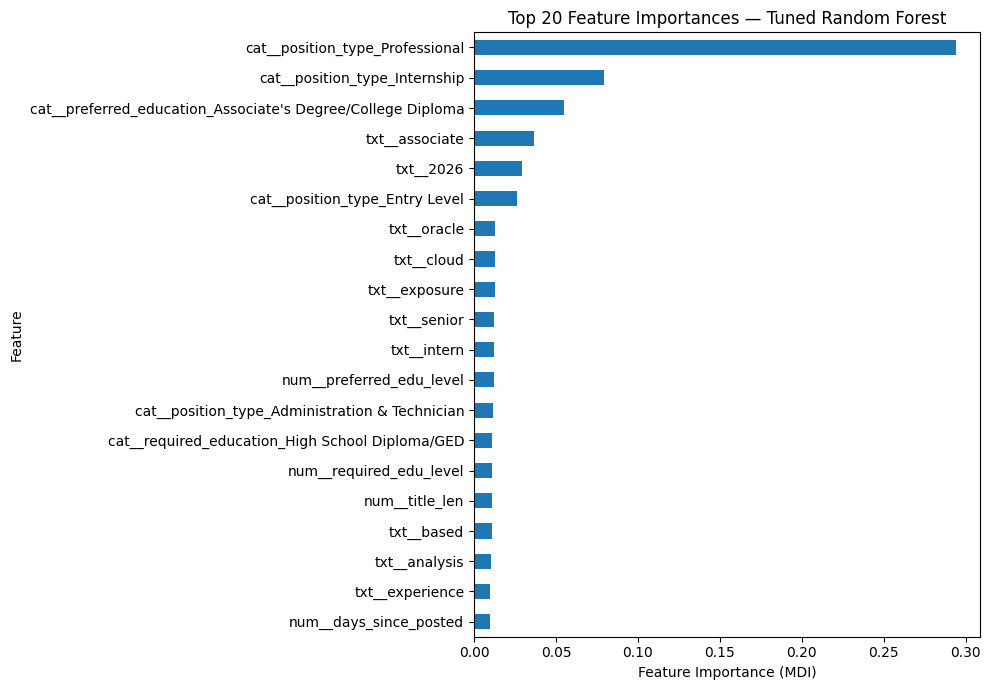

In [73]:
# Get feature names after preprocessing
rf_feature_names = search.best_estimator_.named_steps["pre"].get_feature_names_out()

# Get impurity-based feature importance from the tuned Random Forest
rf_importances = search.best_estimator_.named_steps["rf"].feature_importances_

# Create a ranked importance table
rf_feat_imp = (
    pd.Series(rf_importances, index=rf_feature_names)
    .sort_values(ascending=False)
    .head(20)
)

display(rf_feat_imp.to_frame(name="importance"))

# Plot top 20 features
plt.figure(figsize=(10, 7))
rf_feat_imp.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance (MDI)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances — Tuned Random Forest")
plt.tight_layout()
plt.show()

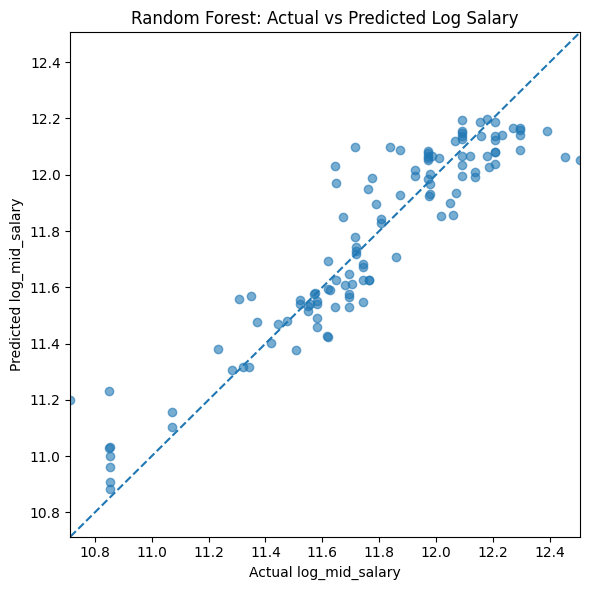

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_log,
    alpha=0.6
)

# make axes identical
min_val = min(y_test.min(), y_pred_log.min())
max_val = max(y_test.max(), y_pred_log.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("Actual log_mid_salary")
plt.ylabel("Predicted log_mid_salary")
plt.title("Random Forest: Actual vs Predicted Log Salary")

plt.tight_layout()
plt.show()

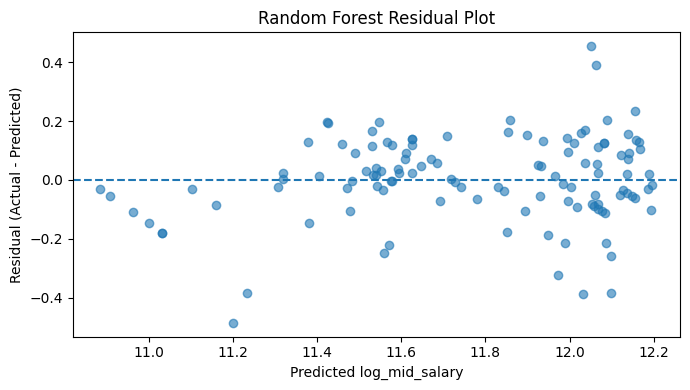

In [75]:
# residuals
gb_residuals = y_test - y_pred_log

plt.figure(figsize=(7, 4))

plt.scatter(
    y_pred_log,
    gb_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted log_mid_salary")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest Residual Plot")

plt.tight_layout()
plt.show()

## 8.2 Ridge Regression

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

## 8.2.1 Make sure feature lists only include columns in X

In [77]:
numeric_features_ridge = [col for col in numeric_features if col in X_sup.columns]
categorical_features_ridge = [col for col in categorical_features if col in X_sup.columns]

if text_feature in X_sup.columns:
    text_feature_ridge = text_feature
else:
    text_feature_ridge = None

print("Number of numeric features:", len(numeric_features_ridge))
print("Number of categorical features:", len(categorical_features_ridge))
print("Text feature:", text_feature_ridge)

Number of numeric features: 52
Number of categorical features: 7
Text feature: text_all


### 8.2.2 Train-test split

In [78]:
# Train-test split was performed once in the Section 8 setup cell (shared across all models)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (351, 65)
Test set shape: (118, 65)


### 8.2.3 Preprocessing for Ridge Regression

In [79]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

transformers = [
    ("num", numeric_transformer, numeric_features_ridge),
    ("cat", categorical_transformer, categorical_features_ridge)
]

if text_feature_ridge is not None:
    text_transformer = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            max_features=1000,
            ngram_range=(1, 2),
            min_df=2,
            stop_words="english"
        ))
    ])
    transformers.append(("txt", text_transformer, text_feature_ridge))

ridge_preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

### 8.2.4 Ridge Regression with cross-validation

In [80]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", ridge_preprocessor),
    ("model", Ridge())
])

# Baseline CV (default alpha=1.0)
ridge_cv_results = cross_validate(
    ridge_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    return_train_score=True,
    n_jobs=-1
)

ridge_baseline_rmse_cv = (-ridge_cv_results["test_neg_root_mean_squared_error"]).mean()
ridge_baseline_mae_cv = (-ridge_cv_results["test_neg_mean_absolute_error"]).mean()
ridge_baseline_r2_cv = ridge_cv_results["test_r2"].mean()

print(f"Baseline CV RMSE (log): {ridge_baseline_rmse_cv:.4f}")
print(f"Baseline CV MAE  (log): {ridge_baseline_mae_cv:.4f}")
print(f"Baseline CV R2   (log): {ridge_baseline_r2_cv:.4f}")

# Tune alpha via exhaustive GridSearchCV
param_grid = {
    "model__alpha": [0.01, 0.1, 0.3, 0.5, 0.8, 1, 1.5, 2, 3, 5, 10, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
ridge_tuned_rmse_cv = -ridge_grid.best_score_

print("Best Ridge alpha:", ridge_grid.best_params_["model__alpha"])
print(f"Tuned CV RMSE    (log): {ridge_tuned_rmse_cv:.4f}")

Baseline CV RMSE (log): 0.1916
Baseline CV MAE  (log): 0.1454
Baseline CV R2   (log): 0.7249
Best Ridge alpha: 0.1
Tuned CV RMSE    (log): 0.1865


### 8.2.5 Evaluate Ridge Regression

In [81]:
y_pred_log = best_ridge.predict(X_test)

ridge_rmse_log = root_mean_squared_error(y_test, y_pred_log)
ridge_mae_log = mean_absolute_error(y_test, y_pred_log)
ridge_r2_log = r2_score(y_test, y_pred_log)

# Convert back to dollar scale
y_test_dollar = np.exp(y_test)
y_pred_dollar = np.exp(y_pred_log)

ridge_rmse_dollar = root_mean_squared_error(y_test_dollar, y_pred_dollar)
ridge_mae_dollar = mean_absolute_error(y_test_dollar, y_pred_dollar)

ridge_results = pd.DataFrame({
    "Model": ["Ridge Regression"],
    "Best Alpha": [ridge_grid.best_params_["model__alpha"]],
    "Baseline CV RMSE_log": [ridge_baseline_rmse_cv],
    "Baseline CV MAE_log": [ridge_baseline_mae_cv],
    "Baseline CV R2_log": [ridge_baseline_r2_cv],
    "Tuned CV RMSE_log": [ridge_tuned_rmse_cv],
    "Test RMSE_log": [ridge_rmse_log],
    "Test MAE_log": [ridge_mae_log],
    "Test R2_log": [ridge_r2_log],
    "Test RMSE_dollar": [ridge_rmse_dollar],
    "Test MAE_dollar": [ridge_mae_dollar]
})

display(ridge_results)

print(f"Baseline CV RMSE (log): {ridge_baseline_rmse_cv:.4f}")
print(f"Baseline CV MAE  (log): {ridge_baseline_mae_cv:.4f}")
print(f"Baseline CV R2   (log): {ridge_baseline_r2_cv:.4f}")
print(f"Tuned CV RMSE    (log): {ridge_tuned_rmse_cv:.4f}")
print(f"Tuned Test RMSE  (log): {ridge_rmse_log:.4f}")
print(f"Tuned Test MAE   (log): {ridge_mae_log:.4f}")
print(f"Tuned Test R2    (log): {ridge_r2_log:.4f}")
print(f"Tuned Test RMSE  (USD): ${ridge_rmse_dollar:,.0f}")
print(f"Tuned Test MAE   (USD): ${ridge_mae_dollar:,.0f}")

,Model,Best Alpha,Baseline CV RMSE_log,Baseline CV MAE_log,Baseline CV R2_log,Tuned CV RMSE_log,Test RMSE_log,Test MAE_log,Test R2_log,Test RMSE_dollar,Test MAE_dollar
0,Ridge Regression,0.1,0.191563,0.145435,0.724858,0.186509,0.175269,0.128553,0.795299,25541.213537,17818.235837


Baseline CV RMSE (log): 0.1916
Baseline CV MAE  (log): 0.1454
Baseline CV R2   (log): 0.7249
Tuned CV RMSE    (log): 0.1865
Tuned Test RMSE  (log): 0.1753
Tuned Test MAE   (log): 0.1286
Tuned Test R2    (log): 0.7953
Tuned Test RMSE  (USD): $25,541
Tuned Test MAE   (USD): $17,818


### 8.2.6 Actual vs Predicted Plot

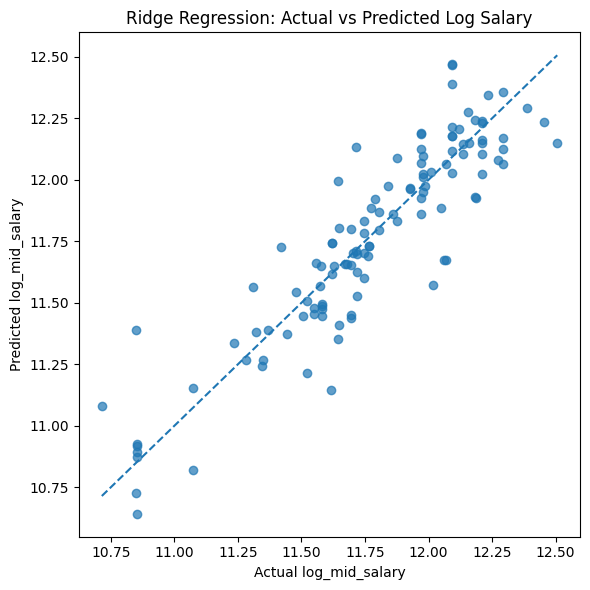

In [82]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_log, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual log_mid_salary")
plt.ylabel("Predicted log_mid_salary")
plt.title("Ridge Regression: Actual vs Predicted Log Salary")
plt.tight_layout()
plt.show()

### 8.2.7 Residual Plot

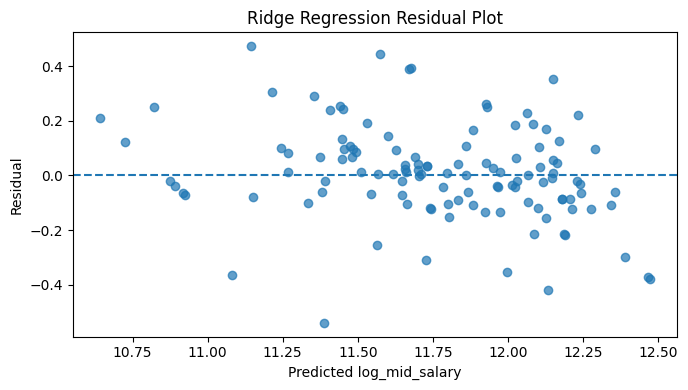

In [83]:
ridge_residuals = y_test - y_pred_log

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_log, ridge_residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted log_mid_salary")
plt.ylabel("Residual")
plt.title("Ridge Regression Residual Plot")
plt.tight_layout()
plt.show()

In [84]:
# Save model-level evaluation results
ridge_results.to_csv("ridge_regression_results.csv", index=False)

print("Saved file: ridge_regression_results.csv")
display(ridge_results)

Saved file: ridge_regression_results.csv


,Model,Best Alpha,Baseline CV RMSE_log,Baseline CV MAE_log,Baseline CV R2_log,Tuned CV RMSE_log,Test RMSE_log,Test MAE_log,Test R2_log,Test RMSE_dollar,Test MAE_dollar
0,Ridge Regression,0.1,0.191563,0.145435,0.724858,0.186509,0.175269,0.128553,0.795299,25541.213537,17818.235837


## 8.3 Gradient Boosting

In [85]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate, GridSearchCV

# Train-test split and kf are shared from the Section 8 setup cell
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_pipe = Pipeline(steps=[
    ("pre", ridge_preprocessor),
    ("gb", gb_model)
])

# Baseline via cross-validation (consistent with RF and Ridge)
gb_cv_results = cross_validate(
    gb_pipe,
    X_train,
    y_train,
    cv=kf,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    return_train_score=True,
    n_jobs=-1
)

gb_baseline_rmse_cv = (-gb_cv_results["test_neg_root_mean_squared_error"]).mean()
gb_baseline_mae_cv = (-gb_cv_results["test_neg_mean_absolute_error"]).mean()
gb_baseline_r2_cv = gb_cv_results["test_r2"].mean()

print(f"Baseline CV RMSE (log): {gb_baseline_rmse_cv:.4f}")
print(f"Baseline CV MAE  (log): {gb_baseline_mae_cv:.4f}")
print(f"Baseline CV R2   (log): {gb_baseline_r2_cv:.4f}")

Baseline CV RMSE (log): 0.1812
Baseline CV MAE  (log): 0.1392
Baseline CV R2   (log): 0.7545


In [86]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "gb__n_estimators": [100, 200, 300],
    "gb__learning_rate": [0.03, 0.05, 0.08],
    "gb__max_depth": [2, 3, 4],
    "gb__min_samples_leaf": [1, 3, 5],
    "gb__subsample": [0.8, 1.0]
}

# Use RandomizedSearchCV to pick 20 combinations randomly
grid_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

grid_search.fit(X_train, y_train)

gb_best_model = grid_search.best_estimator_
gb_tuned_rmse_cv = -grid_search.best_score_

print("Best parameters:")
print(grid_search.best_params_)

print(f"Tuned CV RMSE (log): {gb_tuned_rmse_cv:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'gb__subsample': 0.8, 'gb__n_estimators': 300, 'gb__min_samples_leaf': 1, 'gb__max_depth': 4, 'gb__learning_rate': 0.05}
Tuned CV RMSE (log): 0.1816


In [87]:
y_test_dollars = np.exp(y_test)
y_pred_log_tuned = gb_best_model.predict(X_test)
y_pred_dollars_tuned = np.exp(y_pred_log_tuned)

gb_rmse_log_tuned = root_mean_squared_error(y_test, y_pred_log_tuned)
gb_mae_log_tuned = mean_absolute_error(y_test, y_pred_log_tuned)
gb_r2_log_tuned = r2_score(y_test, y_pred_log_tuned)

gb_rmse_dollar_tuned = root_mean_squared_error(y_test_dollars, y_pred_dollars_tuned)
gb_mae_dollar_tuned = mean_absolute_error(y_test_dollars, y_pred_dollars_tuned)

gb_results = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "Best Params": [grid_search.best_params_],
    "Baseline CV RMSE_log": [gb_baseline_rmse_cv],
    "Baseline CV MAE_log": [gb_baseline_mae_cv],
    "Baseline CV R2_log": [gb_baseline_r2_cv],
    "Tuned CV RMSE_log": [gb_tuned_rmse_cv],
    "Test RMSE_log": [gb_rmse_log_tuned],
    "Test MAE_log": [gb_mae_log_tuned],
    "Test R2_log": [gb_r2_log_tuned],
    "Test RMSE_dollar": [gb_rmse_dollar_tuned],
    "Test MAE_dollar": [gb_mae_dollar_tuned]
})

display(gb_results)

print(f"Baseline CV RMSE (log): {gb_baseline_rmse_cv:.4f}")
print(f"Baseline CV MAE  (log): {gb_baseline_mae_cv:.4f}")
print(f"Baseline CV R2   (log): {gb_baseline_r2_cv:.4f}")
print(f"Tuned CV RMSE    (log): {gb_tuned_rmse_cv:.4f}")
print(f"Tuned Test RMSE  (log): {gb_rmse_log_tuned:.4f}")
print(f"Tuned Test MAE   (log): {gb_mae_log_tuned:.4f}")
print(f"Tuned Test R2    (log): {gb_r2_log_tuned:.4f}")
print(f"Tuned Test RMSE  (USD): ${gb_rmse_dollar_tuned:,.0f}")
print(f"Tuned Test MAE   (USD): ${gb_mae_dollar_tuned:,.0f}")

,Model,Best Params,Baseline CV RMSE_log,Baseline CV MAE_log,Baseline CV R2_log,Tuned CV RMSE_log,Test RMSE_log,Test MAE_log,Test R2_log,Test RMSE_dollar,Test MAE_dollar
0,Gradient Boosting,"{'gb__subsample': 0.8, 'gb__n_estimators': 300...",0.181214,0.139245,0.754548,0.181641,0.149614,0.107666,0.85084,22269.69114,14929.378317


Baseline CV RMSE (log): 0.1812
Baseline CV MAE  (log): 0.1392
Baseline CV R2   (log): 0.7545
Tuned CV RMSE    (log): 0.1816
Tuned Test RMSE  (log): 0.1496
Tuned Test MAE   (log): 0.1077
Tuned Test R2    (log): 0.8508
Tuned Test RMSE  (USD): $22,270
Tuned Test MAE   (USD): $14,929


Compare baseline CV metrics vs tuned CV metrics to assess the gain from hyperparameter search.

In [88]:
# feature importance
gb_feature_names = gb_best_model.named_steps["pre"].get_feature_names_out()

gb_importances = gb_best_model.named_steps["gb"].feature_importances_

gb_importance_df = pd.DataFrame({
    "feature": gb_feature_names,
    "importance": gb_importances
}).sort_values("importance", ascending=False)

gb_importance_df.head(20)

,feature,importance
229,cat__position_type_Professional,0.486671
237,cat__preferred_education_Associate's Degree/Co...,0.045914
1138,txt__team based,0.033114
332,txt__associate,0.021571
902,txt__oracle,0.019327
293,txt__analysis,0.013516
604,txt__experience,0.012484
1013,txt__representative,0.010973
7,num__preferred_edu_level,0.010896
1065,txt__senior,0.010666


,importance
feature,
cat__position_type_Professional,0.486671
cat__preferred_education_Associate's Degree/College Diploma,0.045914
txt__team based,0.033114
txt__associate,0.021571
txt__oracle,0.019327
txt__analysis,0.013516
txt__experience,0.012484
txt__representative,0.010973
num__preferred_edu_level,0.010896


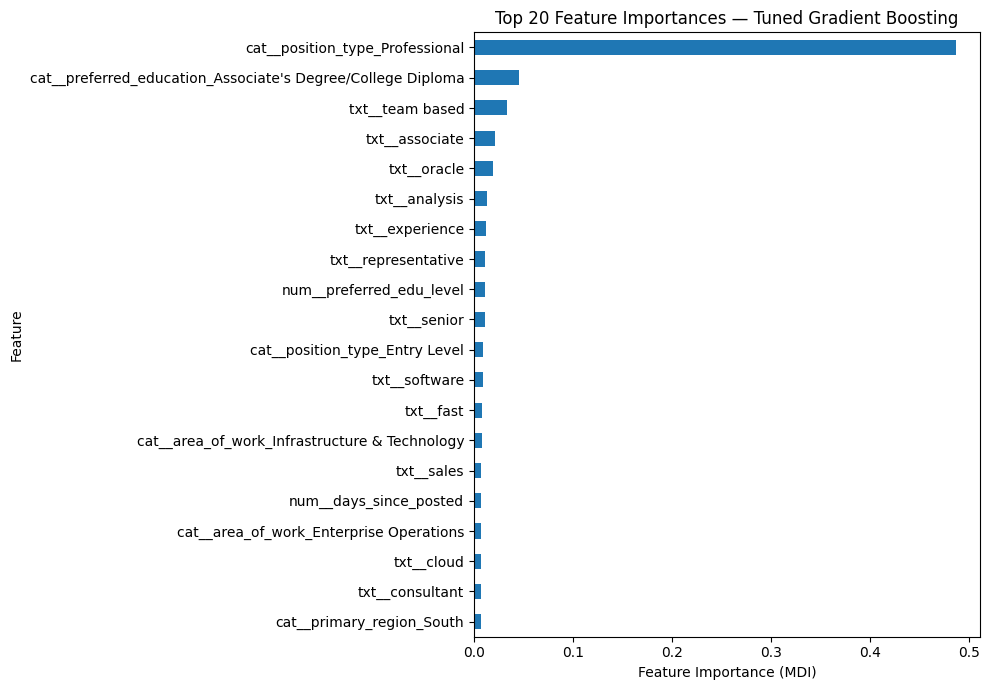

In [92]:
gb_feat_imp = gb_importance_df.head(20).set_index("feature")["importance"]

display(gb_feat_imp.to_frame(name="importance"))

plt.figure(figsize=(10, 7))
gb_feat_imp.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance (MDI)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances — Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

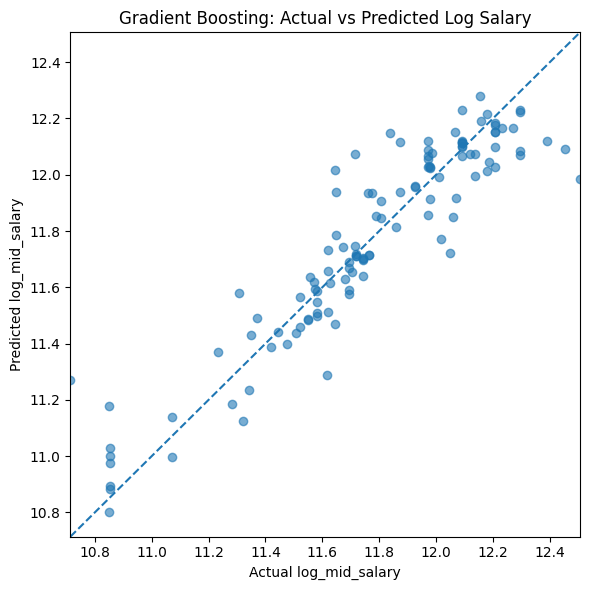

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_log_tuned,
    alpha=0.6
)

# make axes identical
min_val = min(y_test.min(), y_pred_log_tuned.min())
max_val = max(y_test.max(), y_pred_log_tuned.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("Actual log_mid_salary")
plt.ylabel("Predicted log_mid_salary")
plt.title("Gradient Boosting: Actual vs Predicted Log Salary")

plt.tight_layout()
plt.show()

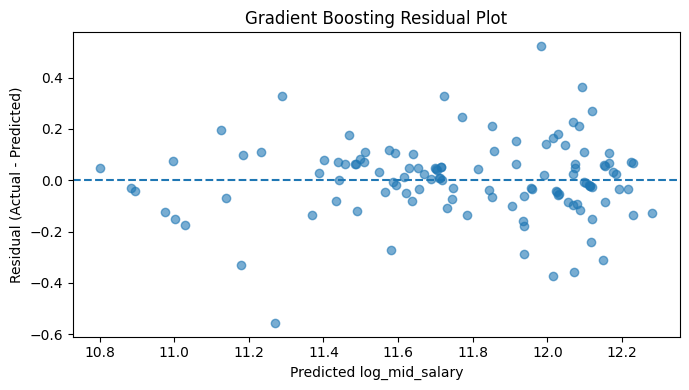

In [90]:
# residuals
gb_residuals = y_test - y_pred_log_tuned

plt.figure(figsize=(7, 4))

plt.scatter(
    y_pred_log_tuned,
    gb_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted log_mid_salary")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Gradient Boosting Residual Plot")

plt.tight_layout()
plt.show()